# TX Housing Market Analysis
## Notebook 02: Home Value Exploratory Analysis

### Objective

This notebook evaluates historical home-value growth and recent price momentum across eight North Dallas-area housing markets using the Zillow Home Value Index (ZHVI).

The analysis addresses four initial questions:

1. How have typical home values changed since 2018?
2. Which markets have experienced the greatest cumulative appreciation?
3. Which markets have produced the strongest long-term annualized growth?
4. Which markets are currently experiencing accelerating or slowing home-value growth?

### Target Markets

- Anna, TX
- Celina, TX
- Frisco, TX
- McKinney, TX
- Melissa, TX
- Plano, TX
- Princeton, TX
- Prosper, TX

### Study Period

January 2018 through July 2026.

### Important Interpretation

ZHVI measures typical home values rather than transaction prices. Therefore, the results in this notebook measure **home-value trends**, not the number of properties purchased or current transaction-market strength.

Transaction activity, housing supply, demand, demographic growth, and residential construction will be incorporated separately before determining whether each overall market is growing or slowing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [4]:
# -------------------------------------------------------------------
# PROJECT PATHS
# -------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

ZHVI_FILE = PROCESSED_DATA_DIR / "tx_zhvi_monthly.csv"

print("Project root:", PROJECT_ROOT)
print("ZHVI file:", ZHVI_FILE)

Project root: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis
ZHVI file: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/tx_zhvi_monthly.csv


## 1. Load Processed Zillow Data

This notebook uses the cleaned monthly ZHVI dataset produced in Notebook 01.

In [5]:
# -------------------------------------------------------------------
# LOAD PROCESSED ZHVI DATA
# -------------------------------------------------------------------

df = pd.read_csv(
    ZHVI_FILE,
    parse_dates=["Date"]
)

print("Dataset shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Cities:", sorted(df["City"].unique()))

df.head()

Dataset shape: (824, 6)
Date range: 2018-01-31 to 2026-07-31
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper']


,City,Date,ZHVI,Year,Month,YearMonth
0,Anna,2018-01-31,"261,595.26",2018,1,2018-01
1,Anna,2018-02-28,"262,998.65",2018,2,2018-02
2,Anna,2018-03-31,"264,233.70",2018,3,2018-03
3,Anna,2018-04-30,"265,124.49",2018,4,2018-04
4,Anna,2018-05-31,"265,856.00",2018,5,2018-05


In [6]:
# -------------------------------------------------------------------
# QUICK VALIDATION
# -------------------------------------------------------------------

print("Number of cities:", df["City"].nunique())
print("Total observations:", len(df))
print("Missing ZHVI values:", df["ZHVI"].isna().sum())
print(
    "Duplicate city-month rows:",
    df.duplicated(subset=["City", "Date"]).sum()
)

Number of cities: 8
Total observations: 824
Missing ZHVI values: 0
Duplicate city-month rows: 0


## 2. Historical Home Values

The first visualization compares the level of typical home values across the eight markets from 2018 through July 2026.

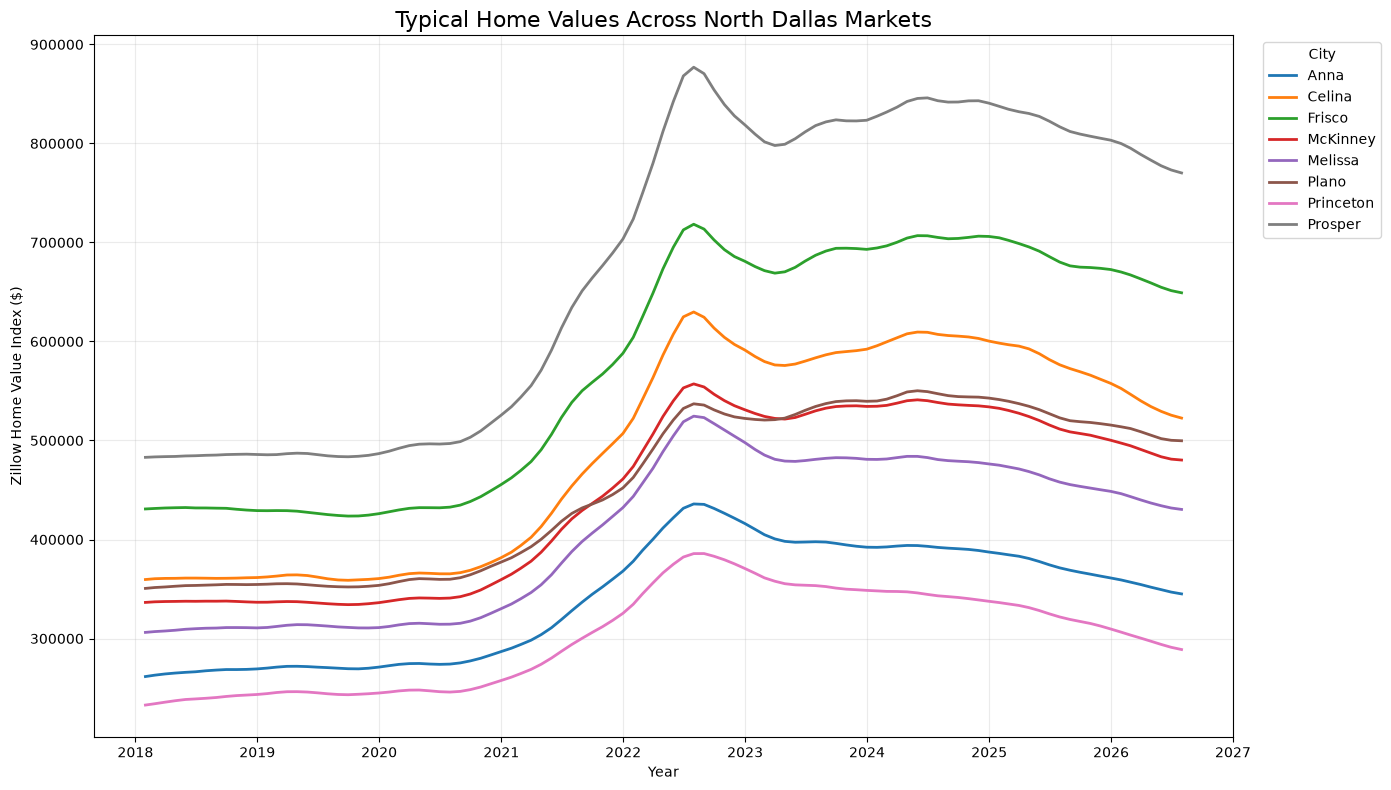

In [7]:
# -------------------------------------------------------------------
# HISTORICAL ZHVI BY CITY
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))

for city in sorted(df["City"].unique()):
    city_data = df[df["City"] == city]

    ax.plot(
        city_data["Date"],
        city_data["ZHVI"],
        label=city,
        linewidth=2
    )

ax.set_title(
    "Typical Home Values Across North Dallas Markets",
    fontsize=16
)

ax.set_xlabel("Year")
ax.set_ylabel("Zillow Home Value Index ($)")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 3. Indexed Home-Value Growth

Because the target markets began the study period at substantially different home-value levels, raw dollar values do not provide a fair comparison of proportional appreciation.

Each city's January 2018 ZHVI is therefore normalized to 100.

An index value of:

- 100 = no change from January 2018
- 125 = 25% appreciation
- 150 = 50% appreciation
- 200 = 100% appreciation

In [8]:
# -------------------------------------------------------------------
# CREATE 2018 = 100 INDEX
# -------------------------------------------------------------------

df = df.sort_values(["City", "Date"]).copy()

df["Starting_ZHVI"] = (
    df.groupby("City")["ZHVI"]
    .transform("first")
)

df["ZHVI_Index_2018"] = (
    df["ZHVI"] / df["Starting_ZHVI"]
) * 100

df.head()

,City,Date,ZHVI,Year,Month,YearMonth,Starting_ZHVI,ZHVI_Index_2018
0,Anna,2018-01-31,"261,595.26",2018,1,2018-01,"261,595.26",100.00
1,Anna,2018-02-28,"262,998.65",2018,2,2018-02,"261,595.26",100.54
2,Anna,2018-03-31,"264,233.70",2018,3,2018-03,"261,595.26",101.01
3,Anna,2018-04-30,"265,124.49",2018,4,2018-04,"261,595.26",101.35
4,Anna,2018-05-31,"265,856.00",2018,5,2018-05,"261,595.26",101.63


In [9]:
# sanity check
df.groupby("City").first()[
    ["ZHVI", "Starting_ZHVI", "ZHVI_Index_2018"]
]

,ZHVI,Starting_ZHVI,ZHVI_Index_2018
City,,,
Anna,"261,595.26","261,595.26",100.00
Celina,"359,592.10","359,592.10",100.00
Frisco,"430,859.52","430,859.52",100.00
McKinney,"336,476.43","336,476.43",100.00
Melissa,"306,192.92","306,192.92",100.00
Plano,"350,625.89","350,625.89",100.00
Princeton,"232,811.74","232,811.74",100.00
Prosper,"482,988.47","482,988.47",100.00


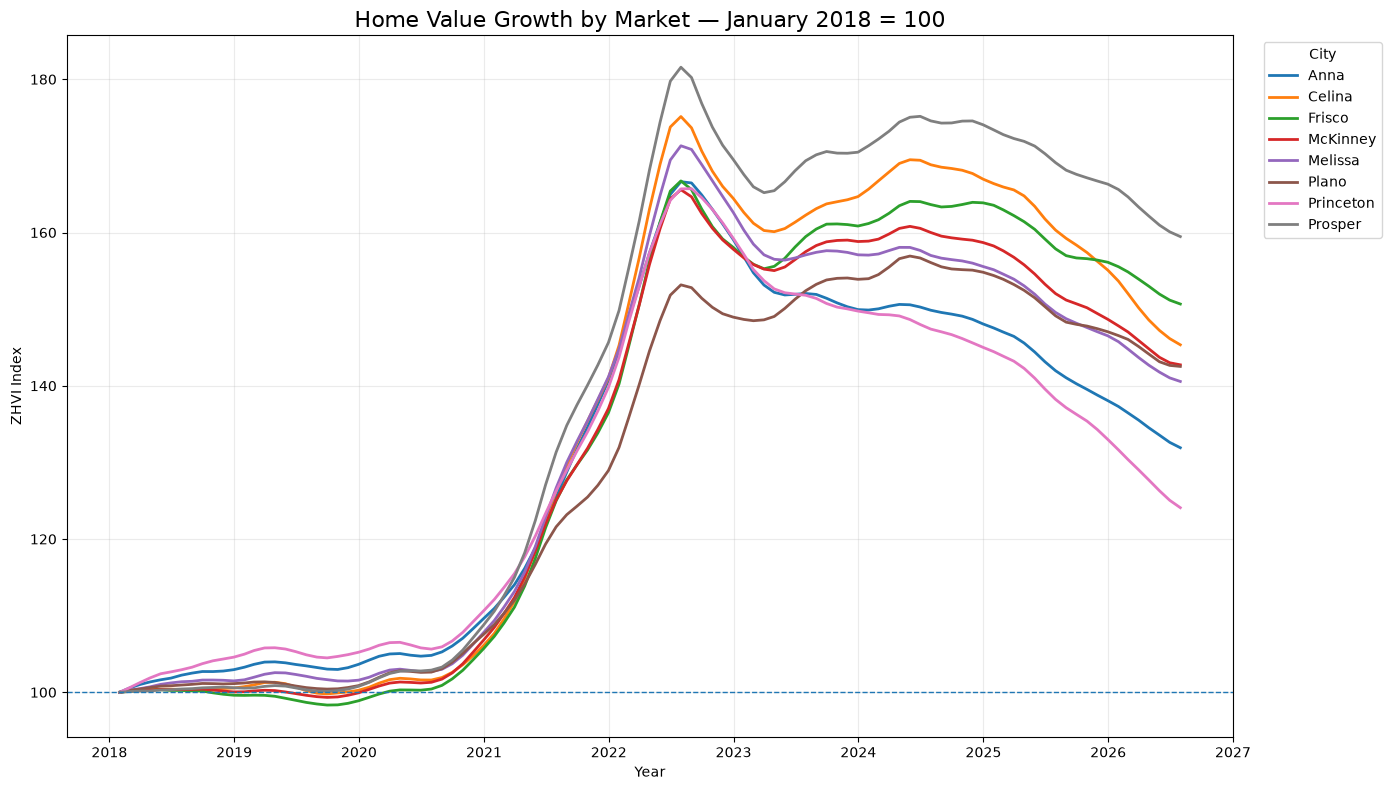

In [10]:
# -------------------------------------------------------------------
# INDEXED HOME VALUE GROWTH
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))

for city in sorted(df["City"].unique()):
    city_data = df[df["City"] == city]

    ax.plot(
        city_data["Date"],
        city_data["ZHVI_Index_2018"],
        label=city,
        linewidth=2
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Home Value Growth by Market — January 2018 = 100",
    fontsize=16
)

ax.set_xlabel("Year")
ax.set_ylabel("ZHVI Index")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4. Cumulative Home-Value Appreciation

The next step measures the total percentage change in ZHVI from the beginning of the study period to the latest available observation.

In [11]:
# -------------------------------------------------------------------
# STARTING AND LATEST ZHVI
# -------------------------------------------------------------------

starting_values = (
    df.sort_values("Date")
    .groupby("City", as_index=False)
    .first()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Start_Date",
            "ZHVI": "Start_ZHVI"
        }
    )
)

latest_values = (
    df.sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Latest_Date",
            "ZHVI": "Latest_ZHVI"
        }
    )
)

appreciation_summary = starting_values.merge(
    latest_values,
    on="City"
)

appreciation_summary

,City,Start_Date,Start_ZHVI,Latest_Date,Latest_ZHVI
0,Anna,2018-01-31,"261,595.26",2026-07-31,"345,077.93"
1,Celina,2018-01-31,"359,592.10",2026-07-31,"522,656.82"
2,Frisco,2018-01-31,"430,859.52",2026-07-31,"649,172.68"
3,McKinney,2018-01-31,"336,476.43",2026-07-31,"480,264.85"
4,Melissa,2018-01-31,"306,192.92",2026-07-31,"430,393.87"
5,Plano,2018-01-31,"350,625.89",2026-07-31,"499,723.21"
6,Princeton,2018-01-31,"232,811.74",2026-07-31,"288,891.23"
7,Prosper,2018-01-31,"482,988.47",2026-07-31,"770,217.03"


In [12]:
# -------------------------------------------------------------------
# TOTAL APPRECIATION
# -------------------------------------------------------------------

appreciation_summary["Total_Appreciation_Pct"] = (
    (
        appreciation_summary["Latest_ZHVI"]
        / appreciation_summary["Start_ZHVI"]
    ) - 1
) * 100

appreciation_summary = appreciation_summary.sort_values(
    "Total_Appreciation_Pct",
    ascending=False
)

appreciation_summary[
    [
        "City",
        "Start_ZHVI",
        "Latest_ZHVI",
        "Total_Appreciation_Pct"
    ]
]

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct
7,Prosper,"482,988.47","770,217.03",59.47
2,Frisco,"430,859.52","649,172.68",50.67
1,Celina,"359,592.10","522,656.82",45.35
3,McKinney,"336,476.43","480,264.85",42.73
5,Plano,"350,625.89","499,723.21",42.52
4,Melissa,"306,192.92","430,393.87",40.56
0,Anna,"261,595.26","345,077.93",31.91
6,Princeton,"232,811.74","288,891.23",24.09


In [13]:
appreciation_display = appreciation_summary[
    [
        "City",
        "Start_ZHVI",
        "Latest_ZHVI",
        "Total_Appreciation_Pct"
    ]
].copy()

appreciation_display["Start_ZHVI"] = (
    appreciation_display["Start_ZHVI"]
    .map(lambda x: f"${x:,.0f}")
)

appreciation_display["Latest_ZHVI"] = (
    appreciation_display["Latest_ZHVI"]
    .map(lambda x: f"${x:,.0f}")
)

appreciation_display["Total_Appreciation_Pct"] = (
    appreciation_display["Total_Appreciation_Pct"]
    .map(lambda x: f"{x:.1f}%")
)

appreciation_display

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct
7,Prosper,"$482,988","$770,217",59.5%
2,Frisco,"$430,860","$649,173",50.7%
1,Celina,"$359,592","$522,657",45.3%
3,McKinney,"$336,476","$480,265",42.7%
5,Plano,"$350,626","$499,723",42.5%
4,Melissa,"$306,193","$430,394",40.6%
0,Anna,"$261,595","$345,078",31.9%
6,Princeton,"$232,812","$288,891",24.1%


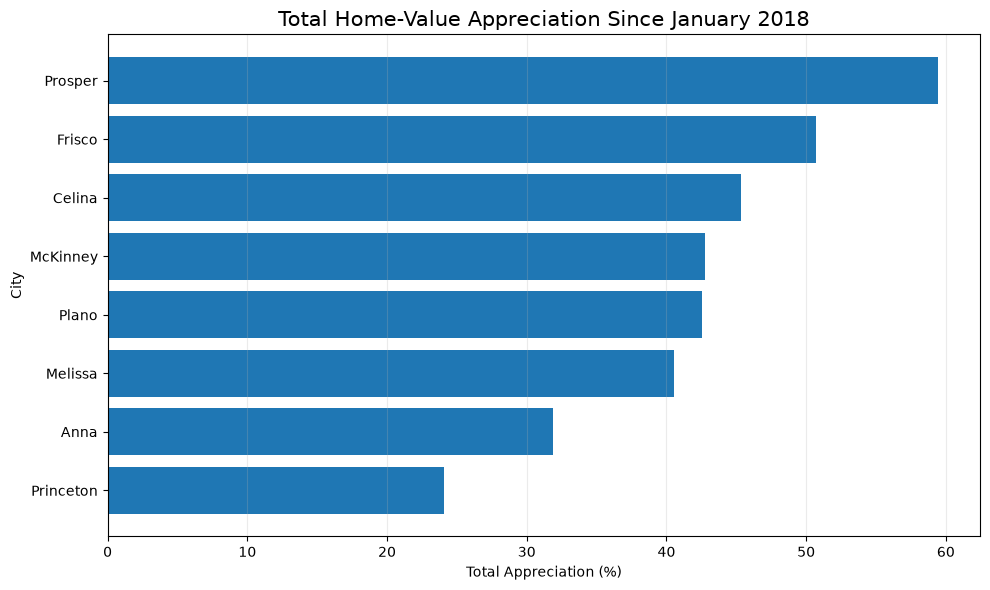

In [14]:
# -------------------------------------------------------------------
# TOTAL APPRECIATION BAR CHART
# -------------------------------------------------------------------

plot_data = appreciation_summary.sort_values(
    "Total_Appreciation_Pct"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["City"],
    plot_data["Total_Appreciation_Pct"]
)

ax.set_title(
    "Total Home-Value Appreciation Since January 2018",
    fontsize=15
)

ax.set_xlabel("Total Appreciation (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [15]:
# -------------------------------------------------------------------
# FULL-PERIOD CAGR
# -------------------------------------------------------------------

appreciation_summary["Years"] = (
    (
        appreciation_summary["Latest_Date"]
        - appreciation_summary["Start_Date"]
    ).dt.days
    / 365.25
)

appreciation_summary["Full_Period_CAGR_Pct"] = (
    (
        appreciation_summary["Latest_ZHVI"]
        / appreciation_summary["Start_ZHVI"]
    )
    ** (1 / appreciation_summary["Years"])
    - 1
) * 100

appreciation_summary[
    [
        "City",
        "Years",
        "Total_Appreciation_Pct",
        "Full_Period_CAGR_Pct"
    ]
].sort_values(
    "Full_Period_CAGR_Pct",
    ascending=False
)

,City,Years,Total_Appreciation_Pct,Full_Period_CAGR_Pct
7,Prosper,8.50,59.47,5.65
2,Frisco,8.50,50.67,4.94
1,Celina,8.50,45.35,4.50
3,McKinney,8.50,42.73,4.28
5,Plano,8.50,42.52,4.26
4,Melissa,8.50,40.56,4.09
0,Anna,8.50,31.91,3.31
6,Princeton,8.50,24.09,2.57


In [16]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR HOME VALUE GROWTH
# -------------------------------------------------------------------

df["ZHVI_YoY_Pct"] = (
    df.groupby("City")["ZHVI"]
    .pct_change(periods=12)
    * 100
)

df[
    [
        "City",
        "Date",
        "ZHVI",
        "ZHVI_YoY_Pct"
    ]
].tail(20)

,City,Date,ZHVI,ZHVI_YoY_Pct
804,Prosper,2024-12-31,"840,696.71",2.10
805,Prosper,2025-01-31,"837,468.71",1.21
806,Prosper,2025-02-28,"834,501.43",0.34
807,Prosper,2025-03-31,"832,034.74",-0.55
808,Prosper,2025-04-30,"830,247.66",-1.44
809,Prosper,2025-05-31,"827,283.76",-2.15
810,Prosper,2025-06-30,"822,462.64",-2.78
811,Prosper,2025-07-31,"816,826.21",-3.12
812,Prosper,2025-08-31,"812,076.12",-3.53
813,Prosper,2025-09-30,"809,457.12",-3.85


## 5. Recent Price Momentum

Year-over-year ZHVI growth measures whether typical home values are rising or falling relative to the same month one year earlier.

This helps distinguish markets that experienced strong historical appreciation from markets that are still appreciating today.

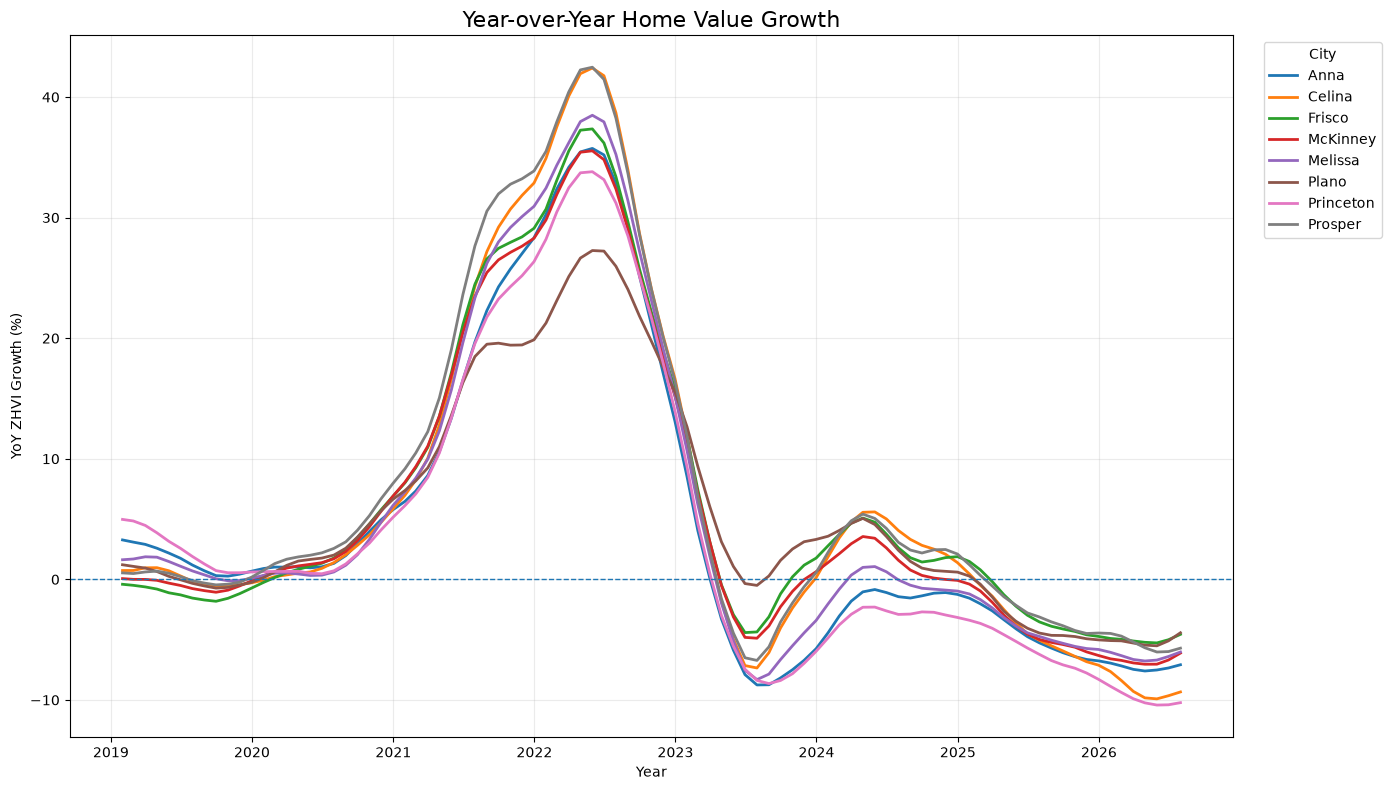

In [17]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR ZHVI GROWTH
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))

for city in sorted(df["City"].unique()):
    city_data = df[df["City"] == city]

    ax.plot(
        city_data["Date"],
        city_data["ZHVI_YoY_Pct"],
        label=city,
        linewidth=2
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Year-over-Year Home Value Growth",
    fontsize=16
)

ax.set_xlabel("Year")
ax.set_ylabel("YoY ZHVI Growth (%)")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [18]:
# -------------------------------------------------------------------
# LATEST YOY GROWTH BY CITY
# -------------------------------------------------------------------

latest_yoy = (
    df.dropna(subset=["ZHVI_YoY_Pct"])
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI", "ZHVI_YoY_Pct"]]
    .sort_values(
        "ZHVI_YoY_Pct",
        ascending=False
    )
)

latest_yoy

,City,Date,ZHVI,ZHVI_YoY_Pct
5,Plano,2026-07-31,"499,723.21",-4.43
2,Frisco,2026-07-31,"649,172.68",-4.56
7,Prosper,2026-07-31,"770,217.03",-5.71
4,Melissa,2026-07-31,"430,393.87",-6.02
3,McKinney,2026-07-31,"480,264.85",-6.11
0,Anna,2026-07-31,"345,077.93",-7.08
1,Celina,2026-07-31,"522,656.82",-9.34
6,Princeton,2026-07-31,"288,891.23",-10.23


In [19]:
# -------------------------------------------------------------------
# 3-YEAR CAGR
# -------------------------------------------------------------------

latest_date = df["Date"].max()
three_year_target = latest_date - pd.DateOffset(years=3)

three_year_start = (
    df[df["Date"] <= three_year_target]
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Three_Year_Start_Date",
            "ZHVI": "Three_Year_Start_ZHVI"
        }
    )
)

three_year_latest = (
    df.sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Latest_Date",
            "ZHVI": "Latest_ZHVI"
        }
    )
)

three_year_growth = three_year_start.merge(
    three_year_latest,
    on="City"
)

three_year_growth["Years"] = (
    (
        three_year_growth["Latest_Date"]
        - three_year_growth["Three_Year_Start_Date"]
    ).dt.days
    / 365.25
)

three_year_growth["Three_Year_CAGR_Pct"] = (
    (
        three_year_growth["Latest_ZHVI"]
        / three_year_growth["Three_Year_Start_ZHVI"]
    )
    ** (1 / three_year_growth["Years"])
    - 1
) * 100

three_year_growth[
    [
        "City",
        "Three_Year_CAGR_Pct"
    ]
].sort_values(
    "Three_Year_CAGR_Pct",
    ascending=False
)

,City,Three_Year_CAGR_Pct
2,Frisco,-1.87
7,Prosper,-1.99
5,Plano,-2.21
3,McKinney,-3.23
1,Celina,-3.60
4,Melissa,-3.63
0,Anna,-4.62
6,Princeton,-6.50


In [20]:
# -------------------------------------------------------------------
# 5-YEAR CAGR
# -------------------------------------------------------------------

five_year_target = latest_date - pd.DateOffset(years=5)

five_year_start = (
    df[df["Date"] <= five_year_target]
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Five_Year_Start_Date",
            "ZHVI": "Five_Year_Start_ZHVI"
        }
    )
)

five_year_growth = five_year_start.merge(
    three_year_latest,
    on="City"
)

five_year_growth["Years"] = (
    (
        five_year_growth["Latest_Date"]
        - five_year_growth["Five_Year_Start_Date"]
    ).dt.days
    / 365.25
)

five_year_growth["Five_Year_CAGR_Pct"] = (
    (
        five_year_growth["Latest_ZHVI"]
        / five_year_growth["Five_Year_Start_ZHVI"]
    )
    ** (1 / five_year_growth["Years"])
    - 1
) * 100

five_year_growth[
    [
        "City",
        "Five_Year_CAGR_Pct"
    ]
].sort_values(
    "Five_Year_CAGR_Pct",
    ascending=False
)

,City,Five_Year_CAGR_Pct
7,Prosper,3.96
2,Frisco,3.81
5,Plano,3.23
1,Celina,2.85
3,McKinney,2.67
4,Melissa,2.10
0,Anna,1.01
6,Princeton,-0.35


In [21]:
# -------------------------------------------------------------------
# CONSOLIDATED PRICE PERFORMANCE SUMMARY
# -------------------------------------------------------------------

price_summary = (
    appreciation_summary[
        [
            "City",
            "Start_ZHVI",
            "Latest_ZHVI",
            "Total_Appreciation_Pct",
            "Full_Period_CAGR_Pct"
        ]
    ]
    .merge(
        three_year_growth[
            [
                "City",
                "Three_Year_CAGR_Pct"
            ]
        ],
        on="City"
    )
    .merge(
        five_year_growth[
            [
                "City",
                "Five_Year_CAGR_Pct"
            ]
        ],
        on="City"
    )
    .merge(
        latest_yoy[
            [
                "City",
                "ZHVI_YoY_Pct"
            ]
        ],
        on="City"
    )
)

price_summary = price_summary.rename(
    columns={
        "ZHVI_YoY_Pct": "Latest_YoY_Pct"
    }
)

price_summary = price_summary.sort_values(
    "Total_Appreciation_Pct",
    ascending=False
)

price_summary

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct,Full_Period_CAGR_Pct,Three_Year_CAGR_Pct,Five_Year_CAGR_Pct,Latest_YoY_Pct
0,Prosper,"482,988.47","770,217.03",59.47,5.65,-1.99,3.96,-5.71
1,Frisco,"430,859.52","649,172.68",50.67,4.94,-1.87,3.81,-4.56
2,Celina,"359,592.10","522,656.82",45.35,4.50,-3.60,2.85,-9.34
3,McKinney,"336,476.43","480,264.85",42.73,4.28,-3.23,2.67,-6.11
4,Plano,"350,625.89","499,723.21",42.52,4.26,-2.21,3.23,-4.43
5,Melissa,"306,192.92","430,393.87",40.56,4.09,-3.63,2.10,-6.02
6,Anna,"261,595.26","345,077.93",31.91,3.31,-4.62,1.01,-7.08
7,Princeton,"232,811.74","288,891.23",24.09,2.57,-6.50,-0.35,-10.23


In [22]:
# -------------------------------------------------------------------
# PRICE MOMENTUM CHANGE
# -------------------------------------------------------------------

price_summary["Momentum_vs_3yr"] = (
    price_summary["Latest_YoY_Pct"]
    - price_summary["Three_Year_CAGR_Pct"]
)

price_summary[
    [
        "City",
        "Latest_YoY_Pct",
        "Three_Year_CAGR_Pct",
        "Momentum_vs_3yr"
    ]
].sort_values(
    "Momentum_vs_3yr",
    ascending=False
)

,City,Latest_YoY_Pct,Three_Year_CAGR_Pct,Momentum_vs_3yr
4,Plano,-4.43,-2.21,-2.22
5,Melissa,-6.02,-3.63,-2.39
6,Anna,-7.08,-4.62,-2.46
1,Frisco,-4.56,-1.87,-2.69
3,McKinney,-6.11,-3.23,-2.89
0,Prosper,-5.71,-1.99,-3.72
7,Princeton,-10.23,-6.50,-3.73
2,Celina,-9.34,-3.60,-5.73


In [23]:
# -------------------------------------------------------------------
# PRICE MOMENTUM CLASSIFICATION
# -------------------------------------------------------------------

def classify_price_momentum(row):
    yoy = row["Latest_YoY_Pct"]
    momentum = row["Momentum_vs_3yr"]

    if yoy > 3 and momentum > 0:
        return "Strong / Accelerating"

    elif yoy > 0 and momentum > 0:
        return "Positive / Accelerating"

    elif yoy > 0 and momentum <= 0:
        return "Positive / Slowing"

    elif yoy <= 0 and momentum > 0:
        return "Declining / Improving"

    else:
        return "Declining / Weakening"


price_summary["Price_Momentum"] = price_summary.apply(
    classify_price_momentum,
    axis=1
)

price_summary[
    [
        "City",
        "Latest_YoY_Pct",
        "Three_Year_CAGR_Pct",
        "Momentum_vs_3yr",
        "Price_Momentum"
    ]
].sort_values(
    "Latest_YoY_Pct",
    ascending=False
)

,City,Latest_YoY_Pct,Three_Year_CAGR_Pct,Momentum_vs_3yr,Price_Momentum
4,Plano,-4.43,-2.21,-2.22,Declining / Weakening
1,Frisco,-4.56,-1.87,-2.69,Declining / Weakening
0,Prosper,-5.71,-1.99,-3.72,Declining / Weakening
5,Melissa,-6.02,-3.63,-2.39,Declining / Weakening
3,McKinney,-6.11,-3.23,-2.89,Declining / Weakening
6,Anna,-7.08,-4.62,-2.46,Declining / Weakening
2,Celina,-9.34,-3.60,-5.73,Declining / Weakening
7,Princeton,-10.23,-6.50,-3.73,Declining / Weakening


In [24]:
# -------------------------------------------------------------------
# CURRENT PRICE TREND SEVERITY
# -------------------------------------------------------------------

def classify_price_trend(yoy):
    if yoy >= 5:
        return "Strong Growth"
    elif yoy >= 2:
        return "Moderate Growth"
    elif yoy >= 0:
        return "Stable / Slight Growth"
    elif yoy >= -5:
        return "Moderate Decline"
    elif yoy >= -10:
        return "Significant Decline"
    else:
        return "Severe Decline"


price_summary["Current_Price_Trend"] = (
    price_summary["Latest_YoY_Pct"]
    .apply(classify_price_trend)
)

price_summary[
    [
        "City",
        "Latest_YoY_Pct",
        "Current_Price_Trend"
    ]
].sort_values(
    "Latest_YoY_Pct",
    ascending=False
)

,City,Latest_YoY_Pct,Current_Price_Trend
4,Plano,-4.43,Moderate Decline
1,Frisco,-4.56,Moderate Decline
0,Prosper,-5.71,Significant Decline
5,Melissa,-6.02,Significant Decline
3,McKinney,-6.11,Significant Decline
6,Anna,-7.08,Significant Decline
2,Celina,-9.34,Significant Decline
7,Princeton,-10.23,Severe Decline


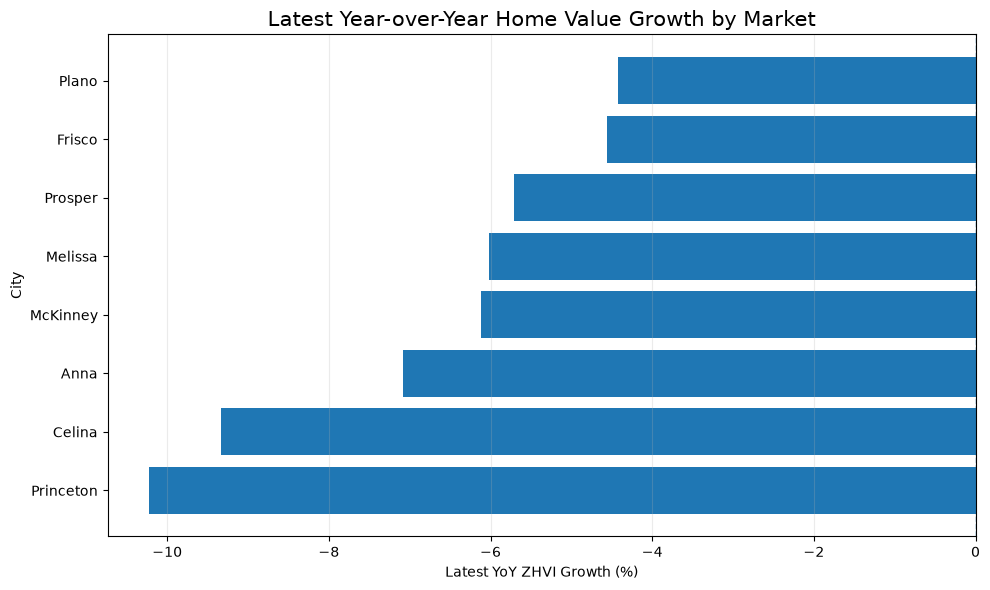

In [25]:
# -------------------------------------------------------------------
# LATEST YOY HOME VALUE GROWTH BY CITY
# -------------------------------------------------------------------

plot_data = price_summary.sort_values(
    "Latest_YoY_Pct"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["City"],
    plot_data["Latest_YoY_Pct"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Latest Year-over-Year Home Value Growth by Market",
    fontsize=15
)

ax.set_xlabel("Latest YoY ZHVI Growth (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

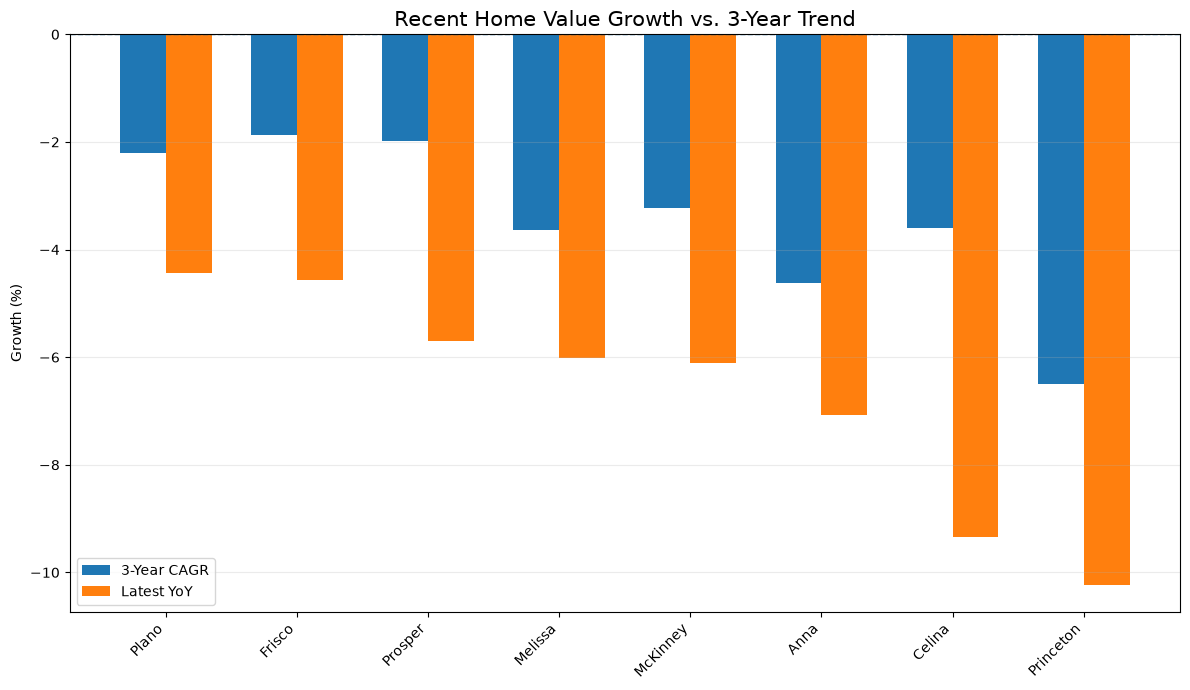

In [26]:
# -------------------------------------------------------------------
# CURRENT GROWTH VS 3-YEAR CAGR
# -------------------------------------------------------------------

comparison = price_summary[
    [
        "City",
        "Latest_YoY_Pct",
        "Three_Year_CAGR_Pct"
    ]
].copy()

comparison = comparison.sort_values(
    "Latest_YoY_Pct",
    ascending=False
)

x = np.arange(len(comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(
    x - width / 2,
    comparison["Three_Year_CAGR_Pct"],
    width,
    label="3-Year CAGR"
)

ax.bar(
    x + width / 2,
    comparison["Latest_YoY_Pct"],
    width,
    label="Latest YoY"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(
    comparison["City"],
    rotation=45,
    ha="right"
)

ax.set_title(
    "Recent Home Value Growth vs. 3-Year Trend",
    fontsize=15
)

ax.set_ylabel("Growth (%)")
ax.legend()

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [27]:
# -------------------------------------------------------------------
# PEAK ZHVI ANALYSIS
# -------------------------------------------------------------------

peak_summary = (
    df.loc[
        df.groupby("City")["ZHVI"].idxmax(),
        ["City", "Date", "ZHVI"]
    ]
    .rename(
        columns={
            "Date": "Peak_Date",
            "ZHVI": "Peak_ZHVI"
        }
    )
)

peak_summary = peak_summary.merge(
    latest_values[
        [
            "City",
            "Latest_Date",
            "Latest_ZHVI"
        ]
    ],
    on="City"
)

peak_summary["Change_From_Peak_Pct"] = (
    (
        peak_summary["Latest_ZHVI"]
        / peak_summary["Peak_ZHVI"]
    ) - 1
) * 100

peak_summary.sort_values(
    "Change_From_Peak_Pct"
)

,City,Peak_Date,Peak_ZHVI,Latest_Date,Latest_ZHVI,Change_From_Peak_Pct
6,Princeton,2022-08-31,"385,817.37",2026-07-31,"288,891.23",-25.12
0,Anna,2022-07-31,"435,906.92",2026-07-31,"345,077.93",-20.84
4,Melissa,2022-07-31,"524,567.99",2026-07-31,"430,393.87",-17.95
1,Celina,2022-07-31,"629,785.63",2026-07-31,"522,656.82",-17.01
3,McKinney,2022-07-31,"557,158.82",2026-07-31,"480,264.85",-13.80
7,Prosper,2022-07-31,"876,976.00",2026-07-31,"770,217.03",-12.17
2,Frisco,2022-07-31,"718,394.35",2026-07-31,"649,172.68",-9.64
5,Plano,2024-05-31,"550,232.57",2026-07-31,"499,723.21",-9.18


In [28]:
# -------------------------------------------------------------------
# MONTHS SINCE PEAK
# -------------------------------------------------------------------

peak_summary["Months_Since_Peak"] = (
    (
        peak_summary["Latest_Date"].dt.year
        - peak_summary["Peak_Date"].dt.year
    ) * 12
    +
    (
        peak_summary["Latest_Date"].dt.month
        - peak_summary["Peak_Date"].dt.month
    )
)

peak_summary[
    [
        "City",
        "Peak_Date",
        "Peak_ZHVI",
        "Latest_ZHVI",
        "Change_From_Peak_Pct",
        "Months_Since_Peak"
    ]
].sort_values(
    "Change_From_Peak_Pct"
)

,City,Peak_Date,Peak_ZHVI,Latest_ZHVI,Change_From_Peak_Pct,Months_Since_Peak
6,Princeton,2022-08-31,"385,817.37","288,891.23",-25.12,47
0,Anna,2022-07-31,"435,906.92","345,077.93",-20.84,48
4,Melissa,2022-07-31,"524,567.99","430,393.87",-17.95,48
1,Celina,2022-07-31,"629,785.63","522,656.82",-17.01,48
3,McKinney,2022-07-31,"557,158.82","480,264.85",-13.80,48
7,Prosper,2022-07-31,"876,976.00","770,217.03",-12.17,48
2,Frisco,2022-07-31,"718,394.35","649,172.68",-9.64,48
5,Plano,2024-05-31,"550,232.57","499,723.21",-9.18,26


In [29]:
# -------------------------------------------------------------------
# ADD PEAK METRICS TO PRICE SUMMARY
# -------------------------------------------------------------------

price_summary = price_summary.merge(
    peak_summary[
        [
            "City",
            "Peak_Date",
            "Peak_ZHVI",
            "Change_From_Peak_Pct",
            "Months_Since_Peak"
        ]
    ],
    on="City",
    how="left"
)

price_summary

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct,Full_Period_CAGR_Pct,Three_Year_CAGR_Pct,Five_Year_CAGR_Pct,Latest_YoY_Pct,Momentum_vs_3yr,Price_Momentum,Current_Price_Trend,Peak_Date,Peak_ZHVI,Change_From_Peak_Pct,Months_Since_Peak
0,Prosper,"482,988.47","770,217.03",59.47,5.65,-1.99,3.96,-5.71,-3.72,Declining / Weakening,Significant Decline,2022-07-31,"876,976.00",-12.17,48
1,Frisco,"430,859.52","649,172.68",50.67,4.94,-1.87,3.81,-4.56,-2.69,Declining / Weakening,Moderate Decline,2022-07-31,"718,394.35",-9.64,48
2,Celina,"359,592.10","522,656.82",45.35,4.50,-3.60,2.85,-9.34,-5.73,Declining / Weakening,Significant Decline,2022-07-31,"629,785.63",-17.01,48
3,McKinney,"336,476.43","480,264.85",42.73,4.28,-3.23,2.67,-6.11,-2.89,Declining / Weakening,Significant Decline,2022-07-31,"557,158.82",-13.80,48
4,Plano,"350,625.89","499,723.21",42.52,4.26,-2.21,3.23,-4.43,-2.22,Declining / Weakening,Moderate Decline,2024-05-31,"550,232.57",-9.18,26
5,Melissa,"306,192.92","430,393.87",40.56,4.09,-3.63,2.10,-6.02,-2.39,Declining / Weakening,Significant Decline,2022-07-31,"524,567.99",-17.95,48
6,Anna,"261,595.26","345,077.93",31.91,3.31,-4.62,1.01,-7.08,-2.46,Declining / Weakening,Significant Decline,2022-07-31,"435,906.92",-20.84,48
7,Princeton,"232,811.74","288,891.23",24.09,2.57,-6.50,-0.35,-10.23,-3.73,Declining / Weakening,Severe Decline,2022-08-31,"385,817.37",-25.12,47


In [30]:
# -------------------------------------------------------------------
# FINAL PRICE TREND SUMMARY
# -------------------------------------------------------------------

final_price_summary = price_summary[
    [
        "City",
        "Start_ZHVI",
        "Latest_ZHVI",
        "Total_Appreciation_Pct",
        "Five_Year_CAGR_Pct",
        "Three_Year_CAGR_Pct",
        "Latest_YoY_Pct",
        "Momentum_vs_3yr",
        "Change_From_Peak_Pct",
        "Months_Since_Peak",
        "Current_Price_Trend"
    ]
].sort_values(
    "Latest_YoY_Pct",
    ascending=False
)

final_price_summary.round(2)

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct,Five_Year_CAGR_Pct,Three_Year_CAGR_Pct,Latest_YoY_Pct,Momentum_vs_3yr,Change_From_Peak_Pct,Months_Since_Peak,Current_Price_Trend
4,Plano,"350,625.89","499,723.21",42.52,3.23,-2.21,-4.43,-2.22,-9.18,26,Moderate Decline
1,Frisco,"430,859.52","649,172.68",50.67,3.81,-1.87,-4.56,-2.69,-9.64,48,Moderate Decline
0,Prosper,"482,988.47","770,217.03",59.47,3.96,-1.99,-5.71,-3.72,-12.17,48,Significant Decline
5,Melissa,"306,192.92","430,393.87",40.56,2.10,-3.63,-6.02,-2.39,-17.95,48,Significant Decline
3,McKinney,"336,476.43","480,264.85",42.73,2.67,-3.23,-6.11,-2.89,-13.80,48,Significant Decline
6,Anna,"261,595.26","345,077.93",31.91,1.01,-4.62,-7.08,-2.46,-20.84,48,Significant Decline
2,Celina,"359,592.10","522,656.82",45.35,2.85,-3.60,-9.34,-5.73,-17.01,48,Significant Decline
7,Princeton,"232,811.74","288,891.23",24.09,-0.35,-6.50,-10.23,-3.73,-25.12,47,Severe Decline


### Price Trend Interpretation

All eight target markets are currently experiencing weaker home-value performance than their recent historical trends.

Plano and Frisco show the most resilience, with the smallest declines from peak values and the mildest current year-over-year declines.

Celina, Anna, Melissa, and Princeton show substantially deeper corrections. Princeton has experienced the largest decline from peak value at approximately 25%, while Celina shows the sharpest deterioration in recent momentum relative to its three-year trend.

These results indicate broad price-market cooling across North Dallas. However, price trends alone cannot determine whether a city is fundamentally weakening. Transaction activity, inventory, population growth, and residential construction must be incorporated before evaluating overall market strength.

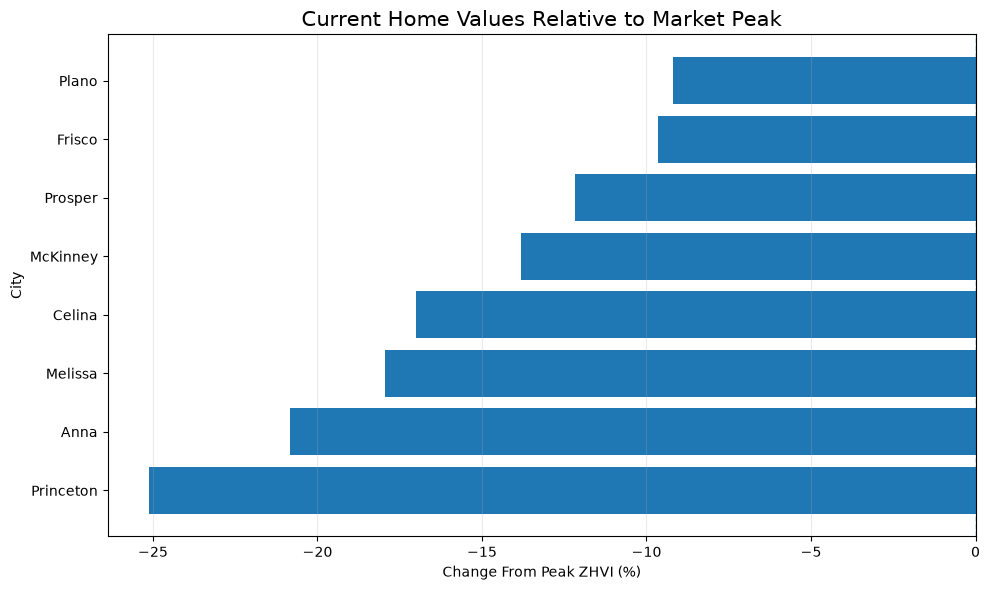

In [31]:
# -------------------------------------------------------------------
# CHANGE FROM PEAK ZHVI BY CITY
# -------------------------------------------------------------------

plot_data = final_price_summary.sort_values(
    "Change_From_Peak_Pct"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["City"],
    plot_data["Change_From_Peak_Pct"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Current Home Values Relative to Market Peak",
    fontsize=15
)

ax.set_xlabel("Change From Peak ZHVI (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# Transaction Activity Analysis

## 6. Housing Transaction Activity

Home-value appreciation alone does not indicate whether a housing market is strengthening or weakening.

This section evaluates actual housing-market activity to determine whether buyer demand and transaction volume are expanding or contracting across the target markets.

Key indicators include:

- Number of homes sold
- Year-over-year sales growth
- Annual transaction volume
- Change in transaction volume from peak levels
- Median sale price
- Days on market
- Housing inventory
- Months of supply

These indicators complement Zillow home-value trends by measuring the underlying level of market activity.

In [33]:
# -------------------------------------------------------------------
# REDFIN FILE PATH
# -------------------------------------------------------------------

REDFIN_FILE = (
    RAW_DATA_DIR
    / "redfin_housing_market_monthly_all_cities_2018_Jan_to_2026_Jul.csv"
)

print("Redfin file:", REDFIN_FILE)
print("File exists:", REDFIN_FILE.exists())

Redfin file: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/raw/redfin_housing_market_monthly_all_cities_2018_Jan_to_2026_Jul.csv
File exists: True


In [34]:
# -------------------------------------------------------------------
# LOAD RAW REDFIN DATA
# -------------------------------------------------------------------

redfin_raw = pd.read_csv(REDFIN_FILE)

print("Dataset shape:", redfin_raw.shape)

redfin_raw.head()

Dataset shape: (2667667, 21)


,LAST UPDATED,FREQUENCY,PERIOD BEGIN,PERIOD END,REGION ID,REGION TYPE,REGION NAME,HOMES SOLD,MEDIAN SALE PRICE NSA ($),MEDIAN DAYS ON MARKET (DAYS),AVERAGE SALE TO LIST RATIO (%),SHARE SOLD ABOVE ORIGINAL LIST (%),NEW LISTINGS,ACTIVE LISTINGS,INVENTORY,PENDING SALES,MEDIAN NEW LISTING PRICE ($),MEDIAN NEW LISTING PRICE PER SQ.FT. ($),MEDIAN SALE PRICE PER SQ.FT. ($),MONTHS OF SUPPLY,PERCENT OFF MARKET IN TWO WEEKS (%)
0,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,31349,City,"Aaronsburg, PA",NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,21117,City,"Aaronsburg, PA",1.00,"259,870.00",154.00,94.54,0.00,NaN,1.00,1.00,NaN,NaN,NaN,116.04,3.20,NaN
2,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,18,City,"Abbeville, AL",7.00,"212,893.00",95.00,96.00,0.00,10.00,16.00,12.00,9.00,"231,273.00",116.79,111.60,5.00,21.99
3,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,29,City,"Abbeville, GA",NaN,NaN,NaN,NaN,NaN,1.00,4.00,3.00,1.00,"133,712.00",111.31,NaN,NaN,0.00
4,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,3,City,"Abbeville, LA",16.00,"70,964.00",129.00,89.73,0.00,21.00,56.00,33.00,21.00,"89,141.00",64.29,59.43,6.20,4.71


In [35]:
# -------------------------------------------------------------------
# INSPECT REDFIN COLUMNS
# -------------------------------------------------------------------

print("Number of columns:", len(redfin_raw.columns))

for col in redfin_raw.columns:
    print(col)

Number of columns: 21
LAST UPDATED
FREQUENCY
PERIOD BEGIN
PERIOD END
REGION ID
REGION TYPE
REGION NAME
HOMES SOLD
MEDIAN SALE PRICE NSA ($)
MEDIAN DAYS ON MARKET (DAYS)
AVERAGE SALE TO LIST RATIO (%)
SHARE SOLD ABOVE ORIGINAL LIST (%)
NEW LISTINGS
ACTIVE LISTINGS
INVENTORY
PENDING SALES
MEDIAN NEW LISTING PRICE ($)
MEDIAN NEW LISTING PRICE PER SQ.FT. ($)
MEDIAN SALE PRICE PER SQ.FT. ($)
MONTHS OF SUPPLY
PERCENT OFF MARKET IN TWO WEEKS (%)


In [43]:
# -------------------------------------------------------------------
# DEFINE TARGET REDFIN REGIONS
# -------------------------------------------------------------------

TARGET_REDFIN_REGIONS = [
    "Anna, TX",
    "Celina, TX",
    "Frisco, TX",
    "McKinney, TX",
    "Melissa, TX",
    "Plano, TX",
    "Princeton, TX",
    "Prosper, TX",
]

redfin_target = redfin_raw[
    redfin_raw["REGION NAME"].isin(TARGET_REDFIN_REGIONS)
].copy()

print("Rows found:", len(redfin_target))
print("Regions found:")

for region in sorted(redfin_target["REGION NAME"].unique()):
    print("-", region)

Rows found: 808
Regions found:
- Anna, TX
- Celina, TX
- Frisco, TX
- McKinney, TX
- Melissa, TX
- Plano, TX
- Princeton, TX
- Prosper, TX


In [44]:
# -------------------------------------------------------------------
# VALIDATE REDFIN CITY COVERAGE
# -------------------------------------------------------------------

regions_found = set(
    redfin_target["REGION NAME"].unique()
)

regions_missing = sorted(
    set(TARGET_REDFIN_REGIONS)
    - regions_found
)

print("Target regions:", len(TARGET_REDFIN_REGIONS))
print("Regions found:", len(regions_found))

print("\nMissing regions:")

if regions_missing:
    for region in regions_missing:
        print("-", region)
else:
    print("None")

Target regions: 8
Regions found: 8

Missing regions:
None


In [45]:
# -------------------------------------------------------------------
# CHECK REDFIN DATA GRAIN
# -------------------------------------------------------------------

duplicate_count = redfin_target.duplicated(
    subset=["REGION NAME", "PERIOD END"]
).sum()

print("Duplicate region-period rows:", duplicate_count)

Duplicate region-period rows: 0


In [46]:
redfin_target.groupby(
    "REGION NAME"
).size().sort_values()

REGION NAME
Anna, TX         101
Celina, TX       101
Frisco, TX       101
McKinney, TX     101
Melissa, TX      101
Plano, TX        101
Princeton, TX    101
Prosper, TX      101
dtype: int64

In [47]:
# -------------------------------------------------------------------
# REDFIN DATA COVERAGE BY CITY
# -------------------------------------------------------------------

redfin_coverage = (
    redfin_target
    .groupby("REGION NAME")
    .agg(
        First_Period=("PERIOD END", "min"),
        Last_Period=("PERIOD END", "max"),
        Observations=("PERIOD END", "count")
    )
    .reset_index()
    .sort_values("REGION NAME")
)

redfin_coverage

,REGION NAME,First_Period,Last_Period,Observations
0,"Anna, TX",2018-03-31,2026-07-31,101
1,"Celina, TX",2018-03-31,2026-07-31,101
2,"Frisco, TX",2018-03-31,2026-07-31,101
3,"McKinney, TX",2018-03-31,2026-07-31,101
4,"Melissa, TX",2018-03-31,2026-07-31,101
5,"Plano, TX",2018-03-31,2026-07-31,101
6,"Princeton, TX",2018-03-31,2026-07-31,101
7,"Prosper, TX",2018-03-31,2026-07-31,101


In [48]:
# -------------------------------------------------------------------
# SELECT AND RENAME REDFIN VARIABLES
# -------------------------------------------------------------------

redfin_clean = redfin_target[
    [
        "REGION NAME",
        "PERIOD BEGIN",
        "PERIOD END",
        "HOMES SOLD",
        "MEDIAN SALE PRICE NSA ($)",
        "MEDIAN DAYS ON MARKET (DAYS)",
        "AVERAGE SALE TO LIST RATIO (%)",
        "SHARE SOLD ABOVE ORIGINAL LIST (%)",
        "NEW LISTINGS",
        "ACTIVE LISTINGS",
        "INVENTORY",
        "PENDING SALES",
        "MEDIAN SALE PRICE PER SQ.FT. ($)",
        "MONTHS OF SUPPLY",
        "PERCENT OFF MARKET IN TWO WEEKS (%)"
    ]
].copy()

redfin_clean = redfin_clean.rename(
    columns={
        "REGION NAME": "Region",
        "PERIOD BEGIN": "Period_Begin",
        "PERIOD END": "Date",
        "HOMES SOLD": "Homes_Sold",
        "MEDIAN SALE PRICE NSA ($)": "Median_Sale_Price",
        "MEDIAN DAYS ON MARKET (DAYS)": "Median_DOM",
        "AVERAGE SALE TO LIST RATIO (%)": "Sale_to_List_Pct",
        "SHARE SOLD ABOVE ORIGINAL LIST (%)": "Share_Sold_Above_List_Pct",
        "NEW LISTINGS": "New_Listings",
        "ACTIVE LISTINGS": "Active_Listings",
        "INVENTORY": "Inventory",
        "PENDING SALES": "Pending_Sales",
        "MEDIAN SALE PRICE PER SQ.FT. ($)": "Median_Sale_Price_Per_SqFt",
        "MONTHS OF SUPPLY": "Months_of_Supply",
        "PERCENT OFF MARKET IN TWO WEEKS (%)": "Pct_Off_Market_2_Weeks"
    }
)

redfin_clean.head()

,Region,Period_Begin,Date,Homes_Sold,Median_Sale_Price,Median_DOM,Sale_to_List_Pct,Share_Sold_Above_List_Pct,New_Listings,Active_Listings,Inventory,Pending_Sales,Median_Sale_Price_Per_SqFt,Months_of_Supply,Pct_Off_Market_2_Weeks
586,"Anna, TX",2026-05-01,2026-07-31,210.00,"350,814.00",76.00,97.73,2.93,314.00,663.00,402.00,216.00,163.27,5.90,12.43
3980,"Celina, TX",2026-05-01,2026-07-31,281.00,"509,745.00",83.00,96.50,3.64,468.00,988.00,626.00,297.00,185.79,6.80,11.41
8712,"Frisco, TX",2026-05-01,2026-07-31,730.00,"674,662.00",50.00,97.29,8.14,"1,118.00","2,102.00","1,158.00",706.00,230.03,4.90,23.29
15171,"McKinney, TX",2026-05-01,2026-07-31,796.00,"510,744.00",45.00,97.76,10.94,"1,081.00","2,018.00","1,054.00",796.00,211.31,4.10,25.40
15305,"Melissa, TX",2026-05-01,2026-07-31,105.00,"449,774.00",60.00,97.90,12.64,159.00,316.00,178.00,95.00,181.60,5.20,16.84


In [49]:
# -------------------------------------------------------------------
# CREATE CITY VARIABLE
# -------------------------------------------------------------------

redfin_clean["City"] = (
    redfin_clean["Region"]
    .str.replace(", TX", "", regex=False)
)

redfin_clean[
    ["Region", "City"]
].drop_duplicates().sort_values("City")

,Region,City
586,"Anna, TX",Anna
3980,"Celina, TX",Celina
8712,"Frisco, TX",Frisco
15171,"McKinney, TX",McKinney
15305,"Melissa, TX",Melissa
19264,"Plano, TX",Plano
19798,"Princeton, TX",Princeton
19837,"Prosper, TX",Prosper


In [50]:
# -------------------------------------------------------------------
# CREATE TIME VARIABLES
# -------------------------------------------------------------------

redfin_clean["Year"] = redfin_clean["Date"].dt.year
redfin_clean["Month"] = redfin_clean["Date"].dt.month

redfin_clean["YearMonth"] = (
    redfin_clean["Date"]
    .dt.to_period("M")
    .astype(str)
)

redfin_clean = (
    redfin_clean
    .sort_values(["City", "Date"])
    .reset_index(drop=True)
)

redfin_clean.head()

,Region,Period_Begin,Date,Homes_Sold,Median_Sale_Price,Median_DOM,Sale_to_List_Pct,Share_Sold_Above_List_Pct,New_Listings,Active_Listings,Inventory,Pending_Sales,Median_Sale_Price_Per_SqFt,Months_of_Supply,Pct_Off_Market_2_Weeks,City,Year,Month,YearMonth
0,"Anna, TX",2018-01-01,2018-03-31,129.00,"233,490.00",39.00,98.62,16.28,158.00,259.00,102.00,167.00,121.70,2.40,36.53,Anna,2018,3,2018-03
1,"Anna, TX",2018-02-01,2018-04-30,145.00,"236,000.00",42.00,98.75,14.48,179.00,272.00,101.00,183.00,123.13,2.10,39.89,Anna,2018,4,2018-04
2,"Anna, TX",2018-03-01,2018-05-31,169.00,"235,900.00",36.00,98.85,18.34,179.00,279.00,92.00,194.00,123.13,1.70,42.78,Anna,2018,5,2018-05
3,"Anna, TX",2018-04-01,2018-06-30,173.00,"234,900.00",36.00,99.11,21.39,190.00,288.00,116.00,185.00,123.13,2.00,43.24,Anna,2018,6,2018-06
4,"Anna, TX",2018-05-01,2018-07-31,168.00,"234,145.00",34.00,99.09,26.79,195.00,293.00,128.00,167.00,122.72,2.30,45.51,Anna,2018,7,2018-07


In [51]:
# -------------------------------------------------------------------
# MISSING VALUE SUMMARY
# -------------------------------------------------------------------

analysis_columns = [
    "Homes_Sold",
    "Median_Sale_Price",
    "Median_DOM",
    "Sale_to_List_Pct",
    "New_Listings",
    "Active_Listings",
    "Inventory",
    "Pending_Sales",
    "Median_Sale_Price_Per_SqFt",
    "Months_of_Supply",
    "Pct_Off_Market_2_Weeks"
]

missing_summary = (
    redfin_clean[analysis_columns]
    .isna()
    .sum()
    .to_frame("Missing")
)

missing_summary["Missing_Pct"] = (
    missing_summary["Missing"]
    / len(redfin_clean)
    * 100
)

missing_summary.round(2)

,Missing,Missing_Pct
Homes_Sold,0,0.00
Median_Sale_Price,0,0.00
Median_DOM,0,0.00
Sale_to_List_Pct,0,0.00
New_Listings,0,0.00
Active_Listings,0,0.00
Inventory,0,0.00
Pending_Sales,0,0.00
Median_Sale_Price_Per_SqFt,0,0.00
Months_of_Supply,0,0.00


In [52]:
# -------------------------------------------------------------------
# HOMES SOLD COVERAGE BY CITY
# -------------------------------------------------------------------

sales_coverage = (
    redfin_clean
    .groupby("City")["Homes_Sold"]
    .agg(
        Total_Periods="size",
        Available_Periods="count",
        Missing_Periods=lambda x: x.isna().sum()
    )
)

sales_coverage["Coverage_Pct"] = (
    sales_coverage["Available_Periods"]
    / sales_coverage["Total_Periods"]
    * 100
)

sales_coverage.round(1)

,Total_Periods,Available_Periods,Missing_Periods,Coverage_Pct
City,,,,
Anna,101,101,0,100.00
Celina,101,101,0,100.00
Frisco,101,101,0,100.00
McKinney,101,101,0,100.00
Melissa,101,101,0,100.00
Plano,101,101,0,100.00
Princeton,101,101,0,100.00
Prosper,101,101,0,100.00


### Rolling Transaction Activity

The Redfin dataset reports housing activity using rolling three-month periods. Therefore, each observation represents activity across an overlapping three-month window rather than an independent calendar month.

For this reason, `Homes Sold` observations are used to evaluate transaction trends and year-over-year changes but are **not summed across months to estimate annual transaction totals**.

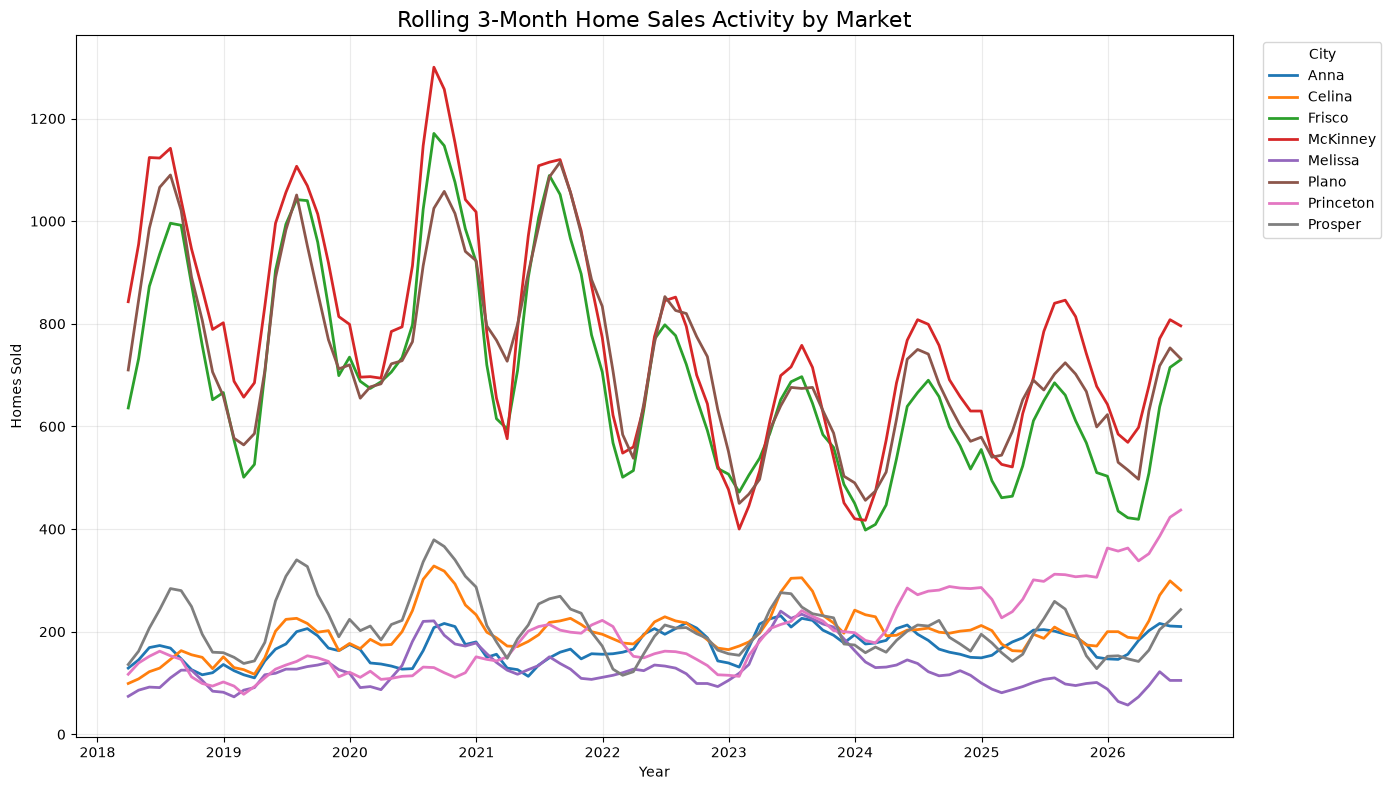

In [53]:
# -------------------------------------------------------------------
# ROLLING 3-MONTH HOMES SOLD
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))

for city in sorted(redfin_clean["City"].unique()):

    city_data = redfin_clean[
        redfin_clean["City"] == city
    ]

    ax.plot(
        city_data["Date"],
        city_data["Homes_Sold"],
        label=city,
        linewidth=2
    )

ax.set_title(
    "Rolling 3-Month Home Sales Activity by Market",
    fontsize=16
)

ax.set_xlabel("Year")
ax.set_ylabel("Homes Sold")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [54]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR CHANGE IN HOMES SOLD
# -------------------------------------------------------------------

redfin_clean["Homes_Sold_YoY_Pct"] = (
    redfin_clean
    .groupby("City")["Homes_Sold"]
    .pct_change(periods=12)
    * 100
)

redfin_clean[
    [
        "City",
        "Date",
        "Homes_Sold",
        "Homes_Sold_YoY_Pct"
    ]
].tail(20)

,City,Date,Homes_Sold,Homes_Sold_YoY_Pct
788,Prosper,2024-12-31,195.00,12.07
789,Prosper,2025-01-31,178.00,11.95
790,Prosper,2025-02-28,159.00,-6.47
791,Prosper,2025-03-31,142.00,-11.25
792,Prosper,2025-04-30,156.00,-14.75
793,Prosper,2025-05-31,196.00,-2.49
794,Prosper,2025-06-30,225.00,5.63
795,Prosper,2025-07-31,259.00,22.75
796,Prosper,2025-08-31,244.00,9.91
797,Prosper,2025-09-30,200.00,5.82


In [55]:
# -------------------------------------------------------------------
# LATEST TRANSACTION ACTIVITY
# -------------------------------------------------------------------

latest_sales = (
    redfin_clean
    .dropna(subset=["Homes_Sold"])
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Homes_Sold",
            "Homes_Sold_YoY_Pct"
        ]
    ]
    .sort_values(
        "Homes_Sold_YoY_Pct",
        ascending=False
    )
)

latest_sales.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_8142/3543148623.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_sales.round(2)


,City,Date,Homes_Sold,Homes_Sold_YoY_Pct
6,Princeton,2026-07-31,437.00,40.06
1,Celina,2026-07-31,281.00,34.45
2,Frisco,2026-07-31,730.00,6.57
0,Anna,2026-07-31,210.00,4.48
5,Plano,2026-07-31,732.00,4.27
4,Melissa,2026-07-31,105.00,-4.55
3,McKinney,2026-07-31,796.00,-5.24
7,Prosper,2026-07-31,243.00,-6.18


In [56]:
# -------------------------------------------------------------------
# PEAK TRANSACTION ACTIVITY
# -------------------------------------------------------------------

sales_peak = (
    redfin_clean
    .dropna(subset=["Homes_Sold"])
    .loc[
        lambda x: x.groupby("City")["Homes_Sold"].idxmax(),
        ["City", "Date", "Homes_Sold"]
    ]
    .rename(
        columns={
            "Date": "Peak_Sales_Date",
            "Homes_Sold": "Peak_Homes_Sold"
        }
    )
)

sales_peak = sales_peak.merge(
    latest_sales[
        [
            "City",
            "Date",
            "Homes_Sold",
            "Homes_Sold_YoY_Pct"
        ]
    ],
    on="City",
    how="left"
)

sales_peak = sales_peak.rename(
    columns={
        "Date": "Latest_Sales_Date",
        "Homes_Sold": "Latest_Homes_Sold"
    }
)

sales_peak["Change_From_Sales_Peak_Pct"] = (
    sales_peak["Latest_Homes_Sold"]
    / sales_peak["Peak_Homes_Sold"]
    - 1
) * 100

sales_peak[
    [
        "City",
        "Peak_Sales_Date",
        "Peak_Homes_Sold",
        "Latest_Homes_Sold",
        "Homes_Sold_YoY_Pct",
        "Change_From_Sales_Peak_Pct"
    ]
].sort_values(
    "Change_From_Sales_Peak_Pct",
    ascending=False
).round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_8142/2925041246.py:58: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(2)


,City,Peak_Sales_Date,Peak_Homes_Sold,Latest_Homes_Sold,Homes_Sold_YoY_Pct,Change_From_Sales_Peak_Pct
6,Princeton,2026-07-31,437.00,437.00,40.06,0.00
0,Anna,2023-05-31,231.00,210.00,4.48,-9.09
1,Celina,2020-08-31,328.00,281.00,34.45,-14.33
5,Plano,2021-08-31,"1,115.00",732.00,4.27,-34.35
7,Prosper,2020-08-31,379.00,243.00,-6.18,-35.88
2,Frisco,2020-08-31,"1,171.00",730.00,6.57,-37.66
3,McKinney,2020-08-31,"1,300.00",796.00,-5.24,-38.77
4,Melissa,2023-05-31,240.00,105.00,-4.55,-56.25


## 7. Housing Supply and Inventory

Transaction activity must be interpreted alongside housing supply.

An increase in home sales can indicate stronger buyer demand, but if inventory is increasing even faster, buyers may still have greater negotiating power and home prices may remain under pressure.

This section evaluates inventory growth, months of supply, new listings, and market time to determine whether housing supply is tightening or expanding.

In [57]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR INVENTORY GROWTH
# -------------------------------------------------------------------

redfin_clean["Inventory_YoY_Pct"] = (
    redfin_clean
    .groupby("City")["Inventory"]
    .pct_change(periods=12)
    * 100
)

In [58]:
# -------------------------------------------------------------------
# LATEST INVENTORY CONDITIONS
# -------------------------------------------------------------------

latest_inventory = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Inventory",
            "Inventory_YoY_Pct",
            "Months_of_Supply"
        ]
    ]
    .sort_values(
        "Inventory_YoY_Pct",
        ascending=False
    )
)

latest_inventory.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_8142/2677955740.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_inventory.round(2)


,City,Date,Inventory,Inventory_YoY_Pct,Months_of_Supply
1,Celina,2026-07-31,626.00,15.93,6.80
0,Anna,2026-07-31,402.00,10.74,5.90
2,Frisco,2026-07-31,"1,158.00",4.70,4.90
7,Prosper,2026-07-31,422.00,0.24,5.30
6,Princeton,2026-07-31,467.00,-1.06,3.30
3,McKinney,2026-07-31,"1,054.00",-10.07,4.10
4,Melissa,2026-07-31,178.00,-13.59,5.20
5,Plano,2026-07-31,807.00,-19.70,3.40


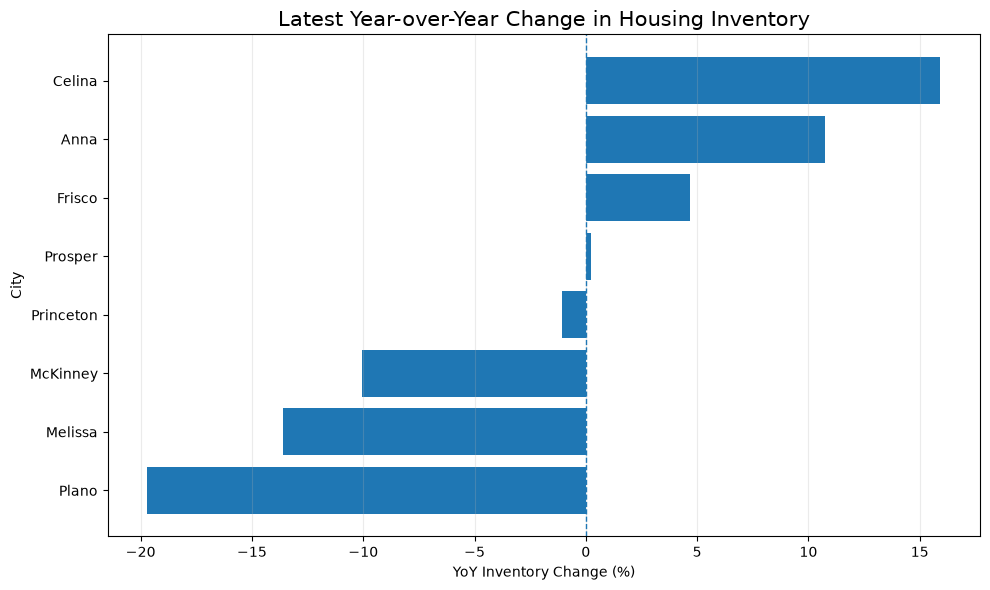

In [59]:
# -------------------------------------------------------------------
# LATEST YOY INVENTORY GROWTH
# -------------------------------------------------------------------

plot_data = latest_inventory.sort_values(
    "Inventory_YoY_Pct"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["City"],
    plot_data["Inventory_YoY_Pct"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Latest Year-over-Year Change in Housing Inventory",
    fontsize=15
)

ax.set_xlabel("YoY Inventory Change (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

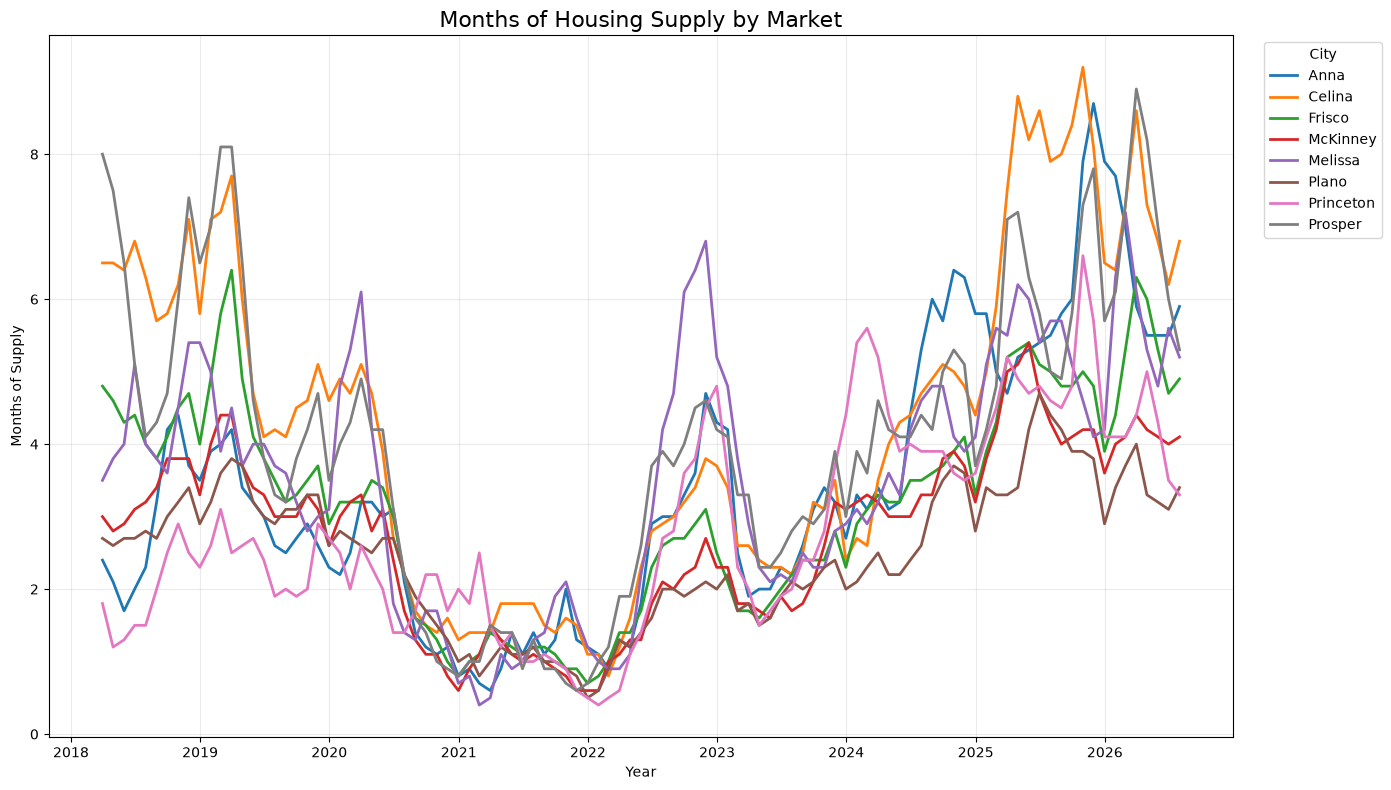

In [60]:
# -------------------------------------------------------------------
# MONTHS OF SUPPLY OVER TIME
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))

for city in sorted(redfin_clean["City"].unique()):

    city_data = redfin_clean[
        redfin_clean["City"] == city
    ]

    ax.plot(
        city_data["Date"],
        city_data["Months_of_Supply"],
        label=city,
        linewidth=2
    )

ax.set_title(
    "Months of Housing Supply by Market",
    fontsize=16
)

ax.set_xlabel("Year")
ax.set_ylabel("Months of Supply")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [61]:
latest_supply = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Months_of_Supply"
        ]
    ]
    .sort_values(
        "Months_of_Supply",
        ascending=False
    )
)

latest_supply.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_8142/504398252.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_supply.round(2)


,City,Date,Months_of_Supply
1,Celina,2026-07-31,6.80
0,Anna,2026-07-31,5.90
7,Prosper,2026-07-31,5.30
4,Melissa,2026-07-31,5.20
2,Frisco,2026-07-31,4.90
3,McKinney,2026-07-31,4.10
5,Plano,2026-07-31,3.40
6,Princeton,2026-07-31,3.30


In [62]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR CHANGE IN DAYS ON MARKET
# -------------------------------------------------------------------

redfin_clean["DOM_YoY_Change"] = (
    redfin_clean["Median_DOM"]
    - redfin_clean.groupby("City")["Median_DOM"].shift(12)
)

In [63]:
latest_dom = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Median_DOM",
            "DOM_YoY_Change"
        ]
    ]
    .sort_values(
        "DOM_YoY_Change",
        ascending=False
    )
)

latest_dom.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_8142/1432429127.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_dom.round(2)


,City,Date,Median_DOM,DOM_YoY_Change
0,Anna,2026-07-31,76.00,14.00
1,Celina,2026-07-31,83.00,10.00
4,Melissa,2026-07-31,60.00,3.00
2,Frisco,2026-07-31,50.00,2.00
5,Plano,2026-07-31,36.00,1.00
3,McKinney,2026-07-31,45.00,0.00
7,Prosper,2026-07-31,66.00,0.00
6,Princeton,2026-07-31,61.00,-5.00


In [64]:
# -------------------------------------------------------------------
# LATEST SALE-TO-LIST CONDITIONS
# -------------------------------------------------------------------

latest_sale_to_list = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Sale_to_List_Pct",
            "Share_Sold_Above_List_Pct",
            "Pct_Off_Market_2_Weeks"
        ]
    ]
    .sort_values(
        "Sale_to_List_Pct",
        ascending=False
    )
)

latest_sale_to_list.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_8142/4006450380.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_sale_to_list.round(2)


,City,Date,Sale_to_List_Pct,Share_Sold_Above_List_Pct,Pct_Off_Market_2_Weeks
4,Melissa,2026-07-31,97.90,12.64,16.84
5,Plano,2026-07-31,97.90,14.42,36.50
3,McKinney,2026-07-31,97.76,10.94,25.40
0,Anna,2026-07-31,97.73,2.93,12.43
6,Princeton,2026-07-31,97.33,10.55,12.12
2,Frisco,2026-07-31,97.29,8.14,23.29
1,Celina,2026-07-31,96.50,3.64,11.41
7,Prosper,2026-07-31,96.36,3.38,14.84


In [65]:
# -------------------------------------------------------------------
# COMBINED CURRENT MARKET CONDITIONS
# -------------------------------------------------------------------

market_conditions = (
    final_price_summary[
        [
            "City",
            "Latest_YoY_Pct",
            "Change_From_Peak_Pct"
        ]
    ]
    .merge(
        latest_sales[
            [
                "City",
                "Homes_Sold_YoY_Pct"
            ]
        ],
        on="City"
    )
    .merge(
        latest_inventory[
            [
                "City",
                "Inventory_YoY_Pct",
                "Months_of_Supply"
            ]
        ],
        on="City"
    )
    .merge(
        latest_dom[
            [
                "City",
                "Median_DOM",
                "DOM_YoY_Change"
            ]
        ],
        on="City"
    )
    .merge(
        latest_sale_to_list[
            [
                "City",
                "Sale_to_List_Pct"
            ]
        ],
        on="City"
    )
)

market_conditions = market_conditions.rename(
    columns={
        "Latest_YoY_Pct": "ZHVI_YoY_Pct",
        "Change_From_Peak_Pct": "ZHVI_From_Peak_Pct"
    }
)

market_conditions.round(2)

,City,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Homes_Sold_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Plano,-4.43,-9.18,4.27,-19.70,3.40,36.00,1.00,97.90
1,Frisco,-4.56,-9.64,6.57,4.70,4.90,50.00,2.00,97.29
2,Prosper,-5.71,-12.17,-6.18,0.24,5.30,66.00,0.00,96.36
3,Melissa,-6.02,-17.95,-4.55,-13.59,5.20,60.00,3.00,97.90
4,McKinney,-6.11,-13.80,-5.24,-10.07,4.10,45.00,0.00,97.76
5,Anna,-7.08,-20.84,4.48,10.74,5.90,76.00,14.00,97.73
6,Celina,-9.34,-17.01,34.45,15.93,6.80,83.00,10.00,96.50
7,Princeton,-10.23,-25.12,40.06,-1.06,3.30,61.00,-5.00,97.33


### Current Market Conditions — Initial Findings

The combined price and transaction indicators reveal that the eight markets are not experiencing the current housing slowdown in the same way.

**Princeton shows the strongest evidence of transaction recovery.** Although home values remain substantially below their historical peak, rolling three-month sales activity has reached a new high and is approximately 40% above the comparable period one year earlier. Inventory is approximately flat, while median days on market has improved. This suggests that lower prices may be attracting increased buyer activity.

**Celina also shows strong transaction growth, but under substantially greater supply pressure.** Home sales are approximately 34% higher year over year, while inventory has increased approximately 16%, months of supply is elevated, and homes are taking longer to sell. This combination suggests that transaction growth alone should not be interpreted as evidence of a tightening market.

**Plano and Frisco currently show comparatively resilient conditions**, with relatively modest price declines and positive year-over-year sales growth.

**Melissa, McKinney, and Prosper show weaker current demand signals**, with both home values and transaction activity declining year over year.

These findings remain preliminary. Population growth and residential construction must be incorporated to determine whether current supply and transaction patterns reflect weakening demand or the expansion of rapidly growing housing markets.

In [66]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR NEW LISTING GROWTH
# -------------------------------------------------------------------

redfin_clean["New_Listings_YoY_Pct"] = (
    redfin_clean
    .groupby("City")["New_Listings"]
    .pct_change(periods=12)
    * 100
)

latest_listings = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "New_Listings",
            "New_Listings_YoY_Pct",
            "Active_Listings",
            "Inventory"
        ]
    ]
    .sort_values(
        "New_Listings_YoY_Pct",
        ascending=False
    )
)

latest_listings.round(2)

,City,New_Listings,New_Listings_YoY_Pct,Active_Listings,Inventory
1,Celina,468.00,23.48,988.00,626.00
2,Frisco,"1,118.00",-0.18,"2,102.00","1,158.00"
0,Anna,314.00,-1.88,663.00,402.00
4,Melissa,159.00,-12.64,316.00,178.00
3,McKinney,"1,081.00",-14.55,"2,018.00","1,054.00"
6,Princeton,393.00,-15.67,970.00,467.00
5,Plano,994.00,-17.03,"1,661.00",807.00
7,Prosper,291.00,-18.94,728.00,422.00


In [67]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR PENDING SALES GROWTH
# -------------------------------------------------------------------

redfin_clean["Pending_Sales_YoY_Pct"] = (
    redfin_clean
    .groupby("City")["Pending_Sales"]
    .pct_change(periods=12)
    * 100
)

latest_pending = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Pending_Sales",
            "Pending_Sales_YoY_Pct"
        ]
    ]
    .sort_values(
        "Pending_Sales_YoY_Pct",
        ascending=False
    )
)

latest_pending.round(2)

,City,Pending_Sales,Pending_Sales_YoY_Pct
1,Celina,297.00,44.17
6,Princeton,452.00,39.94
0,Anna,216.00,5.88
2,Frisco,706.00,-1.81
5,Plano,748.00,-6.38
7,Prosper,221.00,-11.60
3,McKinney,796.00,-12.53
4,Melissa,95.00,-16.67


In [68]:
# -------------------------------------------------------------------
# EXPAND MARKET CONDITIONS TABLE
# -------------------------------------------------------------------

market_conditions = (
    market_conditions
    .merge(
        latest_listings[
            [
                "City",
                "New_Listings_YoY_Pct"
            ]
        ],
        on="City",
        how="left"
    )
    .merge(
        latest_pending[
            [
                "City",
                "Pending_Sales_YoY_Pct"
            ]
        ],
        on="City",
        how="left"
    )
)

market_conditions.round(2)

,City,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Homes_Sold_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct,New_Listings_YoY_Pct,Pending_Sales_YoY_Pct
0,Plano,-4.43,-9.18,4.27,-19.70,3.40,36.00,1.00,97.90,-17.03,-6.38
1,Frisco,-4.56,-9.64,6.57,4.70,4.90,50.00,2.00,97.29,-0.18,-1.81
2,Prosper,-5.71,-12.17,-6.18,0.24,5.30,66.00,0.00,96.36,-18.94,-11.60
3,Melissa,-6.02,-17.95,-4.55,-13.59,5.20,60.00,3.00,97.90,-12.64,-16.67
4,McKinney,-6.11,-13.80,-5.24,-10.07,4.10,45.00,0.00,97.76,-14.55,-12.53
5,Anna,-7.08,-20.84,4.48,10.74,5.90,76.00,14.00,97.73,-1.88,5.88
6,Celina,-9.34,-17.01,34.45,15.93,6.80,83.00,10.00,96.50,23.48,44.17
7,Princeton,-10.23,-25.12,40.06,-1.06,3.30,61.00,-5.00,97.33,-15.67,39.94


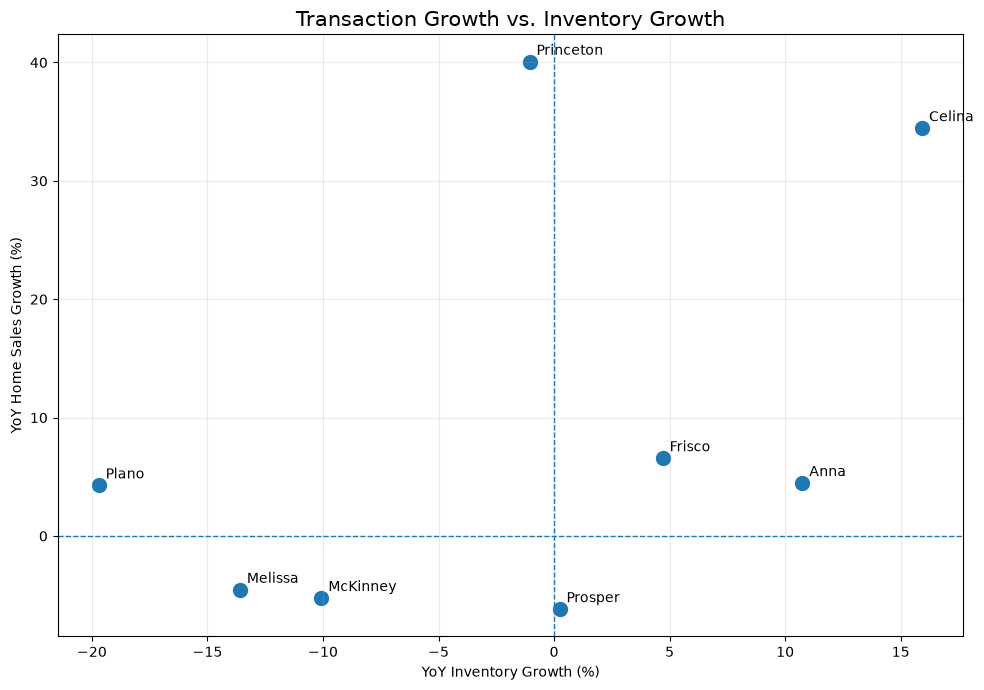

In [69]:
# -------------------------------------------------------------------
# SALES GROWTH VS INVENTORY GROWTH
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    market_conditions["Inventory_YoY_Pct"],
    market_conditions["Homes_Sold_YoY_Pct"],
    s=100
)

for _, row in market_conditions.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Inventory_YoY_Pct"],
            row["Homes_Sold_YoY_Pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Transaction Growth vs. Inventory Growth",
    fontsize=15
)

ax.set_xlabel("YoY Inventory Growth (%)")
ax.set_ylabel("YoY Home Sales Growth (%)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

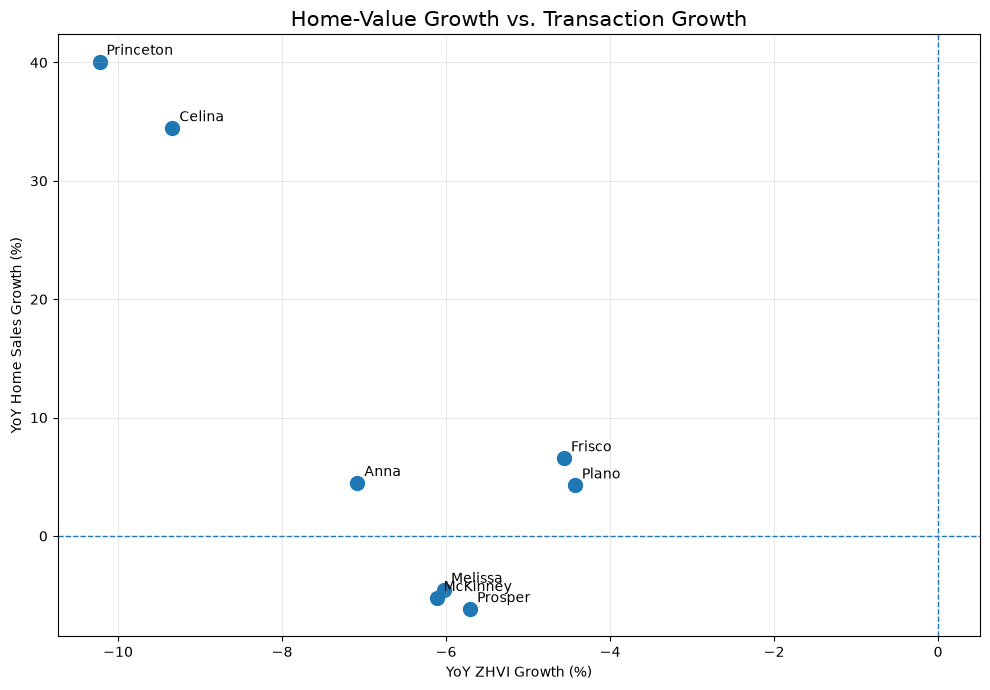

In [70]:
# -------------------------------------------------------------------
# PRICE GROWTH VS TRANSACTION GROWTH
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    market_conditions["ZHVI_YoY_Pct"],
    market_conditions["Homes_Sold_YoY_Pct"],
    s=100
)

for _, row in market_conditions.iterrows():
    ax.annotate(
        row["City"],
        (
            row["ZHVI_YoY_Pct"],
            row["Homes_Sold_YoY_Pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Home-Value Growth vs. Transaction Growth",
    fontsize=15
)

ax.set_xlabel("YoY ZHVI Growth (%)")
ax.set_ylabel("YoY Home Sales Growth (%)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [72]:
# -------------------------------------------------------------------
# EXPORT CLEAN REDFIN DATA
# -------------------------------------------------------------------

REDFIN_PROCESSED_FILE = (
    PROCESSED_DATA_DIR
    / "tx_redfin_market_activity.csv"
)

redfin_clean.to_csv(
    REDFIN_PROCESSED_FILE,
    index=False
)

print("Saved to:")
print(REDFIN_PROCESSED_FILE)

print("\nShape:", redfin_clean.shape)

Saved to:
/Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/tx_redfin_market_activity.csv

Shape: (808, 24)


In [73]:
redfin_check = pd.read_csv(
    REDFIN_PROCESSED_FILE,
    parse_dates=[
        "Period_Begin",
        "Date"
    ]
)

print("Reloaded shape:", redfin_check.shape)
print("Cities:", sorted(redfin_check["City"].unique()))
print(
    "Date range:",
    redfin_check["Date"].min(),
    "to",
    redfin_check["Date"].max()
)

Reloaded shape: (808, 24)
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper']
Date range: 2018-03-31 00:00:00 to 2026-07-31 00:00:00


### Housing Market Activity Findings

Current housing conditions vary substantially across the eight markets despite home values declining year over year in every city.

**Princeton currently shows the strongest transaction recovery.** Rolling home sales increased approximately 40% year over year, pending sales increased approximately 40%, and inventory remained roughly unchanged. Median days on market also declined, suggesting improving transaction velocity despite continued price declines.

**Celina also exhibits substantial transaction growth**, with home sales increasing approximately 34% and pending sales increasing approximately 44%. However, this demand growth is accompanied by a 16% increase in inventory, a 23% increase in new listings, elevated months of supply, longer marketing times, and greater discounts from listing prices. Celina therefore appears to be experiencing simultaneous growth in transaction activity and housing supply.

**Plano and Frisco show comparatively resilient conditions**, with positive sales growth and smaller home-value declines than several of the faster-growing outer markets.

**Anna shows modest transaction growth but rising inventory and longer marketing times**, suggesting that available supply is currently expanding faster than demand.

**Melissa, McKinney, and Prosper currently show broader cooling signals**, including declining home values, lower transaction activity, and declining pending sales.

Overall, falling home values do not necessarily indicate that a city's housing market is contracting. Transaction activity and housing supply must be evaluated alongside demographic and construction growth to distinguish cyclical price corrections from deterioration in underlying market fundamentals.

# Demographic Growth Analysis

## 8. Population Growth

Housing-market activity reflects current buying and selling conditions, but a growing real-estate market should also be supported by growth in the underlying population.

Population growth can increase long-term housing demand by expanding the number of households requiring housing.

This section evaluates:

- Historical population
- Total population growth
- Recent population growth
- Population CAGR
- Changes in the pace of population growth

Population trends will later be combined with housing-market and residential-construction indicators to distinguish long-term market expansion from short-term housing cycles.

In [75]:
# -------------------------------------------------------------------
# CENSUS POPULATION FILE PATH
# -------------------------------------------------------------------

CENSUS_DIR = PROJECT_ROOT / "data" / "raw" / "census"

CENSUS_FILE = (
    CENSUS_DIR
    / "SUB-IP-EST2025-POP-48.xlsx"
)

print("Census file:", CENSUS_FILE)
print("File exists:", CENSUS_FILE.exists())

Census file: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/raw/census/SUB-IP-EST2025-POP-48.xlsx
File exists: True


In [77]:
# -------------------------------------------------------------------
# INSPECT CENSUS WORKBOOK
# -------------------------------------------------------------------

xls = pd.ExcelFile(CENSUS_FILE)

print("Sheet names:")
for sheet in xls.sheet_names:
    print("-", sheet)

Sheet names:
- SUB-IP-EST2025-POP-48


In [80]:
# -------------------------------------------------------------------
# LOAD CENSUS POPULATION DATA
# -------------------------------------------------------------------

census_raw = pd.read_excel(
    CENSUS_FILE,
    sheet_name=0,
    header=None,
    skiprows=3
)

census_raw.columns = [
    "Geographic_Area",
    "Estimates_Base_2020",
    "Population_2020",
    "Population_2021",
    "Population_2022",
    "Population_2023",
    "Population_2024",
    "Population_2025",
]

print("Dataset shape:", census_raw.shape)

census_raw.head(10)

Dataset shape: (1231, 8)


,Geographic_Area,Estimates_Base_2020,Population_2020,Population_2021,Population_2022,Population_2023,Population_2024,Population_2025
0,NaN,NaN,"2,020.00","2,021.00","2,022.00","2,023.00","2,024.00","2,025.00"
1,"Abbott city, Texas",352.00,353.00,355.00,363.00,369.00,374.00,377.00
2,"Abernathy city, Texas","2,872.00","2,866.00","2,849.00","2,826.00","2,828.00","2,842.00","2,826.00"
3,"Abilene city, Texas","124,970.00","125,194.00","125,883.00","127,376.00","129,167.00","130,136.00","131,588.00"
4,"Ackerly city, Texas",265.00,265.00,266.00,265.00,265.00,265.00,269.00
5,"Addison town, Texas","17,090.00","17,091.00","17,417.00","17,341.00","17,295.00","17,302.00","17,195.00"
6,"Adrian city, Texas",130.00,131.00,130.00,131.00,134.00,136.00,136.00
7,"Agua Dulce city, Texas",693.00,692.00,687.00,679.00,673.00,669.00,662.00
8,"Alamo city, Texas","19,513.00","19,655.00","19,979.00","20,298.00","20,518.00","20,620.00","20,625.00"
9,"Alamo Heights city, Texas","7,362.00","7,380.00","7,456.00","7,570.00","7,536.00","7,623.00","7,632.00"


In [83]:
# -------------------------------------------------------------------
# CLEAN CENSUS GEOGRAPHIC NAMES
# -------------------------------------------------------------------

census_raw["City"] = (
    census_raw["Geographic_Area"]
    .astype(str)
    .str.replace(", Texas", "", regex=False)
    .str.replace(" city", "", regex=False)
    .str.replace(" town", "", regex=False)
    .str.replace(" village", "", regex=False)
    .str.strip()
)

census_raw[
    ["Geographic_Area", "City"]
].head(20)

,Geographic_Area,City
0,NaN,NaN
1,"Abbott city, Texas",Abbott
2,"Abernathy city, Texas",Abernathy
3,"Abilene city, Texas",Abilene
4,"Ackerly city, Texas",Ackerly
5,"Addison town, Texas",Addison
6,"Adrian city, Texas",Adrian
7,"Agua Dulce city, Texas",Agua Dulce
8,"Alamo city, Texas",Alamo
9,"Alamo Heights city, Texas",Alamo Heights


In [84]:
# -------------------------------------------------------------------
# REMOVE NON-DATA ROWS
# -------------------------------------------------------------------

census_raw = census_raw[
    census_raw["Geographic_Area"].notna()
].copy()

census_raw = census_raw[
    census_raw["City"].notna()
].copy()

census_raw = census_raw.reset_index(drop=True)

census_raw.head(10)

,Geographic_Area,Estimates_Base_2020,Population_2020,Population_2021,Population_2022,Population_2023,Population_2024,Population_2025,City
0,"Abbott city, Texas",352.00,353.00,355.00,363.00,369.00,374.00,377.00,Abbott
1,"Abernathy city, Texas","2,872.00","2,866.00","2,849.00","2,826.00","2,828.00","2,842.00","2,826.00",Abernathy
2,"Abilene city, Texas","124,970.00","125,194.00","125,883.00","127,376.00","129,167.00","130,136.00","131,588.00",Abilene
3,"Ackerly city, Texas",265.00,265.00,266.00,265.00,265.00,265.00,269.00,Ackerly
4,"Addison town, Texas","17,090.00","17,091.00","17,417.00","17,341.00","17,295.00","17,302.00","17,195.00",Addison
5,"Adrian city, Texas",130.00,131.00,130.00,131.00,134.00,136.00,136.00,Adrian
6,"Agua Dulce city, Texas",693.00,692.00,687.00,679.00,673.00,669.00,662.00,Agua Dulce
7,"Alamo city, Texas","19,513.00","19,655.00","19,979.00","20,298.00","20,518.00","20,620.00","20,625.00",Alamo
8,"Alamo Heights city, Texas","7,362.00","7,380.00","7,456.00","7,570.00","7,536.00","7,623.00","7,632.00",Alamo Heights
9,"Alba town, Texas",472.00,473.00,483.00,491.00,502.00,508.00,511.00,Alba


In [85]:
# -------------------------------------------------------------------
# FILTER TARGET CITIES
# -------------------------------------------------------------------

TARGET_CITIES = [
    "Anna",
    "Celina",
    "Frisco",
    "McKinney",
    "Melissa",
    "Plano",
    "Princeton",
    "Prosper",
]

census_target = census_raw[
    census_raw["City"].isin(TARGET_CITIES)
].copy()

print("Rows found:", len(census_target))

census_target[
    [
        "City",
        "Geographic_Area",
        "Population_2020",
        "Population_2021",
        "Population_2022",
        "Population_2023",
        "Population_2024",
        "Population_2025",
    ]
].sort_values("City")

Rows found: 8


,City,Geographic_Area,Population_2020,Population_2021,Population_2022,Population_2023,Population_2024,Population_2025
29,Anna,"Anna city, Texas","17,616.00","20,459.00","23,825.00","27,938.00","31,996.00","35,245.00"
184,Celina,"Celina city, Texas","18,033.00","24,097.00","34,476.00","43,820.00","51,717.00","64,427.00"
383,Frisco,"Frisco city, Texas","202,749.00","211,127.00","220,399.00","226,878.00","235,159.00","236,955.00"
666,McKinney,"McKinney city, Texas","197,507.00","203,569.00","208,584.00","215,834.00","227,497.00","236,001.00"
694,Melissa,"Melissa city, Texas","14,339.00","16,969.00","19,423.00","23,800.00","26,178.00","29,969.00"
853,Plano,"Plano city, Texas","286,414.00","288,912.00","291,123.00","293,395.00","293,395.00","293,028.00"
882,Princeton,"Princeton city, Texas","17,501.00","20,071.00","22,962.00","28,234.00","36,856.00","43,524.00"
885,Prosper,"Prosper town, Texas","30,829.00","34,159.00","37,870.00","42,030.00","44,511.00","45,605.00"


In [86]:
# validation
cities_found = sorted(census_target["City"].unique())
cities_missing = sorted(set(TARGET_CITIES) - set(cities_found))

print("Cities found:")
for city in cities_found:
    print("-", city)

print("\nCities missing:")
if cities_missing:
    for city in cities_missing:
        print("-", city)
else:
    print("None")

Cities found:
- Anna
- Celina
- Frisco
- McKinney
- Melissa
- Plano
- Princeton
- Prosper

Cities missing:
None


In [87]:
population_cols = [
    "Population_2020",
    "Population_2021",
    "Population_2022",
    "Population_2023",
    "Population_2024",
    "Population_2025",
]

In [88]:
population_long = census_target.melt(
    id_vars=["City"],
    value_vars=population_cols,
    var_name="Population_Year",
    value_name="Population"
)

population_long["Year"] = (
    population_long["Population_Year"]
    .str.replace("Population_", "", regex=False)
    .astype(int)
)

population_long = (
    population_long
    .drop(columns=["Population_Year"])
    .sort_values(["City", "Year"])
    .reset_index(drop=True)
)

In [89]:
print("Cities:", population_long["City"].nunique())
print("Years:", sorted(population_long["Year"].unique()))
print("Observations:", len(population_long))
print("Missing population values:", population_long["Population"].isna().sum())
print(
    "Duplicate city-years:",
    population_long.duplicated(["City", "Year"]).sum()
)

Cities: 8
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Observations: 48
Missing population values: 0
Duplicate city-years: 0


In [90]:
# -------------------------------------------------------------------
# POPULATION BY CITY AND YEAR
# -------------------------------------------------------------------

population_pivot = (
    population_long
    .pivot(
        index="City",
        columns="Year",
        values="Population"
    )
)

population_pivot

Year,2020,2021,2022,2023,2024,2025
City,,,,,,
Anna,"17,616.00","20,459.00","23,825.00","27,938.00","31,996.00","35,245.00"
Celina,"18,033.00","24,097.00","34,476.00","43,820.00","51,717.00","64,427.00"
Frisco,"202,749.00","211,127.00","220,399.00","226,878.00","235,159.00","236,955.00"
McKinney,"197,507.00","203,569.00","208,584.00","215,834.00","227,497.00","236,001.00"
Melissa,"14,339.00","16,969.00","19,423.00","23,800.00","26,178.00","29,969.00"
Plano,"286,414.00","288,912.00","291,123.00","293,395.00","293,395.00","293,028.00"
Princeton,"17,501.00","20,071.00","22,962.00","28,234.00","36,856.00","43,524.00"
Prosper,"30,829.00","34,159.00","37,870.00","42,030.00","44,511.00","45,605.00"


In [91]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR POPULATION GROWTH
# -------------------------------------------------------------------

population_long["Population_YoY_Pct"] = (
    population_long
    .groupby("City")["Population"]
    .pct_change()
    * 100
)

population_long[
    [
        "City",
        "Year",
        "Population",
        "Population_YoY_Pct"
    ]
].round(2)

,City,Year,Population,Population_YoY_Pct
0,Anna,2020,"17,616.00",NaN
1,Anna,2021,"20,459.00",16.14
2,Anna,2022,"23,825.00",16.45
3,Anna,2023,"27,938.00",17.26
4,Anna,2024,"31,996.00",14.53
5,Anna,2025,"35,245.00",10.15
6,Celina,2020,"18,033.00",NaN
7,Celina,2021,"24,097.00",33.63
8,Celina,2022,"34,476.00",43.07
9,Celina,2023,"43,820.00",27.10


In [92]:
# -------------------------------------------------------------------
# POPULATION GROWTH SUMMARY
# -------------------------------------------------------------------

population_summary = (
    population_long
    .groupby("City")
    .agg(
        Start_Year=("Year", "first"),
        Latest_Year=("Year", "last"),
        Start_Population=("Population", "first"),
        Latest_Population=("Population", "last")
    )
    .reset_index()
)

population_summary["Population_Change"] = (
    population_summary["Latest_Population"]
    - population_summary["Start_Population"]
)

population_summary["Total_Population_Growth_Pct"] = (
    (
        population_summary["Latest_Population"]
        / population_summary["Start_Population"]
    ) - 1
) * 100

population_summary[
    [
        "City",
        "Start_Population",
        "Latest_Population",
        "Population_Change",
        "Total_Population_Growth_Pct"
    ]
].sort_values(
    "Total_Population_Growth_Pct",
    ascending=False
).round(2)

,City,Start_Population,Latest_Population,Population_Change,Total_Population_Growth_Pct
1,Celina,"18,033.00","64,427.00","46,394.00",257.27
6,Princeton,"17,501.00","43,524.00","26,023.00",148.69
4,Melissa,"14,339.00","29,969.00","15,630.00",109.00
0,Anna,"17,616.00","35,245.00","17,629.00",100.07
7,Prosper,"30,829.00","45,605.00","14,776.00",47.93
3,McKinney,"197,507.00","236,001.00","38,494.00",19.49
2,Frisco,"202,749.00","236,955.00","34,206.00",16.87
5,Plano,"286,414.00","293,028.00","6,614.00",2.31


In [93]:
# -------------------------------------------------------------------
# POPULATION CAGR
# -------------------------------------------------------------------

population_summary["Years"] = (
    population_summary["Latest_Year"]
    - population_summary["Start_Year"]
)

population_summary["Population_CAGR_Pct"] = (
    (
        population_summary["Latest_Population"]
        / population_summary["Start_Population"]
    )
    ** (1 / population_summary["Years"])
    - 1
) * 100

population_summary[
    [
        "City",
        "Start_Population",
        "Latest_Population",
        "Total_Population_Growth_Pct",
        "Population_CAGR_Pct"
    ]
].sort_values(
    "Population_CAGR_Pct",
    ascending=False
).round(2)

,City,Start_Population,Latest_Population,Total_Population_Growth_Pct,Population_CAGR_Pct
1,Celina,"18,033.00","64,427.00",257.27,29.00
6,Princeton,"17,501.00","43,524.00",148.69,19.99
4,Melissa,"14,339.00","29,969.00",109.00,15.89
0,Anna,"17,616.00","35,245.00",100.07,14.88
7,Prosper,"30,829.00","45,605.00",47.93,8.15
3,McKinney,"197,507.00","236,001.00",19.49,3.63
2,Frisco,"202,749.00","236,955.00",16.87,3.17
5,Plano,"286,414.00","293,028.00",2.31,0.46


In [94]:
# -------------------------------------------------------------------
# LATEST POPULATION GROWTH
# -------------------------------------------------------------------

latest_population_growth = (
    population_long
    .dropna(subset=["Population_YoY_Pct"])
    .sort_values("Year")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Year",
            "Population",
            "Population_YoY_Pct"
        ]
    ]
    .sort_values(
        "Population_YoY_Pct",
        ascending=False
    )
)

latest_population_growth.round(2)

,City,Year,Population,Population_YoY_Pct
1,Celina,2025,"64,427.00",24.58
6,Princeton,2025,"43,524.00",18.09
4,Melissa,2025,"29,969.00",14.48
0,Anna,2025,"35,245.00",10.15
3,McKinney,2025,"236,001.00",3.74
7,Prosper,2025,"45,605.00",2.46
2,Frisco,2025,"236,955.00",0.76
5,Plano,2025,"293,028.00",-0.13


In [95]:
# -------------------------------------------------------------------
# POPULATION GROWTH ACCELERATION
# -------------------------------------------------------------------

population_long["Previous_Population_YoY_Pct"] = (
    population_long
    .groupby("City")["Population_YoY_Pct"]
    .shift(1)
)

population_long["Population_Growth_Acceleration"] = (
    population_long["Population_YoY_Pct"]
    - population_long["Previous_Population_YoY_Pct"]
)

In [96]:
latest_population_momentum = (
    population_long
    .dropna(
        subset=[
            "Population_YoY_Pct",
            "Previous_Population_YoY_Pct"
        ]
    )
    .sort_values("Year")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Year",
            "Population",
            "Population_YoY_Pct",
            "Previous_Population_YoY_Pct",
            "Population_Growth_Acceleration"
        ]
    ]
    .sort_values(
        "Population_Growth_Acceleration",
        ascending=False
    )
)

latest_population_momentum.round(2)

,City,Year,Population,Population_YoY_Pct,Previous_Population_YoY_Pct,Population_Growth_Acceleration
1,Celina,2025,"64,427.00",24.58,18.02,6.55
4,Melissa,2025,"29,969.00",14.48,9.99,4.49
5,Plano,2025,"293,028.00",-0.13,0.00,-0.13
3,McKinney,2025,"236,001.00",3.74,5.40,-1.67
2,Frisco,2025,"236,955.00",0.76,3.65,-2.89
7,Prosper,2025,"45,605.00",2.46,5.90,-3.45
0,Anna,2025,"35,245.00",10.15,14.53,-4.37
6,Princeton,2025,"43,524.00",18.09,30.54,-12.45


In [97]:
# -------------------------------------------------------------------
# FINAL POPULATION SUMMARY
# -------------------------------------------------------------------

population_summary = population_summary.merge(
    latest_population_momentum[
        [
            "City",
            "Population_YoY_Pct",
            "Population_Growth_Acceleration"
        ]
    ],
    on="City",
    how="left"
)

population_summary = population_summary.rename(
    columns={
        "Population_YoY_Pct": "Latest_Population_YoY_Pct"
    }
)

population_summary[
    [
        "City",
        "Start_Population",
        "Latest_Population",
        "Population_Change",
        "Total_Population_Growth_Pct",
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",
        "Population_Growth_Acceleration"
    ]
].sort_values(
    "Population_CAGR_Pct",
    ascending=False
).round(2)

,City,Start_Population,Latest_Population,Population_Change,Total_Population_Growth_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration
1,Celina,"18,033.00","64,427.00","46,394.00",257.27,29.00,24.58,6.55
6,Princeton,"17,501.00","43,524.00","26,023.00",148.69,19.99,18.09,-12.45
4,Melissa,"14,339.00","29,969.00","15,630.00",109.00,15.89,14.48,4.49
0,Anna,"17,616.00","35,245.00","17,629.00",100.07,14.88,10.15,-4.37
7,Prosper,"30,829.00","45,605.00","14,776.00",47.93,8.15,2.46,-3.45
3,McKinney,"197,507.00","236,001.00","38,494.00",19.49,3.63,3.74,-1.67
2,Frisco,"202,749.00","236,955.00","34,206.00",16.87,3.17,0.76,-2.89
5,Plano,"286,414.00","293,028.00","6,614.00",2.31,0.46,-0.13,-0.13


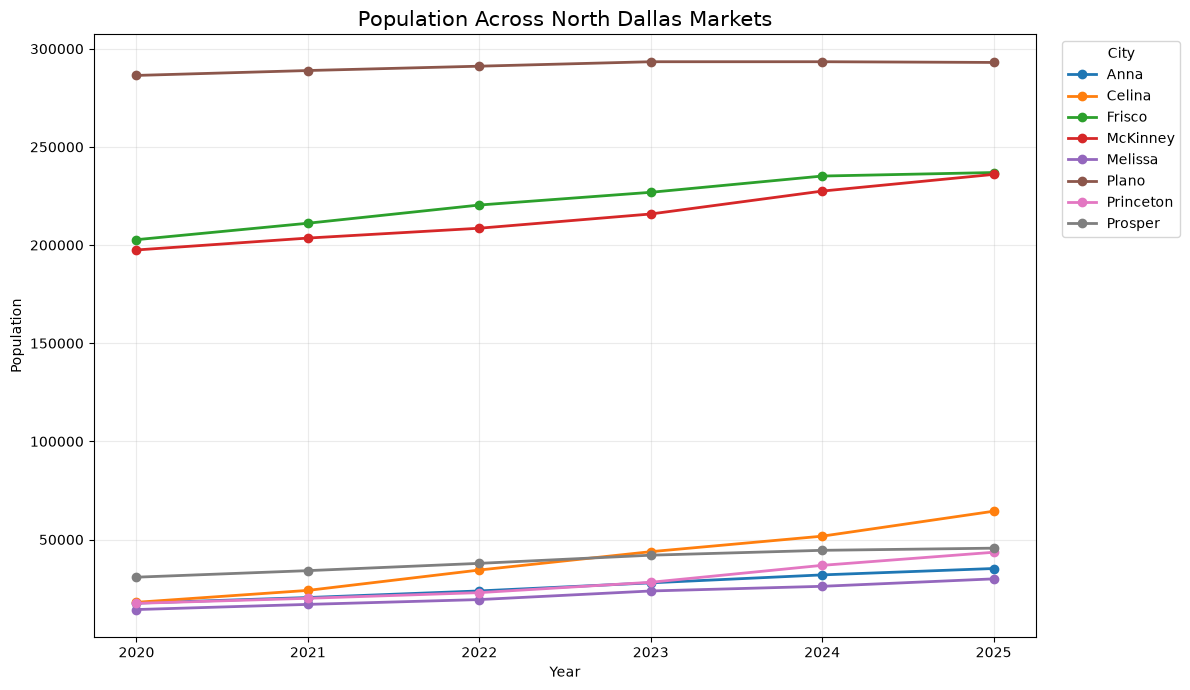

In [98]:
# -------------------------------------------------------------------
# POPULATION OVER TIME
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

for city in sorted(population_long["City"].unique()):

    city_data = population_long[
        population_long["City"] == city
    ]

    ax.plot(
        city_data["Year"],
        city_data["Population"],
        marker="o",
        linewidth=2,
        label=city
    )

ax.set_title(
    "Population Across North Dallas Markets",
    fontsize=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Population")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [100]:
# -------------------------------------------------------------------
# INDEX POPULATION TO 2020 = 100
# -------------------------------------------------------------------

population_long["Starting_Population"] = (
    population_long
    .groupby("City")["Population"]
    .transform("first")
)

population_long["Population_Index_2020"] = (
    population_long["Population"]
    / population_long["Starting_Population"]
    * 100
)

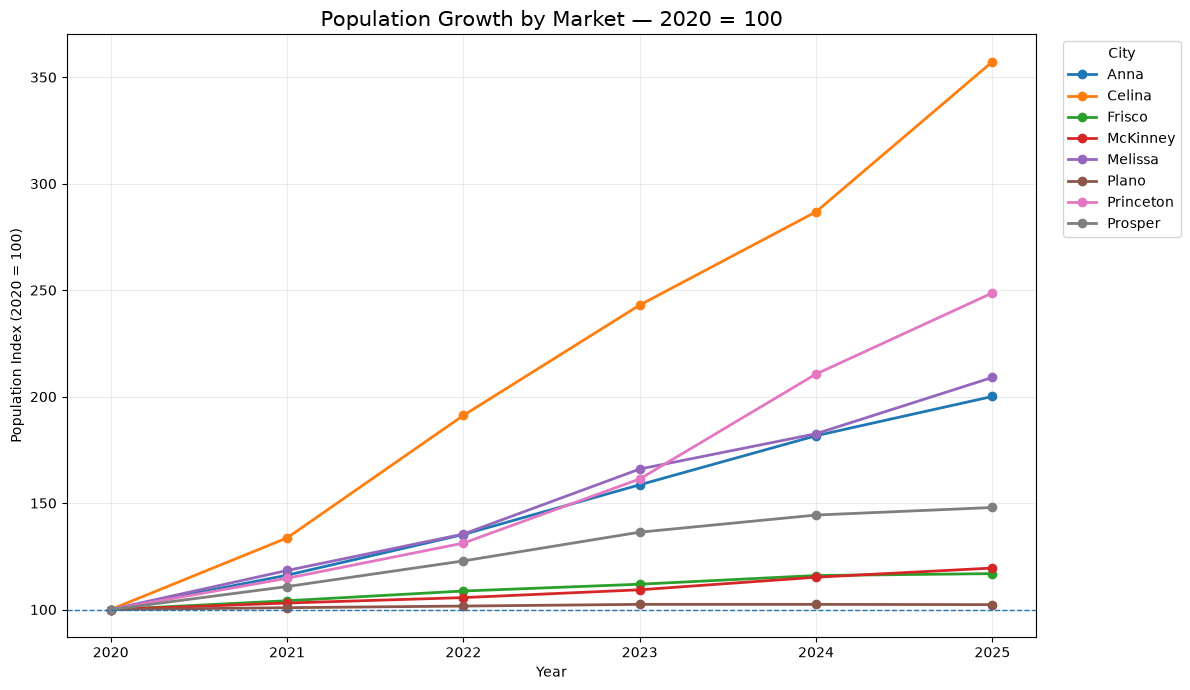

In [101]:
fig, ax = plt.subplots(figsize=(12, 7))

for city in sorted(population_long["City"].unique()):

    city_data = population_long[
        population_long["City"] == city
    ]

    ax.plot(
        city_data["Year"],
        city_data["Population_Index_2020"],
        marker="o",
        linewidth=2,
        label=city
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Population Growth by Market — 2020 = 100",
    fontsize=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Population Index (2020 = 100)")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

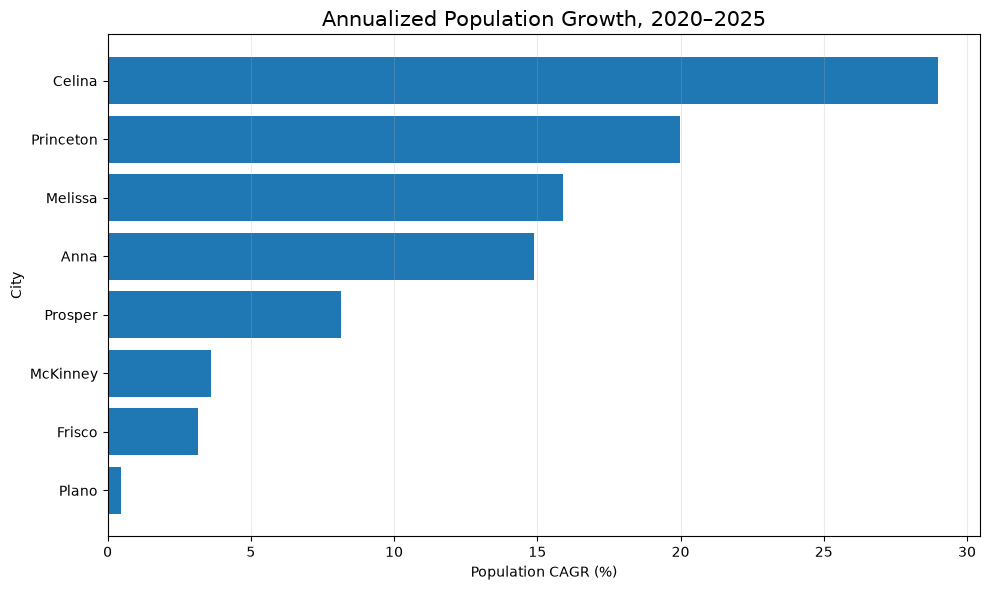

In [102]:
# -------------------------------------------------------------------
# POPULATION CAGR BY CITY
# -------------------------------------------------------------------

plot_data = population_summary.sort_values(
    "Population_CAGR_Pct"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["City"],
    plot_data["Population_CAGR_Pct"]
)

ax.set_title(
    "Annualized Population Growth, 2020–2025",
    fontsize=15
)

ax.set_xlabel("Population CAGR (%)")
ax.set_ylabel("City")

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

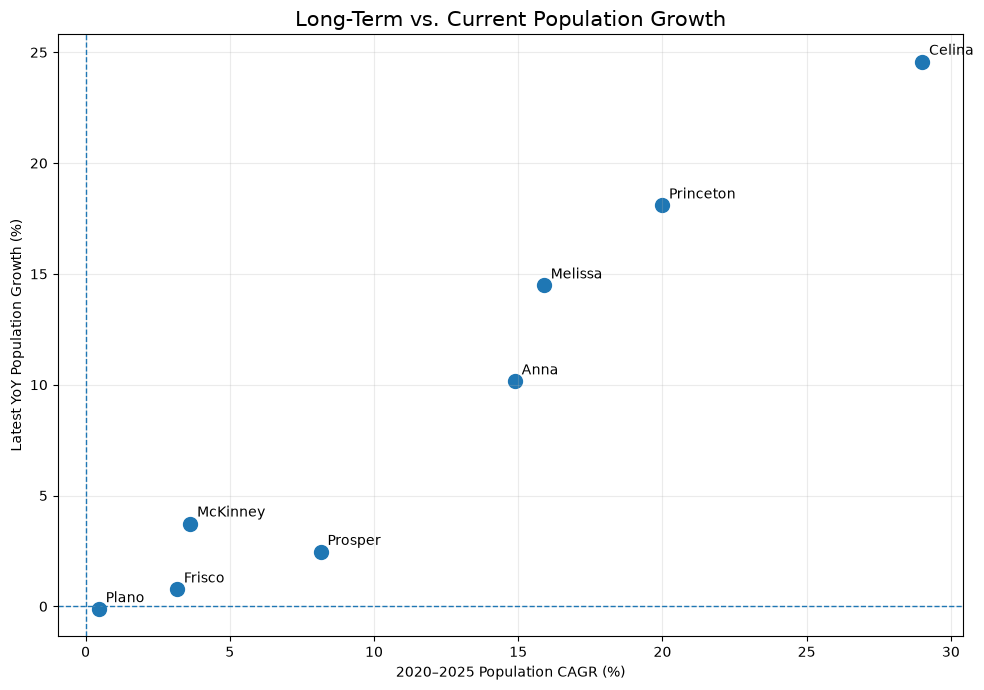

In [104]:
# -------------------------------------------------------------------
# LONG-TERM VS CURRENT POPULATION GROWTH
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    population_summary["Population_CAGR_Pct"],
    population_summary["Latest_Population_YoY_Pct"],
    s=100
)

for _, row in population_summary.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Population_CAGR_Pct"],
            row["Latest_Population_YoY_Pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)

ax.set_title(
    "Long-Term vs. Current Population Growth",
    fontsize=15
)

ax.set_xlabel("2020–2025 Population CAGR (%)")
ax.set_ylabel("Latest YoY Population Growth (%)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------------------
# EXPORT CLEAN POPULATION DATA
# -------------------------------------------------------------------

POPULATION_FILE = (
    PROCESSED_DATA_DIR
    / "tx_population_annual.csv"
)

population_long.to_csv(
    POPULATION_FILE,
    index=False
)

print("Saved:", POPULATION_FILE)
print("Shape:", population_long.shape)

In [106]:
POPULATION_SUMMARY_FILE = (
    PROCESSED_DATA_DIR
    / "tx_population_summary.csv"
)

population_summary.to_csv(
    POPULATION_SUMMARY_FILE,
    index=False
)

print("Saved:", POPULATION_SUMMARY_FILE)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/tx_population_summary.csv


### Demographic Growth Findings

Population growth reveals substantial differences in the long-term expansion of the eight North Dallas markets.

**Celina exhibits exceptional demographic expansion.** Its estimated population increased from approximately 18,000 in 2020 to more than 64,000 in 2025, representing total growth of approximately 257% and an annualized growth rate of 29%. Population growth also accelerated in the latest year.

**Princeton, Melissa, and Anna are also rapidly expanding markets.** Princeton's population increased approximately 149%, while Melissa and Anna approximately doubled in population between 2020 and 2025.

**Prosper continues to show substantial long-term growth**, although its latest annual growth rate is considerably slower than its earlier pace.

**McKinney and Frisco continue to add residents but at substantially lower percentage growth rates than the smaller outer-ring markets.** Their larger population bases mean that even moderate percentage growth can represent substantial absolute increases in residents.

**Plano represents the most mature demographic market in the comparison.** Population changed relatively little between 2020 and 2025 and declined slightly in the latest annual estimate.

These results demonstrate why current housing-market momentum and long-term growth fundamentals should be evaluated separately. Several rapidly growing cities are currently experiencing declining home values despite substantial underlying population expansion.

In [ ]:
# -------------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------------

BPS_DIR = PROJECT_ROOT / "data" / "raw" / "bps"

for file in BPS_DIR.iterdir():
    print(file.name)

.DS_Store
footnote2025.xlsx
so2025a.txt


In [111]:
bps_2025_file = BPS_DIR / "so2025a.txt"

bps_2025_raw = pd.read_csv(
    bps_2025_file
)

print("Shape:", bps_2025_raw.shape)
print("\nColumns:")
print(bps_2025_raw.columns.tolist())

Shape: (4459, 40)

Columns:
['Survey', 'State', '6-Digit', 'County', 'Census Place', 'FIPS Place', 'FIPS MCD', 'Pop', 'CSA', 'CBSA', 'Footnote', 'Central', 'Zip', 'Region', 'Division', 'Number of', 'Place', 'Unnamed: 17', '1-unit', 'Unnamed: 19', 'Unnamed: 20', '2-units', 'Unnamed: 22', 'Unnamed: 23', '3-4 units', 'Unnamed: 25', 'Unnamed: 26', '5+ units', 'Unnamed: 28', 'Unnamed: 29', '1-unit rep', 'Unnamed: 31', 'Unnamed: 32', '2-units rep', 'Unnamed: 34', 'Unnamed: 35', '3-4 units rep', 'Unnamed: 37', 'Unnamed: 38', '5+ units rep']


In [112]:
bps_2025_raw.head()

,Survey,State,6-Digit,County,Census Place,FIPS Place,FIPS MCD,Pop,CSA,CBSA,Footnote,Central,Zip,Region,Division,Number of,Place,Unnamed: 17,1-unit,Unnamed: 19,Unnamed: 20,2-units,Unnamed: 22,Unnamed: 23,3-4 units,Unnamed: 25,Unnamed: 26,5+ units,Unnamed: 28,Unnamed: 29,1-unit rep,Unnamed: 31,Unnamed: 32,2-units rep,Unnamed: 34,Unnamed: 35,3-4 units rep,Unnamed: 37,Unnamed: 38,5+ units rep
Date,Code,ID,Code,Code,Code,Code,,Code,Code,Code,City,Code,Code,Code,Months Rep,Name,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value
2025,01,001000,067,0020,00124,00000,2553,222,20020,,,36310,3,6,12,Abbeville,40,40,11840668,0,0,0,0,0,0,0,0,0,40,40,11840668,0,0,0,0,0,0,0,0,0
2025,01,002000,073,0030,00460,00000,4211,142,13820,,,35005,3,6,0,Adamsville,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025,01,005000,117,0025,00820,00000,33701,142,13820,,,35007,3,6,12,Alabaster,86,86,17929261,0,0,0,0,0,0,0,0,0,86,86,17929261,0,0,0,0,0,0,0,0,0
2025,01,006000,095,0030,00988,00000,21777,290,10700,,2,35950,3,6,12,Albertville,95,95,17901072,3,6,550000,0,0,0,0,0,0,95,95,17901072,3,6,550000,0,0,0,0,0,0


In [115]:
# -------------------------------------------------------------------
# INSPECT BPS COLUMN POSITIONS
# -------------------------------------------------------------------

for i, col in enumerate(bps_2025_raw.columns):
    print(i, col)

0 Survey
1 State
2 6-Digit
3 County
4 Census Place
5 FIPS Place
6 FIPS MCD
7 Pop
8 CSA
9 CBSA
10 Footnote
11 Central
12 Zip
13 Region
14 Division
15 Number of
16 Place
17 Unnamed: 17
18 1-unit
19 Unnamed: 19
20 Unnamed: 20
21 2-units
22 Unnamed: 22
23 Unnamed: 23
24 3-4 units
25 Unnamed: 25
26 Unnamed: 26
27 5+ units
28 Unnamed: 28
29 Unnamed: 29
30 1-unit rep
31 Unnamed: 31
32 Unnamed: 32
33 2-units rep
34 Unnamed: 34
35 Unnamed: 35
36 3-4 units rep
37 Unnamed: 37
38 Unnamed: 38
39 5+ units rep


In [119]:
# -------------------------------------------------------------------
# RELOAD BPS DATA WITHOUT MULTI-ROW HEADER
# -------------------------------------------------------------------

bps_2025_file = BPS_DIR / "so2025a.txt"

bps_2025_raw = pd.read_csv(
    bps_2025_file,
    header=None,
    skiprows=3
)

print("Shape:", bps_2025_raw.shape)

bps_2025_raw.head()

Shape: (4458, 41)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40
0,2025,1,1000,67,0020,124,0,2553,222,20020,,,36310,3,6,12,Abbeville,40,40,11840668,0,0,0,0,0,0,0,0,0,40,40,11840668,0,0,0,0,0,0,0,0,0
1,2025,1,2000,73,0030,460,0,4211,142,13820,,,35005,3,6,0,Adamsville,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2025,1,5000,117,0025,820,0,33701,142,13820,,,35007,3,6,12,Alabaster,86,86,17929261,0,0,0,0,0,0,0,0,0,86,86,17929261,0,0,0,0,0,0,0,0,0
3,2025,1,6000,95,0030,988,0,21777,290,10700,,2,35950,3,6,12,Albertville,95,95,17901072,3,6,550000,0,0,0,0,0,0,95,95,17901072,3,6,550000,0,0,0,0,0,0
4,2025,1,7000,123,0035,1132,0,14142,194,10760,,2,350100552,3,6,12,Alexander City,66,66,64632324,0,0,0,0,0,0,0,0,0,66,66,64632324,0,0,0,0,0,0,0,0,0


In [121]:
# -------------------------------------------------------------------
# RENAME BPS COLUMNS
# -------------------------------------------------------------------

bps_2025 = bps_2025_raw.copy()

bps_2025.columns = [
    # Geography / metadata
    "Survey_Year",                 # 0
    "State_Code",                  # 1
    "BPO_ID",                      # 2
    "County_Code",                 # 3
    "Census_Place_Code",           # 4
    "FIPS_Place_Code",             # 5
    "FIPS_MCD_Code",               # 6
    "Population",                  # 7
    "CSA_Code",                    # 8
    "CBSA_Code",                   # 9
    "Footnote_Code",               # 10
    "Central_City_Code",           # 11
    "Zip_Code",                    # 12
    "Region_Code",                 # 13
    "Division_Code",               # 14
    "Months_Reporting",            # 15
    "Place_Name",                  # 16

    # Reported + imputed estimates
    "One_Unit_Buildings",          # 17
    "One_Unit_Units",              # 18
    "One_Unit_Value",              # 19

    "Two_Unit_Buildings",          # 20
    "Two_Unit_Units",              # 21
    "Two_Unit_Value",              # 22

    "Three_Four_Unit_Buildings",   # 23
    "Three_Four_Unit_Units",       # 24
    "Three_Four_Unit_Value",       # 25

    "Five_Plus_Unit_Buildings",    # 26
    "Five_Plus_Unit_Units",        # 27
    "Five_Plus_Unit_Value",        # 28

    # Reported-only values
    "One_Unit_Rep_Buildings",      # 29
    "One_Unit_Rep_Units",          # 30
    "One_Unit_Rep_Value",          # 31

    "Two_Unit_Rep_Buildings",      # 32
    "Two_Unit_Rep_Units",          # 33
    "Two_Unit_Rep_Value",          # 34

    "Three_Four_Rep_Buildings",    # 35
    "Three_Four_Rep_Units",        # 36
    "Three_Four_Rep_Value",        # 37

    "Five_Plus_Rep_Buildings",     # 38
    "Five_Plus_Rep_Units",         # 39
    "Five_Plus_Rep_Value",         # 40
]

print("Rows:", len(bps_2025))
print("Columns:", len(bps_2025.columns))

bps_2025.head()

Rows: 4458
Columns: 41


,Survey_Year,State_Code,BPO_ID,County_Code,Census_Place_Code,FIPS_Place_Code,FIPS_MCD_Code,Population,CSA_Code,CBSA_Code,Footnote_Code,Central_City_Code,Zip_Code,Region_Code,Division_Code,Months_Reporting,Place_Name,One_Unit_Buildings,One_Unit_Units,One_Unit_Value,Two_Unit_Buildings,Two_Unit_Units,Two_Unit_Value,Three_Four_Unit_Buildings,Three_Four_Unit_Units,Three_Four_Unit_Value,Five_Plus_Unit_Buildings,Five_Plus_Unit_Units,Five_Plus_Unit_Value,One_Unit_Rep_Buildings,One_Unit_Rep_Units,One_Unit_Rep_Value,Two_Unit_Rep_Buildings,Two_Unit_Rep_Units,Two_Unit_Rep_Value,Three_Four_Rep_Buildings,Three_Four_Rep_Units,Three_Four_Rep_Value,Five_Plus_Rep_Buildings,Five_Plus_Rep_Units,Five_Plus_Rep_Value
0,2025,1,1000,67,0020,124,0,2553,222,20020,,,36310,3,6,12,Abbeville,40,40,11840668,0,0,0,0,0,0,0,0,0,40,40,11840668,0,0,0,0,0,0,0,0,0
1,2025,1,2000,73,0030,460,0,4211,142,13820,,,35005,3,6,0,Adamsville,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2025,1,5000,117,0025,820,0,33701,142,13820,,,35007,3,6,12,Alabaster,86,86,17929261,0,0,0,0,0,0,0,0,0,86,86,17929261,0,0,0,0,0,0,0,0,0
3,2025,1,6000,95,0030,988,0,21777,290,10700,,2,35950,3,6,12,Albertville,95,95,17901072,3,6,550000,0,0,0,0,0,0,95,95,17901072,3,6,550000,0,0,0,0,0,0
4,2025,1,7000,123,0035,1132,0,14142,194,10760,,2,350100552,3,6,12,Alexander City,66,66,64632324,0,0,0,0,0,0,0,0,0,66,66,64632324,0,0,0,0,0,0,0,0,0


In [122]:
# -------------------------------------------------------------------
# FILTER TEXAS
# -------------------------------------------------------------------

bps_tx_2025 = bps_2025[
    pd.to_numeric(
        bps_2025["State_Code"],
        errors="coerce"
    ) == 48
].copy()

print("Texas permit-office records:", len(bps_tx_2025))

bps_tx_2025[
    [
        "Place_Name",
        "County_Code",
        "One_Unit_Units",
        "Two_Unit_Units",
        "Three_Four_Unit_Units",
        "Five_Plus_Unit_Units"
    ]
].head(20)

Texas permit-office records: 987


,Place_Name,County_Code,One_Unit_Units,Two_Unit_Units,Three_Four_Unit_Units,Five_Plus_Unit_Units
3096,Abernathy,189,5,0,0,0
3097,Abilene,441,696,324,0,0
3098,Addison town,113,34,0,0,0
3099,Alamo,215,90,0,0,0
3100,Alamo Heights,29,0,0,0,0
3101,Aledo,367,63,0,0,0
3102,Alice,249,2,0,0,0
3103,Allen,85,269,0,0,759
3104,Alpine,43,0,0,3,0
3105,Alton,215,144,80,0,0


In [123]:
# -------------------------------------------------------------------
# SEARCH TARGET BPS PLACES
# -------------------------------------------------------------------

TARGET_CITIES = [
    "Anna",
    "Celina",
    "Frisco",
    "McKinney",
    "Melissa",
    "Plano",
    "Princeton",
    "Prosper",
]

bps_matches = bps_tx_2025[
    bps_tx_2025["Place_Name"]
    .astype(str)
    .str.contains(
        "|".join(TARGET_CITIES),
        case=False,
        na=False
    )
].copy()

bps_matches[
    [
        "Place_Name",
        "BPO_ID",
        "County_Code",
        "Months_Reporting",
        "One_Unit_Units",
        "Two_Unit_Units",
        "Three_Four_Unit_Units",
        "Five_Plus_Unit_Units"
    ]
].sort_values("Place_Name")

,Place_Name,BPO_ID,County_Code,Months_Reporting,One_Unit_Units,Two_Unit_Units,Three_Four_Unit_Units,Five_Plus_Unit_Units
3115,Anna,19000,85,12,864,0,0,0
3242,Celina,117500,85,12,2489,0,0,314
3405,Frisco,246500,85,12,1090,0,0,4562
3672,McKinney,448000,85,12,1649,0,0,1391
3677,Melissa,453000,85,12,553,0,0,0
3795,Plano,553500,85,12,138,0,0,175
3818,Princeton,569000,85,12,1598,12,0,0
3821,Prosper town,570000,85,12,261,0,0,0
3882,San Leanna village,623500,453,0,8,0,0,0


In [124]:
# -------------------------------------------------------------------
# CLEAN BPS PLACE NAMES
# -------------------------------------------------------------------

bps_tx_2025["City"] = (
    bps_tx_2025["Place_Name"]
    .astype(str)
    .str.replace(" city", "", regex=False)
    .str.replace(" town", "", regex=False)
    .str.replace(" village", "", regex=False)
    .str.strip()
)

bps_target_2025 = bps_tx_2025[
    bps_tx_2025["City"].isin(TARGET_CITIES)
].copy()

bps_target_2025[
    [
        "City",
        "Place_Name",
        "BPO_ID",
        "Months_Reporting",
        "One_Unit_Units",
        "Two_Unit_Units",
        "Three_Four_Unit_Units",
        "Five_Plus_Unit_Units"
    ]
].sort_values("City")

,City,Place_Name,BPO_ID,Months_Reporting,One_Unit_Units,Two_Unit_Units,Three_Four_Unit_Units,Five_Plus_Unit_Units
3115,Anna,Anna,19000,12,864,0,0,0
3242,Celina,Celina,117500,12,2489,0,0,314
3405,Frisco,Frisco,246500,12,1090,0,0,4562
3672,McKinney,McKinney,448000,12,1649,0,0,1391
3677,Melissa,Melissa,453000,12,553,0,0,0
3795,Plano,Plano,553500,12,138,0,0,175
3818,Princeton,Princeton,569000,12,1598,12,0,0
3821,Prosper,Prosper town,570000,12,261,0,0,0


In [125]:
# validate
print("Target cities found:", bps_target_2025["City"].nunique())
print("Target records:", len(bps_target_2025))

print("\nCities found:")
for city in sorted(bps_target_2025["City"].unique()):
    print("-", city)

print(
    "\nCities missing:",
    sorted(set(TARGET_CITIES) - set(bps_target_2025["City"]))
)

Target cities found: 8
Target records: 8

Cities found:
- Anna
- Celina
- Frisco
- McKinney
- Melissa
- Plano
- Princeton
- Prosper

Cities missing: []


In [126]:
# -------------------------------------------------------------------
# CALCULATE 2025 RESIDENTIAL UNITS PERMITTED
# -------------------------------------------------------------------

bps_target_2025["Total_Units_Permitted"] = (
    bps_target_2025["One_Unit_Units"]
    + bps_target_2025["Two_Unit_Units"]
    + bps_target_2025["Three_Four_Unit_Units"]
    + bps_target_2025["Five_Plus_Unit_Units"]
)

bps_target_2025["Single_Family_Units"] = (
    bps_target_2025["One_Unit_Units"]
)

bps_target_2025["Multifamily_Units"] = (
    bps_target_2025["Two_Unit_Units"]
    + bps_target_2025["Three_Four_Unit_Units"]
    + bps_target_2025["Five_Plus_Unit_Units"]
)

bps_target_2025["Single_Family_Share_Pct"] = (
    bps_target_2025["Single_Family_Units"]
    / bps_target_2025["Total_Units_Permitted"]
    * 100
)

In [127]:
bps_2025_summary = (
    bps_target_2025[
        [
            "City",
            "Total_Units_Permitted",
            "Single_Family_Units",
            "Multifamily_Units",
            "Single_Family_Share_Pct"
        ]
    ]
    .sort_values(
        "Total_Units_Permitted",
        ascending=False
    )
)

bps_2025_summary.round(2)

,City,Total_Units_Permitted,Single_Family_Units,Multifamily_Units,Single_Family_Share_Pct
3405,Frisco,5652,1090,4562,19.29
3672,McKinney,3040,1649,1391,54.24
3242,Celina,2803,2489,314,88.80
3818,Princeton,1610,1598,12,99.25
3115,Anna,864,864,0,100.00
3677,Melissa,553,553,0,100.00
3795,Plano,313,138,175,44.09
3821,Prosper,261,261,0,100.00


In [128]:
# -------------------------------------------------------------------
# ADD 2025 POPULATION
# -------------------------------------------------------------------

population_2025 = (
    population_long[
        population_long["Year"] == 2025
    ][
        [
            "City",
            "Population"
        ]
    ]
    .copy()
)

bps_2025_summary = bps_2025_summary.merge(
    population_2025,
    on="City",
    how="left"
)

bps_2025_summary["Permits_Per_1000_Residents"] = (
    bps_2025_summary["Total_Units_Permitted"]
    / bps_2025_summary["Population"]
    * 1000
)

bps_2025_summary[
    [
        "City",
        "Population",
        "Total_Units_Permitted",
        "Permits_Per_1000_Residents",
        "Single_Family_Units",
        "Multifamily_Units",
        "Single_Family_Share_Pct"
    ]
].sort_values(
    "Permits_Per_1000_Residents",
    ascending=False
).round(2)

,City,Population,Total_Units_Permitted,Permits_Per_1000_Residents,Single_Family_Units,Multifamily_Units,Single_Family_Share_Pct
2,Celina,"64,427.00",2803,43.51,2489,314,88.80
3,Princeton,"43,524.00",1610,36.99,1598,12,99.25
4,Anna,"35,245.00",864,24.51,864,0,100.00
0,Frisco,"236,955.00",5652,23.85,1090,4562,19.29
5,Melissa,"29,969.00",553,18.45,553,0,100.00
1,McKinney,"236,001.00",3040,12.88,1649,1391,54.24
7,Prosper,"45,605.00",261,5.72,261,0,100.00
6,Plano,"293,028.00",313,1.07,138,175,44.09


In [130]:
# -------------------------------------------------------------------
# REUSABLE BPS ANNUAL LOADER
# -------------------------------------------------------------------

BPS_COLUMNS = [
    "Survey_Year",
    "State_Code",
    "BPO_ID",
    "County_Code",
    "Census_Place_Code",
    "FIPS_Place_Code",
    "FIPS_MCD_Code",
    "Population",
    "CSA_Code",
    "CBSA_Code",
    "Footnote_Code",
    "Central_City_Code",
    "Zip_Code",
    "Region_Code",
    "Division_Code",
    "Months_Reporting",
    "Place_Name",
    "One_Unit_Buildings",
    "One_Unit_Units",
    "One_Unit_Value",
    "Two_Unit_Buildings",
    "Two_Unit_Units",
    "Two_Unit_Value",
    "Three_Four_Unit_Buildings",
    "Three_Four_Unit_Units",
    "Three_Four_Unit_Value",
    "Five_Plus_Unit_Buildings",
    "Five_Plus_Unit_Units",
    "Five_Plus_Unit_Value",
    "One_Unit_Rep_Buildings",
    "One_Unit_Rep_Units",
    "One_Unit_Rep_Value",
    "Two_Unit_Rep_Buildings",
    "Two_Unit_Rep_Units",
    "Two_Unit_Rep_Value",
    "Three_Four_Rep_Buildings",
    "Three_Four_Rep_Units",
    "Three_Four_Rep_Value",
    "Five_Plus_Rep_Buildings",
    "Five_Plus_Rep_Units",
    "Five_Plus_Rep_Value",
]


def load_bps_annual(year):
    file = BPS_DIR / f"so{year}a.txt"

    df_bps = pd.read_csv(
        file,
        header=None,
        skiprows=3
    )

    if df_bps.shape[1] != len(BPS_COLUMNS):
        raise ValueError(
            f"{year}: expected {len(BPS_COLUMNS)} columns, "
            f"found {df_bps.shape[1]}"
        )

    df_bps.columns = BPS_COLUMNS

    # Texas only
    df_bps = df_bps[
        pd.to_numeric(
            df_bps["State_Code"],
            errors="coerce"
        ) == 48
    ].copy()

    # Clean place names
    df_bps["City"] = (
        df_bps["Place_Name"]
        .astype(str)
        .str.replace(" city", "", regex=False)
        .str.replace(" town", "", regex=False)
        .str.replace(" village", "", regex=False)
        .str.strip()
    )

    # Target cities only
    df_bps = df_bps[
        df_bps["City"].isin(TARGET_CITIES)
    ].copy()

    # Convert permit fields to numeric
    permit_cols = [
        "One_Unit_Units",
        "Two_Unit_Units",
        "Three_Four_Unit_Units",
        "Five_Plus_Unit_Units"
    ]

    for col in permit_cols:
        df_bps[col] = pd.to_numeric(
            df_bps[col],
            errors="coerce"
        )

    # Create construction metrics
    df_bps["Single_Family_Units"] = (
        df_bps["One_Unit_Units"]
    )

    df_bps["Multifamily_Units"] = (
        df_bps["Two_Unit_Units"]
        + df_bps["Three_Four_Unit_Units"]
        + df_bps["Five_Plus_Unit_Units"]
    )

    df_bps["Total_Units_Permitted"] = (
        df_bps["Single_Family_Units"]
        + df_bps["Multifamily_Units"]
    )

    df_bps["Single_Family_Share_Pct"] = np.where(
        df_bps["Total_Units_Permitted"] > 0,
        (
            df_bps["Single_Family_Units"]
            / df_bps["Total_Units_Permitted"]
            * 100
        ),
        np.nan
    )

    df_bps["Year"] = year

    return df_bps[
        [
            "City",
            "Year",
            "Months_Reporting",
            "Single_Family_Units",
            "Multifamily_Units",
            "Total_Units_Permitted",
            "Single_Family_Share_Pct"
        ]
    ]

In [131]:
# -------------------------------------------------------------------
# LOAD 2020–2025 BPS DATA
# -------------------------------------------------------------------

bps_frames = []

for year in range(2020, 2026):
    yearly_data = load_bps_annual(year)
    bps_frames.append(yearly_data)

bps_long = pd.concat(
    bps_frames,
    ignore_index=True
)

bps_long = (
    bps_long
    .sort_values(["City", "Year"])
    .reset_index(drop=True)
)

bps_long.head(15)

,City,Year,Months_Reporting,Single_Family_Units,Multifamily_Units,Total_Units_Permitted,Single_Family_Share_Pct
0,Anna,2020,12,960,0,960,100.00
1,Anna,2021,12,1121,0,1121,100.00
2,Anna,2022,12,907,539,1446,62.72
3,Anna,2023,12,1089,317,1406,77.45
4,Anna,2024,12,1173,0,1173,100.00
5,Anna,2025,12,864,0,864,100.00
6,Celina,2020,12,2003,30,2033,98.52
7,Celina,2021,12,2825,624,3449,81.91
8,Celina,2022,12,1650,1546,3196,51.63
9,Celina,2023,10,2467,229,2696,91.51


In [132]:
# -------------------------------------------------------------------
# VALIDATE BPS PANEL
# -------------------------------------------------------------------

print("Cities:", bps_long["City"].nunique())
print("Years:", sorted(bps_long["Year"].unique()))
print("Observations:", len(bps_long))

print(
    "Duplicate city-years:",
    bps_long.duplicated(
        subset=["City", "Year"]
    ).sum()
)

print(
    "Missing total permits:",
    bps_long["Total_Units_Permitted"].isna().sum()
)

print("\nRecords by city:")
print(
    bps_long.groupby("City").size()
)

Cities: 8
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Observations: 48
Duplicate city-years: 0
Missing total permits: 0

Records by city:
City
Anna         6
Celina       6
Frisco       6
McKinney     6
Melissa      6
Plano        6
Princeton    6
Prosper      6
dtype: int64


In [133]:
# -------------------------------------------------------------------
# CHECK BPS REPORTING COVERAGE
# -------------------------------------------------------------------

reporting_check = (
    bps_long[
        [
            "City",
            "Year",
            "Months_Reporting"
        ]
    ]
    .pivot(
        index="City",
        columns="Year",
        values="Months_Reporting"
    )
)

reporting_check

Year,2020,2021,2022,2023,2024,2025
City,,,,,,
Anna,12,12,12,12,12,12
Celina,12,12,12,10,12,12
Frisco,12,12,12,12,12,12
McKinney,12,12,12,12,12,12
Melissa,12,12,12,12,12,12
Plano,12,12,12,12,12,12
Princeton,0,0,12,12,12,12
Prosper,12,12,12,12,12,12


In [134]:
# -------------------------------------------------------------------
# ANNUAL RESIDENTIAL UNITS PERMITTED
# -------------------------------------------------------------------

permit_pivot = (
    bps_long
    .pivot(
        index="City",
        columns="Year",
        values="Total_Units_Permitted"
    )
)

permit_pivot

Year,2020,2021,2022,2023,2024,2025
City,,,,,,
Anna,960,1121,1446,1406,1173,864
Celina,2033,3449,3196,2696,4357,2803
Frisco,3179,3390,2896,3400,1333,5652
McKinney,2302,1727,3315,4802,3910,3040
Melissa,857,784,1474,802,1295,553
Plano,976,668,1777,496,799,313
Princeton,823,916,1784,2882,2278,1610
Prosper,1115,1220,1473,877,472,261


In [135]:
# -------------------------------------------------------------------
# MERGE POPULATION WITH BPS
# -------------------------------------------------------------------

bps_population = bps_long.merge(
    population_long[
        [
            "City",
            "Year",
            "Population"
        ]
    ],
    on=["City", "Year"],
    how="left"
)

bps_population["Permits_Per_1000_Residents"] = (
    bps_population["Total_Units_Permitted"]
    / bps_population["Population"]
    * 1000
)

bps_population[
    [
        "City",
        "Year",
        "Population",
        "Total_Units_Permitted",
        "Permits_Per_1000_Residents"
    ]
].head(20).round(2)

,City,Year,Population,Total_Units_Permitted,Permits_Per_1000_Residents
0,Anna,2020,"17,616.00",960,54.50
1,Anna,2021,"20,459.00",1121,54.79
2,Anna,2022,"23,825.00",1446,60.69
3,Anna,2023,"27,938.00",1406,50.33
4,Anna,2024,"31,996.00",1173,36.66
5,Anna,2025,"35,245.00",864,24.51
6,Celina,2020,"18,033.00",2033,112.74
7,Celina,2021,"24,097.00",3449,143.13
8,Celina,2022,"34,476.00",3196,92.70
9,Celina,2023,"43,820.00",2696,61.52


In [136]:
# -------------------------------------------------------------------
# YEAR-OVER-YEAR PERMIT GROWTH
# -------------------------------------------------------------------

bps_population["Permits_YoY_Pct"] = (
    bps_population
    .groupby("City")["Total_Units_Permitted"]
    .pct_change()
    * 100
)

In [137]:
# -------------------------------------------------------------------
# CONSTRUCTION FUNDAMENTALS SUMMARY
# -------------------------------------------------------------------

construction_summary = (
    bps_population
    .groupby("City")
    .agg(
        Total_Permits_2020_2025=(
            "Total_Units_Permitted",
            "sum"
        ),
        Avg_Annual_Permits=(
            "Total_Units_Permitted",
            "mean"
        ),
        Avg_Permits_Per_1000=(
            "Permits_Per_1000_Residents",
            "mean"
        ),
        Latest_Permits=(
            "Total_Units_Permitted",
            "last"
        ),
        Latest_Permits_Per_1000=(
            "Permits_Per_1000_Residents",
            "last"
        ),
        Latest_SF_Share_Pct=(
            "Single_Family_Share_Pct",
            "last"
        )
    )
    .reset_index()
)

construction_summary.sort_values(
    "Avg_Permits_Per_1000",
    ascending=False
).round(2)

,City,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct
1,Celina,18534,"3,089.00",89.64,2803,43.51,88.80
6,Princeton,10293,"1,715.50",61.87,1610,36.99,99.25
4,Melissa,5765,960.83,47.25,553,18.45,100.00
0,Anna,6970,"1,161.67",46.91,864,24.51,100.00
7,Prosper,5418,903.00,24.66,261,5.72,100.00
2,Frisco,19850,"3,308.33",14.90,5652,23.85,19.29
3,McKinney,19096,"3,182.67",14.72,3040,12.88,54.24
5,Plano,5029,838.17,2.88,313,1.07,44.09


In [141]:
# -------------------------------------------------------------------
# BPS REPORTING QUALITY FLAG
# -------------------------------------------------------------------

bps_population["Reporting_Status"] = np.select(
    [
        bps_population["Months_Reporting"] == 12,
        bps_population["Months_Reporting"].between(1, 11),
        bps_population["Months_Reporting"] == 0
    ],
    [
        "Full 12-Month Reporting",
        "Partial Reporting / Annual Estimate",
        "No Monthly Reports / Annual Estimate"
    ],
    default="Unknown"
)

bps_population[
    [
        "City",
        "Year",
        "Months_Reporting",
        "Reporting_Status",
        "Total_Units_Permitted"
    ]
][
    bps_population["Months_Reporting"] < 12
]

,City,Year,Months_Reporting,Reporting_Status,Total_Units_Permitted
9,Celina,2023,10,Partial Reporting / Annual Estimate,2696
36,Princeton,2020,0,No Monthly Reports / Annual Estimate,823
37,Princeton,2021,0,No Monthly Reports / Annual Estimate,916


In [142]:
# -------------------------------------------------------------------
# PEAK CONSTRUCTION INTENSITY
# -------------------------------------------------------------------

peak_construction = (
    bps_population.loc[
        bps_population
        .groupby("City")["Permits_Per_1000_Residents"]
        .idxmax(),
        [
            "City",
            "Year",
            "Permits_Per_1000_Residents"
        ]
    ]
    .rename(
        columns={
            "Year": "Peak_Construction_Year",
            "Permits_Per_1000_Residents":
                "Peak_Permits_Per_1000"
        }
    )
)

latest_construction = (
    bps_population[
        bps_population["Year"] == 2025
    ][
        [
            "City",
            "Permits_Per_1000_Residents"
        ]
    ]
    .rename(
        columns={
            "Permits_Per_1000_Residents":
                "Latest_Permits_Per_1000"
        }
    )
)

construction_peak_summary = peak_construction.merge(
    latest_construction,
    on="City",
    how="left"
)

construction_peak_summary[
    "Change_From_Construction_Peak_Pct"
] = (
    (
        construction_peak_summary[
            "Latest_Permits_Per_1000"
        ]
        / construction_peak_summary[
            "Peak_Permits_Per_1000"
        ]
    ) - 1
) * 100

construction_peak_summary.sort_values(
    "Change_From_Construction_Peak_Pct"
).round(2)

,City,Peak_Construction_Year,Peak_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct
7,Prosper,2022,38.90,5.72,-85.29
5,Plano,2022,6.10,1.07,-82.50
4,Melissa,2022,75.89,18.45,-75.69
1,Celina,2021,143.13,43.51,-69.60
6,Princeton,2023,102.08,36.99,-63.76
0,Anna,2022,60.69,24.51,-59.61
3,McKinney,2023,22.25,12.88,-42.10
2,Frisco,2025,23.85,23.85,0.00


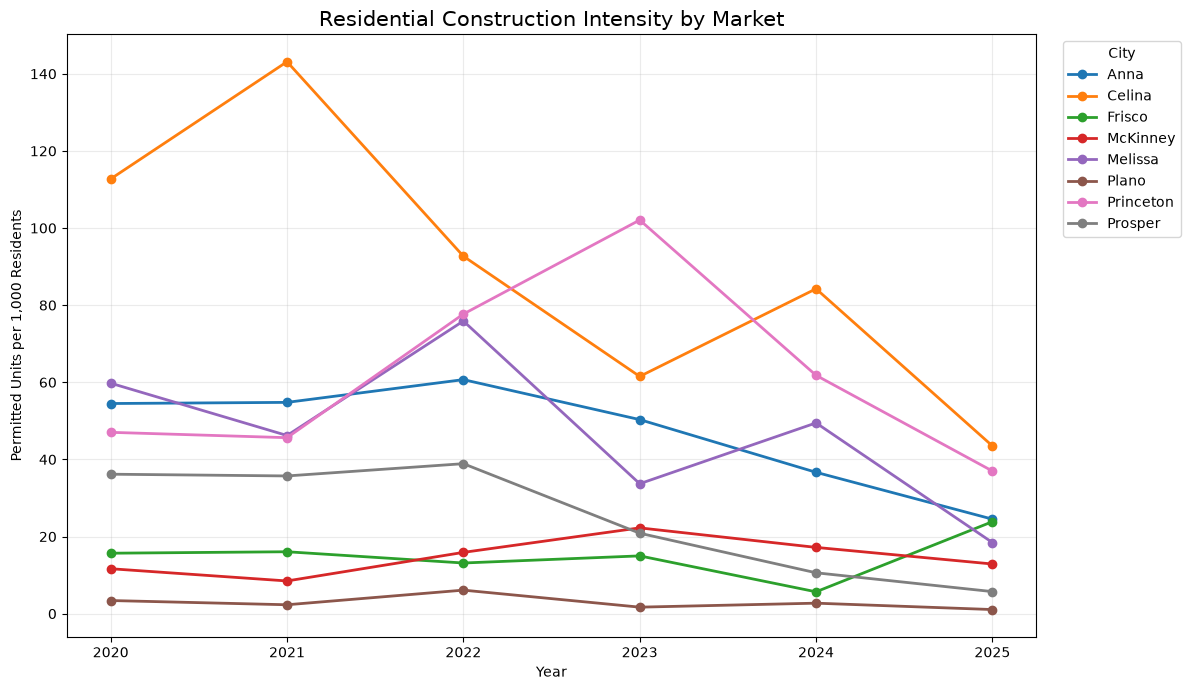

In [138]:
fig, ax = plt.subplots(figsize=(12, 7))

for city in sorted(
    bps_population["City"].unique()
):
    city_data = bps_population[
        bps_population["City"] == city
    ]

    ax.plot(
        city_data["Year"],
        city_data["Permits_Per_1000_Residents"],
        marker="o",
        linewidth=2,
        label=city
    )

ax.set_title(
    "Residential Construction Intensity by Market",
    fontsize=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Permitted Units per 1,000 Residents")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

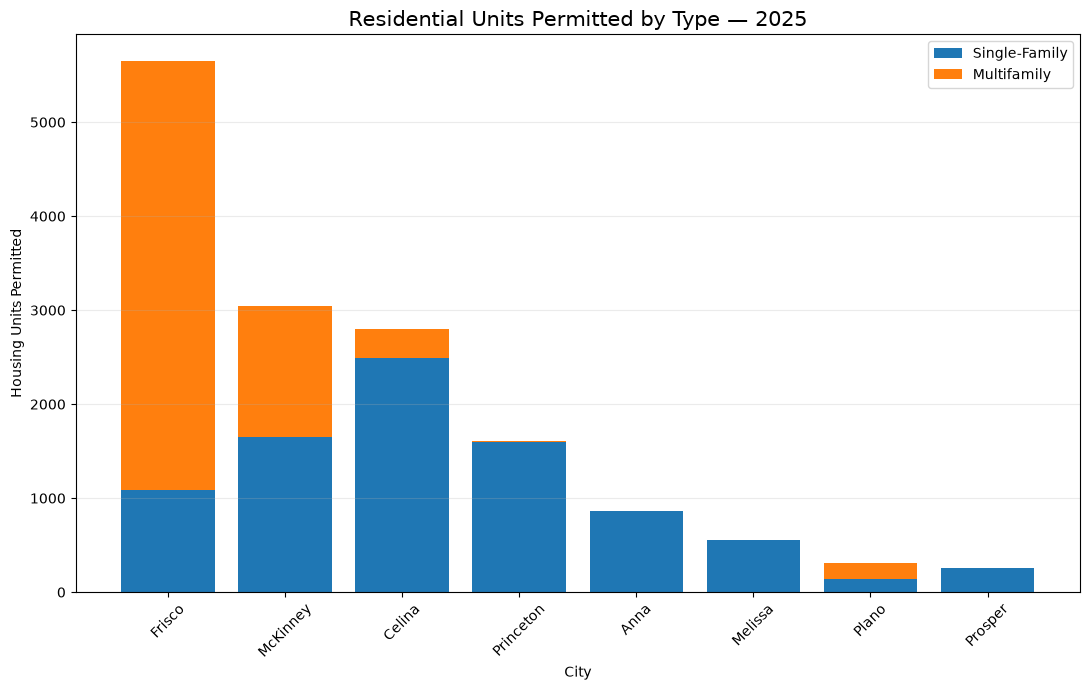

In [143]:
# -------------------------------------------------------------------
# 2025 PERMIT MIX
# -------------------------------------------------------------------

permit_mix_2025 = (
    bps_population[
        bps_population["Year"] == 2025
    ]
    .sort_values(
        "Total_Units_Permitted",
        ascending=False
    )
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.bar(
    permit_mix_2025["City"],
    permit_mix_2025["Single_Family_Units"],
    label="Single-Family"
)

ax.bar(
    permit_mix_2025["City"],
    permit_mix_2025["Multifamily_Units"],
    bottom=permit_mix_2025["Single_Family_Units"],
    label="Multifamily"
)

ax.set_title(
    "Residential Units Permitted by Type — 2025",
    fontsize=15
)

ax.set_xlabel("City")
ax.set_ylabel("Housing Units Permitted")

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [139]:
BPS_PROCESSED_FILE = (
    PROCESSED_DATA_DIR
    / "tx_building_permits_annual.csv"
)

bps_population.to_csv(
    BPS_PROCESSED_FILE,
    index=False
)

print("Saved:", BPS_PROCESSED_FILE)
print("Shape:", bps_population.shape)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/tx_building_permits_annual.csv
Shape: (48, 10)


In [140]:
CONSTRUCTION_SUMMARY_FILE = (
    PROCESSED_DATA_DIR
    / "tx_construction_summary.csv"
)

construction_summary.to_csv(
    CONSTRUCTION_SUMMARY_FILE,
    index=False
)

print("Saved:", CONSTRUCTION_SUMMARY_FILE)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/tx_construction_summary.csv


### Residential Construction Findings

Building-permit activity reveals substantial differences in both the intensity and composition of residential construction across the eight markets.

**Celina has experienced the highest sustained construction intensity in the comparison.** Approximately 18,500 residential units were permitted from 2020 through 2025, averaging nearly 90 permitted units per 1,000 residents annually. This construction boom occurred alongside exceptionally rapid population growth, indicating simultaneous expansion in both housing demand and supply.

**Princeton also experienced unusually high construction intensity**, averaging approximately 62 permitted units per 1,000 residents. Construction has moderated from its recent peak, while population growth remains strong and current transaction activity has accelerated.

**Anna and Melissa exhibit substantial single-family-oriented development.** Both markets have experienced rapid population growth alongside comparatively high residential construction rates.

**Frisco and McKinney generate high absolute permit volumes because of their much larger market sizes.** Their normalized construction rates are considerably lower than those of the smaller high-growth cities, and recent construction includes a substantially larger multifamily component.

**Prosper's construction intensity has declined considerably from earlier levels**, while Plano exhibits very limited residential construction relative to its population, consistent with a more mature and built-out market.

Overall, the building-permit data suggest that recent home-price weakness in several high-growth North Dallas markets is occurring alongside substantial housing-supply expansion rather than demographic contraction. Construction intensity has nevertheless moderated from earlier peaks in several of the fastest-growing markets.

## 10. Integrated Market Fundamentals

This section combines the home-value, demographic, residential-construction, and current housing-market indicators developed throughout the exploratory analysis.

The integrated dataset provides one standardized observation per market and serves as the foundation for the market-scoring methodology developed in the subsequent modeling notebook.

The variables are organized into four analytical dimensions:

1. **Historical Price Performance** - longer-term home-value appreciation and recent price trends.
2. **Demographic Fundamentals** - population growth and recent demographic momentum.
3. **Residential Construction** - the scale and intensity of new housing development.
4. **Current Market Conditions** - transaction activity, inventory, supply, market speed, and pricing competitiveness.

No composite scores or weights are assigned in this notebook. Those methodological decisions are developed separately after examining the relationships among the underlying indicators.

In [144]:
# -------------------------------------------------------------------
# INSPECT SUMMARY TABLES BEFORE INTEGRATION
# -------------------------------------------------------------------

print("PRICE SUMMARY COLUMNS")
print(final_price_summary.columns.tolist())

print("\nPOPULATION SUMMARY COLUMNS")
print(population_summary.columns.tolist())

print("\nCONSTRUCTION SUMMARY COLUMNS")
print(construction_summary.columns.tolist())

print("\nMARKET CONDITIONS COLUMNS")
print(market_conditions.columns.tolist())

PRICE SUMMARY COLUMNS
['City', 'Start_ZHVI', 'Latest_ZHVI', 'Total_Appreciation_Pct', 'Five_Year_CAGR_Pct', 'Three_Year_CAGR_Pct', 'Latest_YoY_Pct', 'Momentum_vs_3yr', 'Change_From_Peak_Pct', 'Months_Since_Peak', 'Current_Price_Trend']

POPULATION SUMMARY COLUMNS
['City', 'Start_Year', 'Latest_Year', 'Start_Population', 'Latest_Population', 'Population_Change', 'Total_Population_Growth_Pct', 'Years', 'Population_CAGR_Pct', 'Latest_Population_YoY_Pct', 'Population_Growth_Acceleration']

CONSTRUCTION SUMMARY COLUMNS
['City', 'Total_Permits_2020_2025', 'Avg_Annual_Permits', 'Avg_Permits_Per_1000', 'Latest_Permits', 'Latest_Permits_Per_1000', 'Latest_SF_Share_Pct']

MARKET CONDITIONS COLUMNS
['City', 'ZHVI_YoY_Pct', 'ZHVI_From_Peak_Pct', 'Homes_Sold_YoY_Pct', 'Inventory_YoY_Pct', 'Months_of_Supply', 'Median_DOM', 'DOM_YoY_Change', 'Sale_to_List_Pct', 'New_Listings_YoY_Pct', 'Pending_Sales_YoY_Pct']


In [145]:
# -------------------------------------------------------------------
# VERIFY ONE OBSERVATION PER CITY
# -------------------------------------------------------------------

summary_tables = {
    "Price": final_price_summary,
    "Population": population_summary,
    "Construction": construction_summary,
    "Market Conditions": market_conditions
}

for name, table in summary_tables.items():

    print(f"\n{name}")
    print("-" * 40)

    print("Rows:", len(table))
    print("Unique cities:", table["City"].nunique())
    print(
        "Duplicate cities:",
        table["City"].duplicated().sum()
    )

    print(
        "Cities:",
        sorted(table["City"].unique())
    )


Price
----------------------------------------
Rows: 8
Unique cities: 8
Duplicate cities: 0
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper']

Population
----------------------------------------
Rows: 8
Unique cities: 8
Duplicate cities: 0
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper']

Construction
----------------------------------------
Rows: 8
Unique cities: 8
Duplicate cities: 0
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper']

Market Conditions
----------------------------------------
Rows: 8
Unique cities: 8
Duplicate cities: 0
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper']


In [146]:
# -------------------------------------------------------------------
# CHECK CITY COVERAGE ACROSS DATASETS
# -------------------------------------------------------------------

expected_cities = set(TARGET_CITIES)

for name, table in summary_tables.items():

    actual_cities = set(table["City"])

    missing = expected_cities - actual_cities
    extra = actual_cities - expected_cities

    print(f"\n{name}")

    print(
        "Missing:",
        sorted(missing) if missing else "None"
    )

    print(
        "Extra:",
        sorted(extra) if extra else "None"
    )


Price
Missing: None
Extra: None

Population
Missing: None
Extra: None

Construction
Missing: None
Extra: None

Market Conditions
Missing: None
Extra: None


In [147]:
# -------------------------------------------------------------------
# SELECT PRICE VARIABLES
# -------------------------------------------------------------------

price_master = final_price_summary[
    [
        "City",
        "Latest_ZHVI",
        "Total_Appreciation_Pct",
        "Five_Year_CAGR_Pct",
        "Three_Year_CAGR_Pct",
        "Latest_YoY_Pct",
        "Momentum_vs_3yr",
        "Change_From_Peak_Pct",
        "Months_Since_Peak"
    ]
].copy()

price_master = price_master.rename(
    columns={
        "Latest_YoY_Pct": "ZHVI_YoY_Pct",
        "Change_From_Peak_Pct": "ZHVI_From_Peak_Pct"
    }
)

price_master.round(2)

,City,Latest_ZHVI,Total_Appreciation_Pct,Five_Year_CAGR_Pct,Three_Year_CAGR_Pct,ZHVI_YoY_Pct,Momentum_vs_3yr,ZHVI_From_Peak_Pct,Months_Since_Peak
4,Plano,"499,723.21",42.52,3.23,-2.21,-4.43,-2.22,-9.18,26
1,Frisco,"649,172.68",50.67,3.81,-1.87,-4.56,-2.69,-9.64,48
0,Prosper,"770,217.03",59.47,3.96,-1.99,-5.71,-3.72,-12.17,48
5,Melissa,"430,393.87",40.56,2.10,-3.63,-6.02,-2.39,-17.95,48
3,McKinney,"480,264.85",42.73,2.67,-3.23,-6.11,-2.89,-13.80,48
6,Anna,"345,077.93",31.91,1.01,-4.62,-7.08,-2.46,-20.84,48
2,Celina,"522,656.82",45.35,2.85,-3.60,-9.34,-5.73,-17.01,48
7,Princeton,"288,891.23",24.09,-0.35,-6.50,-10.23,-3.73,-25.12,47


In [148]:
# -------------------------------------------------------------------
# SELECT DEMOGRAPHIC VARIABLES
# -------------------------------------------------------------------

population_master = population_summary[
    [
        "City",
        "Latest_Population",
        "Population_Change",
        "Total_Population_Growth_Pct",
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",
        "Population_Growth_Acceleration"
    ]
].copy()

population_master.round(2)

,City,Latest_Population,Population_Change,Total_Population_Growth_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration
0,Anna,"35,245.00","17,629.00",100.07,14.88,10.15,-4.37
1,Celina,"64,427.00","46,394.00",257.27,29.00,24.58,6.55
2,Frisco,"236,955.00","34,206.00",16.87,3.17,0.76,-2.89
3,McKinney,"236,001.00","38,494.00",19.49,3.63,3.74,-1.67
4,Melissa,"29,969.00","15,630.00",109.00,15.89,14.48,4.49
5,Plano,"293,028.00","6,614.00",2.31,0.46,-0.13,-0.13
6,Princeton,"43,524.00","26,023.00",148.69,19.99,18.09,-12.45
7,Prosper,"45,605.00","14,776.00",47.93,8.15,2.46,-3.45


In [149]:
# -------------------------------------------------------------------
# SELECT CONSTRUCTION VARIABLES
# -------------------------------------------------------------------

construction_master = construction_summary[
    [
        "City",
        "Total_Permits_2020_2025",
        "Avg_Annual_Permits",
        "Avg_Permits_Per_1000",
        "Latest_Permits",
        "Latest_Permits_Per_1000",
        "Latest_SF_Share_Pct"
    ]
].copy()

construction_master.round(2)

,City,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct
0,Anna,6970,"1,161.67",46.91,864,24.51,100.00
1,Celina,18534,"3,089.00",89.64,2803,43.51,88.80
2,Frisco,19850,"3,308.33",14.90,5652,23.85,19.29
3,McKinney,19096,"3,182.67",14.72,3040,12.88,54.24
4,Melissa,5765,960.83,47.25,553,18.45,100.00
5,Plano,5029,838.17,2.88,313,1.07,44.09
6,Princeton,10293,"1,715.50",61.87,1610,36.99,99.25
7,Prosper,5418,903.00,24.66,261,5.72,100.00


In [150]:
construction_master = construction_master.merge(
    construction_peak_summary[
        [
            "City",
            "Peak_Construction_Year",
            "Peak_Permits_Per_1000",
            "Change_From_Construction_Peak_Pct"
        ]
    ],
    on="City",
    how="left",
    validate="one_to_one"
)

construction_master.round(2)

,City,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct,Peak_Construction_Year,Peak_Permits_Per_1000,Change_From_Construction_Peak_Pct
0,Anna,6970,"1,161.67",46.91,864,24.51,100.00,2022,60.69,-59.61
1,Celina,18534,"3,089.00",89.64,2803,43.51,88.80,2021,143.13,-69.60
2,Frisco,19850,"3,308.33",14.90,5652,23.85,19.29,2025,23.85,0.00
3,McKinney,19096,"3,182.67",14.72,3040,12.88,54.24,2023,22.25,-42.10
4,Melissa,5765,960.83,47.25,553,18.45,100.00,2022,75.89,-75.69
5,Plano,5029,838.17,2.88,313,1.07,44.09,2022,6.10,-82.50
6,Princeton,10293,"1,715.50",61.87,1610,36.99,99.25,2023,102.08,-63.76
7,Prosper,5418,903.00,24.66,261,5.72,100.00,2022,38.90,-85.29


In [151]:
# -------------------------------------------------------------------
# SELECT CURRENT MARKET VARIABLES
# -------------------------------------------------------------------

current_market_master = market_conditions[
    [
        "City",
        "Homes_Sold_YoY_Pct",
        "Pending_Sales_YoY_Pct",
        "Inventory_YoY_Pct",
        "New_Listings_YoY_Pct",
        "Months_of_Supply",
        "Median_DOM",
        "DOM_YoY_Change",
        "Sale_to_List_Pct"
    ]
].copy()

current_market_master.round(2)

,City,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Plano,4.27,-6.38,-19.70,-17.03,3.40,36.00,1.00,97.90
1,Frisco,6.57,-1.81,4.70,-0.18,4.90,50.00,2.00,97.29
2,Prosper,-6.18,-11.60,0.24,-18.94,5.30,66.00,0.00,96.36
3,Melissa,-4.55,-16.67,-13.59,-12.64,5.20,60.00,3.00,97.90
4,McKinney,-5.24,-12.53,-10.07,-14.55,4.10,45.00,0.00,97.76
5,Anna,4.48,5.88,10.74,-1.88,5.90,76.00,14.00,97.73
6,Celina,34.45,44.17,15.93,23.48,6.80,83.00,10.00,96.50
7,Princeton,40.06,39.94,-1.06,-15.67,3.30,61.00,-5.00,97.33


In [152]:
# -------------------------------------------------------------------
# BUILD INTEGRATED MARKET DATASET
# -------------------------------------------------------------------

market_master = (
    price_master
    .merge(
        population_master,
        on="City",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        construction_master,
        on="City",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        current_market_master,
        on="City",
        how="inner",
        validate="one_to_one"
    )
)

market_master = (
    market_master
    .sort_values("City")
    .reset_index(drop=True)
)

print("Shape:", market_master.shape)

market_master.round(2)

Shape: (8, 32)


,City,Latest_ZHVI,Total_Appreciation_Pct,Five_Year_CAGR_Pct,Three_Year_CAGR_Pct,ZHVI_YoY_Pct,Momentum_vs_3yr,ZHVI_From_Peak_Pct,Months_Since_Peak,Latest_Population,Population_Change,Total_Population_Growth_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct,Peak_Construction_Year,Peak_Permits_Per_1000,Change_From_Construction_Peak_Pct,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Anna,"345,077.93",31.91,1.01,-4.62,-7.08,-2.46,-20.84,48,"35,245.00","17,629.00",100.07,14.88,10.15,-4.37,6970,"1,161.67",46.91,864,24.51,100.00,2022,60.69,-59.61,4.48,5.88,10.74,-1.88,5.90,76.00,14.00,97.73
1,Celina,"522,656.82",45.35,2.85,-3.60,-9.34,-5.73,-17.01,48,"64,427.00","46,394.00",257.27,29.00,24.58,6.55,18534,"3,089.00",89.64,2803,43.51,88.80,2021,143.13,-69.60,34.45,44.17,15.93,23.48,6.80,83.00,10.00,96.50
2,Frisco,"649,172.68",50.67,3.81,-1.87,-4.56,-2.69,-9.64,48,"236,955.00","34,206.00",16.87,3.17,0.76,-2.89,19850,"3,308.33",14.90,5652,23.85,19.29,2025,23.85,0.00,6.57,-1.81,4.70,-0.18,4.90,50.00,2.00,97.29
3,McKinney,"480,264.85",42.73,2.67,-3.23,-6.11,-2.89,-13.80,48,"236,001.00","38,494.00",19.49,3.63,3.74,-1.67,19096,"3,182.67",14.72,3040,12.88,54.24,2023,22.25,-42.10,-5.24,-12.53,-10.07,-14.55,4.10,45.00,0.00,97.76
4,Melissa,"430,393.87",40.56,2.10,-3.63,-6.02,-2.39,-17.95,48,"29,969.00","15,630.00",109.00,15.89,14.48,4.49,5765,960.83,47.25,553,18.45,100.00,2022,75.89,-75.69,-4.55,-16.67,-13.59,-12.64,5.20,60.00,3.00,97.90
5,Plano,"499,723.21",42.52,3.23,-2.21,-4.43,-2.22,-9.18,26,"293,028.00","6,614.00",2.31,0.46,-0.13,-0.13,5029,838.17,2.88,313,1.07,44.09,2022,6.10,-82.50,4.27,-6.38,-19.70,-17.03,3.40,36.00,1.00,97.90
6,Princeton,"288,891.23",24.09,-0.35,-6.50,-10.23,-3.73,-25.12,47,"43,524.00","26,023.00",148.69,19.99,18.09,-12.45,10293,"1,715.50",61.87,1610,36.99,99.25,2023,102.08,-63.76,40.06,39.94,-1.06,-15.67,3.30,61.00,-5.00,97.33
7,Prosper,"770,217.03",59.47,3.96,-1.99,-5.71,-3.72,-12.17,48,"45,605.00","14,776.00",47.93,8.15,2.46,-3.45,5418,903.00,24.66,261,5.72,100.00,2022,38.90,-85.29,-6.18,-11.60,0.24,-18.94,5.30,66.00,0.00,96.36


In [153]:
# -------------------------------------------------------------------
# VALIDATE INTEGRATED MARKET DATASET
# -------------------------------------------------------------------

print("INTEGRATED MARKET DATA VALIDATION")
print("-" * 45)

print("Rows:", len(market_master))
print("Columns:", len(market_master.columns))
print("Unique cities:", market_master["City"].nunique())

print(
    "Duplicate cities:",
    market_master["City"].duplicated().sum()
)

print(
    "Total missing values:",
    market_master.isna().sum().sum()
)

print("\nCities:")
for city in market_master["City"]:
    print("-", city)

INTEGRATED MARKET DATA VALIDATION
---------------------------------------------
Rows: 8
Columns: 32
Unique cities: 8
Duplicate cities: 0
Total missing values: 0

Cities:
- Anna
- Celina
- Frisco
- McKinney
- Melissa
- Plano
- Princeton
- Prosper


In [154]:
# -------------------------------------------------------------------
# CHECK MISSING VALUES BY VARIABLE
# -------------------------------------------------------------------

missing_summary = (
    market_master
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[
    missing_summary > 0
]

if len(missing_summary) == 0:
    print("No missing values in the integrated dataset.")
else:
    print("Variables with missing values:")
    print(missing_summary)

No missing values in the integrated dataset.


In [155]:
# -------------------------------------------------------------------
# COMPACT MARKET COMPARISON
# -------------------------------------------------------------------

market_snapshot = market_master[
    [
        "City",

        # Price
        "Five_Year_CAGR_Pct",
        "ZHVI_YoY_Pct",
        "ZHVI_From_Peak_Pct",

        # Demographics
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",

        # Construction
        "Avg_Permits_Per_1000",
        "Latest_Permits_Per_1000",

        # Current market
        "Homes_Sold_YoY_Pct",
        "Pending_Sales_YoY_Pct",
        "Inventory_YoY_Pct",
        "Months_of_Supply",
        "DOM_YoY_Change",
        "Sale_to_List_Pct"
    ]
].copy()

market_snapshot.round(2)

,City,Five_Year_CAGR_Pct,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,DOM_YoY_Change,Sale_to_List_Pct
0,Anna,1.01,-7.08,-20.84,14.88,10.15,46.91,24.51,4.48,5.88,10.74,5.90,14.00,97.73
1,Celina,2.85,-9.34,-17.01,29.00,24.58,89.64,43.51,34.45,44.17,15.93,6.80,10.00,96.50
2,Frisco,3.81,-4.56,-9.64,3.17,0.76,14.90,23.85,6.57,-1.81,4.70,4.90,2.00,97.29
3,McKinney,2.67,-6.11,-13.80,3.63,3.74,14.72,12.88,-5.24,-12.53,-10.07,4.10,0.00,97.76
4,Melissa,2.10,-6.02,-17.95,15.89,14.48,47.25,18.45,-4.55,-16.67,-13.59,5.20,3.00,97.90
5,Plano,3.23,-4.43,-9.18,0.46,-0.13,2.88,1.07,4.27,-6.38,-19.70,3.40,1.00,97.90
6,Princeton,-0.35,-10.23,-25.12,19.99,18.09,61.87,36.99,40.06,39.94,-1.06,3.30,-5.00,97.33
7,Prosper,3.96,-5.71,-12.17,8.15,2.46,24.66,5.72,-6.18,-11.60,0.24,5.30,0.00,96.36


In [156]:
# -------------------------------------------------------------------
# EXPORT INTEGRATED MARKET DATASET
# -------------------------------------------------------------------

MASTER_FILE = (
    PROCESSED_DATA_DIR
    / "tx_market_master.csv"
)

market_master.to_csv(
    MASTER_FILE,
    index=False
)

print("Saved:", MASTER_FILE)
print("Shape:", market_master.shape)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/tx_market_master.csv
Shape: (8, 32)


In [157]:
SNAPSHOT_FILE = (
    PROCESSED_DATA_DIR
    / "tx_market_snapshot.csv"
)

market_snapshot.to_csv(
    SNAPSHOT_FILE,
    index=False
)

print("Saved:", SNAPSHOT_FILE)
print("Shape:", market_snapshot.shape)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/tx_market_snapshot.csv
Shape: (8, 14)


## 11. Indicator Correlation and Redundancy Analysis

Before constructing composite market scores, the candidate indicators are evaluated for potential redundancy.

Several variables measure related economic concepts. Including highly correlated indicators in the same composite score could unintentionally give greater weight to a single underlying factor.

Because the analysis contains only eight markets, correlations are interpreted descriptively rather than as statistically robust estimates of relationships across housing markets. The primary purpose of this section is therefore variable selection and redundancy detection rather than statistical inference.

In [158]:
# -------------------------------------------------------------------
# DEFINE CANDIDATE MODEL VARIABLES
# -------------------------------------------------------------------

candidate_variables = [
    # Historical price performance
    "Five_Year_CAGR_Pct",
    "Three_Year_CAGR_Pct",
    "ZHVI_YoY_Pct",
    "ZHVI_From_Peak_Pct",

    # Demographics
    "Population_CAGR_Pct",
    "Latest_Population_YoY_Pct",
    "Population_Growth_Acceleration",

    # Construction
    "Avg_Permits_Per_1000",
    "Latest_Permits_Per_1000",
    "Change_From_Construction_Peak_Pct",

    # Transaction activity
    "Homes_Sold_YoY_Pct",
    "Pending_Sales_YoY_Pct",

    # Supply
    "Inventory_YoY_Pct",
    "New_Listings_YoY_Pct",
    "Months_of_Supply",

    # Market speed / competitiveness
    "Median_DOM",
    "DOM_YoY_Change",
    "Sale_to_List_Pct"
]

candidate_data = market_master[
    ["City"] + candidate_variables
].copy()

print("Candidate variables:", len(candidate_variables))
print("Markets:", len(candidate_data))

candidate_data.round(2)

Candidate variables: 18
Markets: 8


,City,Five_Year_CAGR_Pct,Three_Year_CAGR_Pct,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Anna,1.01,-4.62,-7.08,-20.84,14.88,10.15,-4.37,46.91,24.51,-59.61,4.48,5.88,10.74,-1.88,5.90,76.00,14.00,97.73
1,Celina,2.85,-3.60,-9.34,-17.01,29.00,24.58,6.55,89.64,43.51,-69.60,34.45,44.17,15.93,23.48,6.80,83.00,10.00,96.50
2,Frisco,3.81,-1.87,-4.56,-9.64,3.17,0.76,-2.89,14.90,23.85,0.00,6.57,-1.81,4.70,-0.18,4.90,50.00,2.00,97.29
3,McKinney,2.67,-3.23,-6.11,-13.80,3.63,3.74,-1.67,14.72,12.88,-42.10,-5.24,-12.53,-10.07,-14.55,4.10,45.00,0.00,97.76
4,Melissa,2.10,-3.63,-6.02,-17.95,15.89,14.48,4.49,47.25,18.45,-75.69,-4.55,-16.67,-13.59,-12.64,5.20,60.00,3.00,97.90
5,Plano,3.23,-2.21,-4.43,-9.18,0.46,-0.13,-0.13,2.88,1.07,-82.50,4.27,-6.38,-19.70,-17.03,3.40,36.00,1.00,97.90
6,Princeton,-0.35,-6.50,-10.23,-25.12,19.99,18.09,-12.45,61.87,36.99,-63.76,40.06,39.94,-1.06,-15.67,3.30,61.00,-5.00,97.33
7,Prosper,3.96,-1.99,-5.71,-12.17,8.15,2.46,-3.45,24.66,5.72,-85.29,-6.18,-11.60,0.24,-18.94,5.30,66.00,0.00,96.36


In [159]:
# -------------------------------------------------------------------
# CANDIDATE VARIABLE CORRELATIONS
# -------------------------------------------------------------------

correlation_matrix = (
    candidate_data
    .drop(columns="City")
    .corr()
)

correlation_matrix.round(2)

,Five_Year_CAGR_Pct,Three_Year_CAGR_Pct,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
Five_Year_CAGR_Pct,1.00,0.98,0.72,0.93,-0.50,-0.56,0.54,-0.49,-0.51,0.15,-0.53,-0.50,-0.10,0.09,0.24,-0.27,0.02,-0.33
Three_Year_CAGR_Pct,0.98,1.00,0.84,0.97,-0.63,-0.68,0.49,-0.63,-0.63,0.16,-0.64,-0.63,-0.21,-0.03,0.14,-0.38,0.02,-0.17
ZHVI_YoY_Pct,0.72,0.84,1.00,0.85,-0.87,-0.88,0.24,-0.87,-0.83,0.22,-0.84,-0.88,-0.51,-0.38,-0.17,-0.64,-0.07,0.32
ZHVI_From_Peak_Pct,0.93,0.97,0.85,1.00,-0.73,-0.75,0.39,-0.72,-0.66,0.22,-0.57,-0.58,-0.32,-0.09,-0.07,-0.57,-0.11,-0.06
Population_CAGR_Pct,-0.50,-0.63,-0.87,-0.73,1.00,0.98,0.17,1.00,0.84,-0.30,0.70,0.77,0.61,0.62,0.55,0.85,0.37,-0.40
Latest_Population_YoY_Pct,-0.56,-0.68,-0.88,-0.75,0.98,1.00,0.19,0.98,0.85,-0.28,0.73,0.77,0.48,0.58,0.43,0.73,0.29,-0.26
Population_Growth_Acceleration,0.54,0.49,0.24,0.39,0.17,0.19,1.00,0.17,-0.03,-0.18,-0.24,-0.18,-0.02,0.51,0.59,0.16,0.48,-0.07
Avg_Permits_Per_1000,-0.49,-0.63,-0.87,-0.72,1.00,0.98,0.17,1.00,0.87,-0.25,0.72,0.80,0.64,0.66,0.56,0.85,0.38,-0.40
Latest_Permits_Per_1000,-0.51,-0.63,-0.83,-0.66,0.84,0.85,-0.03,0.87,1.00,0.22,0.83,0.86,0.72,0.72,0.41,0.67,0.28,-0.30
Change_From_Construction_Peak_Pct,0.15,0.16,0.22,0.22,-0.30,-0.28,-0.18,-0.25,0.22,1.00,-0.02,-0.05,0.26,0.23,-0.03,-0.23,-0.02,0.14


In [160]:
# -------------------------------------------------------------------
# IDENTIFY HIGH-CORRELATION VARIABLE PAIRS
# -------------------------------------------------------------------

correlation_pairs = []

columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        var_1 = columns[i]
        var_2 = columns[j]

        corr = correlation_matrix.loc[
            var_1,
            var_2
        ]

        correlation_pairs.append(
            {
                "Variable_1": var_1,
                "Variable_2": var_2,
                "Correlation": corr,
                "Absolute_Correlation": abs(corr)
            }
        )

correlation_pairs = pd.DataFrame(
    correlation_pairs
).sort_values(
    "Absolute_Correlation",
    ascending=False
)

correlation_pairs.head(20).round(3)

,Variable_1,Variable_2,Correlation,Absolute_Correlation
64,Population_CAGR_Pct,Avg_Permits_Per_1000,1.00,1.00
0,Five_Year_CAGR_Pct,Three_Year_CAGR_Pct,0.98,0.98
62,Population_CAGR_Pct,Latest_Population_YoY_Pct,0.98,0.98
76,Latest_Population_YoY_Pct,Avg_Permits_Per_1000,0.98,0.98
125,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,0.98,0.98
18,Three_Year_CAGR_Pct,ZHVI_From_Peak_Pct,0.97,0.97
2,Five_Year_CAGR_Pct,ZHVI_From_Peak_Pct,0.93,0.93
35,ZHVI_YoY_Pct,Latest_Population_YoY_Pct,-0.88,0.88
41,ZHVI_YoY_Pct,Pending_Sales_YoY_Pct,-0.88,0.88
37,ZHVI_YoY_Pct,Avg_Permits_Per_1000,-0.87,0.87


In [161]:
# -------------------------------------------------------------------
# FLAG POTENTIALLY REDUNDANT VARIABLES
# -------------------------------------------------------------------

high_correlation_pairs = correlation_pairs[
    correlation_pairs["Absolute_Correlation"] >= 0.80
].copy()

print(
    "Pairs with |correlation| >= 0.80:",
    len(high_correlation_pairs)
)

high_correlation_pairs[
    [
        "Variable_1",
        "Variable_2",
        "Correlation"
    ]
].round(3)

Pairs with |correlation| >= 0.80: 25


,Variable_1,Variable_2,Correlation
64,Population_CAGR_Pct,Avg_Permits_Per_1000,1.00
0,Five_Year_CAGR_Pct,Three_Year_CAGR_Pct,0.98
62,Population_CAGR_Pct,Latest_Population_YoY_Pct,0.98
76,Latest_Population_YoY_Pct,Avg_Permits_Per_1000,0.98
125,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,0.98
18,Three_Year_CAGR_Pct,ZHVI_From_Peak_Pct,0.97
2,Five_Year_CAGR_Pct,ZHVI_From_Peak_Pct,0.93
35,ZHVI_YoY_Pct,Latest_Population_YoY_Pct,-0.88
41,ZHVI_YoY_Pct,Pending_Sales_YoY_Pct,-0.88
37,ZHVI_YoY_Pct,Avg_Permits_Per_1000,-0.87


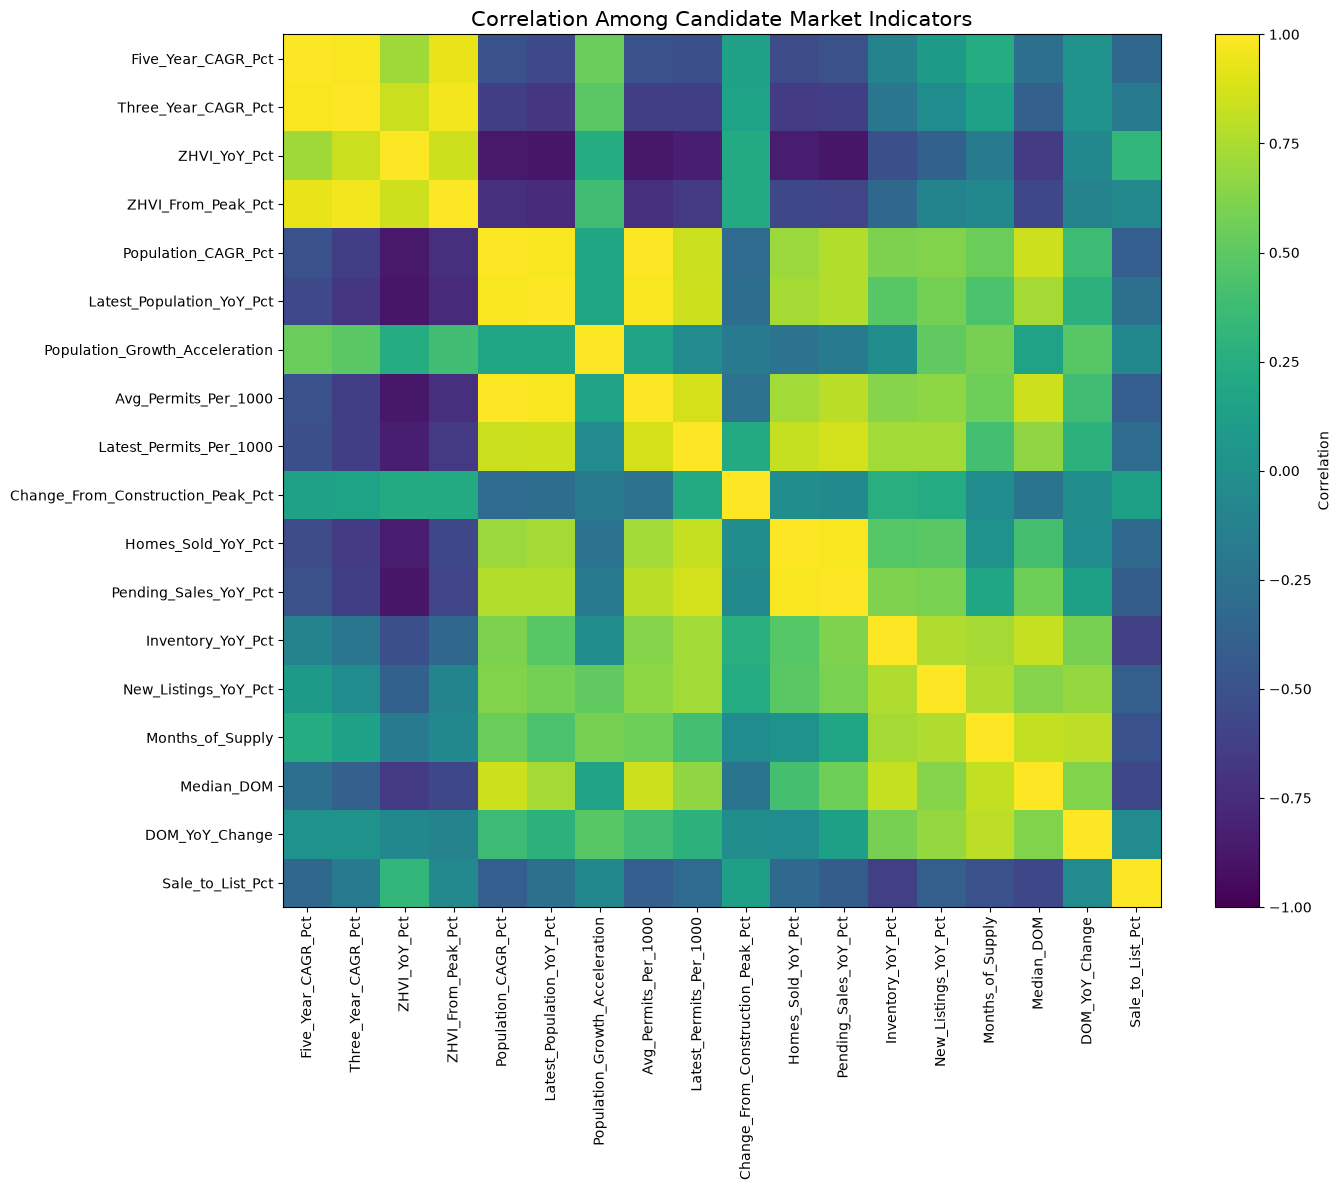

In [162]:
# -------------------------------------------------------------------
# CORRELATION HEATMAP
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_yticklabels(
    correlation_matrix.index
)

fig.colorbar(
    im,
    ax=ax,
    label="Correlation"
)

ax.set_title(
    "Correlation Among Candidate Market Indicators",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [163]:
fundamental_relationships = market_master[
    [
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",
        "Population_Growth_Acceleration",
        "Avg_Permits_Per_1000",
        "Latest_Permits_Per_1000"
    ]
].corr()

fundamental_relationships.round(2)

,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Avg_Permits_Per_1000,Latest_Permits_Per_1000
Population_CAGR_Pct,1.00,0.98,0.17,1.00,0.84
Latest_Population_YoY_Pct,0.98,1.00,0.19,0.98,0.85
Population_Growth_Acceleration,0.17,0.19,1.00,0.17,-0.03
Avg_Permits_Per_1000,1.00,0.98,0.17,1.00,0.87
Latest_Permits_Per_1000,0.84,0.85,-0.03,0.87,1.00


In [164]:
transaction_relationships = market_master[
    [
        "Homes_Sold_YoY_Pct",
        "Pending_Sales_YoY_Pct",
        "New_Listings_YoY_Pct"
    ]
].corr()

transaction_relationships.round(2)

,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,New_Listings_YoY_Pct
Homes_Sold_YoY_Pct,1.00,0.98,0.49
Pending_Sales_YoY_Pct,0.98,1.00,0.60
New_Listings_YoY_Pct,0.49,0.60,1.00


In [165]:
supply_relationships = market_master[
    [
        "Inventory_YoY_Pct",
        "Months_of_Supply",
        "Median_DOM",
        "DOM_YoY_Change",
        "Sale_to_List_Pct"
    ]
].corr()

supply_relationships.round(2)

,Inventory_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
Inventory_YoY_Pct,1.00,0.73,0.83,0.59,-0.62
Months_of_Supply,0.73,1.00,0.81,0.80,-0.50
Median_DOM,0.83,0.81,1.00,0.62,-0.57
DOM_YoY_Change,0.59,0.80,0.62,1.00,-0.03
Sale_to_List_Pct,-0.62,-0.50,-0.57,-0.03,1.00


### Variable Selection for Composite Scoring

The exploratory correlation analysis identified substantial redundancy among several candidate indicators. Because the dataset contains only eight markets, the correlations are not interpreted as statistically robust estimates of broader housing-market relationships. Instead, they are used as a diagnostic tool to reduce obvious duplication within the eventual scoring framework.

Variable selection follows four principles:

1. **Avoid double-counting:** Highly correlated indicators representing the same economic concept should not independently receive full weights.
2. **Preserve distinct economic dimensions:** Correlated variables may still be retained when they represent meaningfully different concepts, but they should not necessarily appear in the same composite score.
3. **Separate structural fundamentals from current conditions:** Long-term population and price growth describe a different dimension of market attractiveness than current inventory, transactions, and market speed.
4. **Treat construction carefully:** High permitting activity can indicate strong market expansion and developer confidence, but it can also represent greater future housing supply and competition. Construction is therefore evaluated separately rather than automatically treated as a uniformly positive signal.

In [166]:
# -------------------------------------------------------------------
# PROPOSED MODEL VARIABLE SELECTION
# -------------------------------------------------------------------

model_variable_selection = pd.DataFrame(
    [
        # Long-term fundamentals
        [
            "Population_CAGR_Pct",
            "Long-Term Fundamentals",
            "Keep",
            "Higher is better",
            "Sustained demographic growth"
        ],
        [
            "Five_Year_CAGR_Pct",
            "Long-Term Fundamentals",
            "Keep",
            "Higher is better",
            "Medium-term realized home-value appreciation"
        ],
        [
            "Population_Growth_Acceleration",
            "Long-Term Fundamentals",
            "Keep",
            "Higher is better",
            "Captures change in demographic growth rate"
        ],

        # Construction context
        [
            "Avg_Permits_Per_1000",
            "Construction Context",
            "Context",
            "Ambiguous",
            "Strongly correlated with population growth; supply and growth signal"
        ],
        [
            "Latest_Permits_Per_1000",
            "Construction Context",
            "Context",
            "Ambiguous",
            "Current construction intensity"
        ],
        [
            "Change_From_Construction_Peak_Pct",
            "Construction Context",
            "Context",
            "Ambiguous",
            "Shows whether construction is accelerating or moderating"
        ],

        # Current momentum
        [
            "ZHVI_YoY_Pct",
            "Current Market Momentum",
            "Keep",
            "Higher is better",
            "Current home-value momentum"
        ],
        [
            "Homes_Sold_YoY_Pct",
            "Current Market Momentum",
            "Keep",
            "Higher is better",
            "Current transaction momentum"
        ],
        [
            "Inventory_YoY_Pct",
            "Current Market Momentum",
            "Keep",
            "Lower is better",
            "Direction of available supply"
        ],
        [
            "Months_of_Supply",
            "Current Market Momentum",
            "Keep",
            "Lower is better",
            "Current supply-demand balance"
        ],
        [
            "Sale_to_List_Pct",
            "Current Market Momentum",
            "Keep",
            "Higher is better",
            "Seller pricing power"
        ],

        # Context / redundancy
        [
            "Three_Year_CAGR_Pct",
            "Price Context",
            "Context",
            "Higher is better",
            "Highly correlated with five-year CAGR"
        ],
        [
            "ZHVI_From_Peak_Pct",
            "Price Context",
            "Context",
            "Higher is better",
            "Useful correction indicator but correlated with price trends"
        ],
        [
            "Latest_Population_YoY_Pct",
            "Demographic Context",
            "Context",
            "Higher is better",
            "Highly correlated with population CAGR"
        ],
        [
            "Pending_Sales_YoY_Pct",
            "Transaction Context",
            "Context",
            "Higher is better",
            "Highly correlated with homes sold growth"
        ],
        [
            "New_Listings_YoY_Pct",
            "Supply Context",
            "Context",
            "Ambiguous",
            "Useful additional supply indicator"
        ],
        [
            "Median_DOM",
            "Market Speed Context",
            "Context",
            "Lower is better",
            "Correlated with inventory and months supply"
        ],
        [
            "DOM_YoY_Change",
            "Market Speed Context",
            "Context",
            "Lower is better",
            "Correlated with months supply"
        ]
    ],
    columns=[
        "Variable",
        "Dimension",
        "Model_Status",
        "Direction",
        "Rationale"
    ]
)

model_variable_selection

,Variable,Dimension,Model_Status,Direction,Rationale
0,Population_CAGR_Pct,Long-Term Fundamentals,Keep,Higher is better,Sustained demographic growth
1,Five_Year_CAGR_Pct,Long-Term Fundamentals,Keep,Higher is better,Medium-term realized home-value appreciation
2,Population_Growth_Acceleration,Long-Term Fundamentals,Keep,Higher is better,Captures change in demographic growth rate
3,Avg_Permits_Per_1000,Construction Context,Context,Ambiguous,Strongly correlated with population growth; su...
4,Latest_Permits_Per_1000,Construction Context,Context,Ambiguous,Current construction intensity
5,Change_From_Construction_Peak_Pct,Construction Context,Context,Ambiguous,Shows whether construction is accelerating or ...
6,ZHVI_YoY_Pct,Current Market Momentum,Keep,Higher is better,Current home-value momentum
7,Homes_Sold_YoY_Pct,Current Market Momentum,Keep,Higher is better,Current transaction momentum
8,Inventory_YoY_Pct,Current Market Momentum,Keep,Lower is better,Direction of available supply
9,Months_of_Supply,Current Market Momentum,Keep,Lower is better,Current supply-demand balance


In [167]:
# -------------------------------------------------------------------
# PROVISIONAL MODEL INPUTS
# -------------------------------------------------------------------

fundamentals_variables = [
    "Population_CAGR_Pct",
    "Five_Year_CAGR_Pct",
    "Population_Growth_Acceleration"
]

momentum_positive_variables = [
    "ZHVI_YoY_Pct",
    "Homes_Sold_YoY_Pct",
    "Sale_to_List_Pct"
]

momentum_negative_variables = [
    "Inventory_YoY_Pct",
    "Months_of_Supply"
]

construction_context_variables = [
    "Avg_Permits_Per_1000",
    "Latest_Permits_Per_1000",
    "Change_From_Construction_Peak_Pct",
    "Latest_SF_Share_Pct"
]

print("Fundamentals:", fundamentals_variables)
print("Momentum — higher is better:", momentum_positive_variables)
print("Momentum — lower is better:", momentum_negative_variables)
print("Construction context:", construction_context_variables)

Fundamentals: ['Population_CAGR_Pct', 'Five_Year_CAGR_Pct', 'Population_Growth_Acceleration']
Momentum — higher is better: ['ZHVI_YoY_Pct', 'Homes_Sold_YoY_Pct', 'Sale_to_List_Pct']
Momentum — lower is better: ['Inventory_YoY_Pct', 'Months_of_Supply']
Construction context: ['Avg_Permits_Per_1000', 'Latest_Permits_Per_1000', 'Change_From_Construction_Peak_Pct', 'Latest_SF_Share_Pct']


## EDA Conclusion

The exploratory analysis reveals substantial differences between long-term market fundamentals and current housing-market conditions across North Dallas.

The fastest-growing demographic markets—particularly Celina, Princeton, Melissa, and Anna—also experienced the highest residential construction intensity. This relationship indicates that rapid population expansion has been accompanied by a substantial supply response rather than occurring under fixed housing supply.

At the same time, all eight markets currently exhibit negative year-over-year ZHVI growth, demonstrating a broad regional housing-price correction. The severity and accompanying market dynamics differ considerably. Princeton combines a large price correction with strong transaction and pending-sales growth, relatively contained inventory, and improving market speed. Celina also exhibits strong transaction activity but faces considerably greater current supply pressure. Plano and Frisco demonstrate greater price resilience but substantially slower demographic expansion.

Correlation analysis also identifies significant redundancy among several candidate indicators. Population CAGR, recent population growth, and historical construction intensity are highly correlated across the eight markets, while homes-sold and pending-sales growth provide nearly identical transaction signals. Similarly, several measures of supply and market speed are correlated.

To avoid unintentionally overweighting these underlying economic dimensions, the subsequent scoring model uses a reduced set of indicators. Long-term fundamentals and current market momentum are modeled separately, while residential construction is retained as an important contextual measure because high construction can represent both market expansion and future competitive supply.

The resulting modeling framework therefore distinguishes between:

- **Long-Term Growth Fundamentals** — sustained demographic growth, historical home-value appreciation, and changes in demographic growth.
- **Current Market Momentum** — current price performance, transaction activity, inventory trends, supply-demand balance, and seller pricing power.
- **Construction Context** — the scale, intensity, and recent direction of new residential development.

This framework provides the foundation for the market scoring and comparative investment analysis developed in the next notebook.